In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from datetime import datetime

In [119]:
customers = pd.read_csv("datasets/customers.csv")
loans = pd.read_csv("datasets/loans.csv")
applications = pd.read_csv("datasets/applications.csv")
transactions = pd.read_csv("datasets/transactions.csv")
defaults = pd.read_csv("datasets/defaults.csv")
branches = pd.read_csv("datasets/branches.csv")

C:\Users\PAVITHRA\AppData\Local\Temp\ipykernel_120696\3811756780.py:3: DtypeWarning: Columns (0: Rejection_Reason) have mixed types. Specify dtype option on import or set low_memory=False.
  applications = pd.read_csv("datasets/applications.csv")


In [120]:
print("Customers:", customers.shape)
print("Loans:", loans.shape)
print("Applications:", applications.shape)
print("Transactions:", transactions.shape)
print("Defaults:", defaults.shape)
print("Branches:", branches.shape)

Customers: (70000, 14)
Loans: (90000, 12)
Applications: (82600, 10)
Transactions: (495000, 9)
Defaults: (9000, 9)
Branches: (50, 9)


In [121]:
customers.head()

,Customer_ID,Full_Name,Contact_Number,Email,Address,Age,Gender,Marital_Status,Employment_Status,Annual_Income,Credit_Score,Region,Account_Tenure,Relationship_Manager_ID
0,C000001,Shayak Kumar,1549750578,saxenaindrans@gopal-krishnan.com,"27/062\nSangha Nagar, Bongaigaon 736150",53,Male,Single,Unemployed,886810,433,North,12 Years,RM0015
1,C000002,Divij Ghosh,2121540709,ramanindranil@tella.com,"H.No. 20, Edwin Circle\nKatihar 892167",62,Female,Single,Self-Employed,396746,418,West,10 Years,RM0276
2,C000003,Rhea Bhargava,910320534937,bahlelakshi@mall.info,"67/386\nComar Nagar, Chapra 137669",62,Other,Single,Self-Employed,1118591,736,Northeast,9 Years,RM0098
3,C000004,Indrans Walia,6566372162,akadakia@yahoo.com,88\nDhillon Ganj\nJamshedpur-816278,59,Female,Single,Salaried,524075,353,Central,11 Years,RM0231
4,C000005,Saanvi Chad,9281095585,arhaan11@master.net,"011, Kunda Marg\nHyderabad-505161",56,Male,Single,Self-Employed,1219355,735,West,1 Years,RM0107


In [122]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Customer_ID              70000 non-null  str  
 1   Full_Name                70000 non-null  str  
 2   Contact_Number           70000 non-null  int64
 3   Email                    70000 non-null  str  
 4   Address                  70000 non-null  str  
 5   Age                      70000 non-null  int64
 6   Gender                   70000 non-null  str  
 7   Marital_Status           70000 non-null  str  
 8   Employment_Status        70000 non-null  str  
 9   Annual_Income            70000 non-null  int64
 10  Credit_Score             70000 non-null  int64
 11  Region                   70000 non-null  str  
 12  Account_Tenure           70000 non-null  str  
 13  Relationship_Manager_ID  70000 non-null  str  
dtypes: int64(4), str(10)
memory usage: 15.2 MB


In [123]:
loans.head()

,Loan_ID,Customer_ID,Loan_Amount,Interest_Rate,Loan_Term,Disbursal_Date,Repayment_Start_Date,Repayment_End_Date,Loan_Status,Overdue_Amount,EMI_Amount,Collateral_Details
0,L000001,C045929,4030468,8.45,24,2023-03-25,2023-04-25,2025-03-25,Active,0,18668,Property
1,L000002,C038991,3498647,11.90,48,2023-10-23,2023-11-23,2027-10-23,Closed,44003,36012,Property
2,L000003,C046662,4871438,9.74,24,2024-07-30,2024-08-30,2026-07-30,Overdue,0,26347,NaN
3,L000004,C040268,541515,13.55,24,2024-11-22,2024-12-22,2026-11-22,Active,0,16106,NaN
4,L000005,C067057,631036,10.10,36,2024-03-30,2024-04-30,2027-03-30,Overdue,0,10127,NaN


In [124]:
loans.info()
loans.describe()

<class 'pandas.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Loan_ID               90000 non-null  str    
 1   Customer_ID           90000 non-null  str    
 2   Loan_Amount           90000 non-null  int64  
 3   Interest_Rate         90000 non-null  float64
 4   Loan_Term             90000 non-null  int64  
 5   Disbursal_Date        90000 non-null  str    
 6   Repayment_Start_Date  90000 non-null  str    
 7   Repayment_End_Date    90000 non-null  str    
 8   Loan_Status           90000 non-null  str    
 9   Overdue_Amount        90000 non-null  int64  
 10  EMI_Amount            90000 non-null  int64  
 11  Collateral_Details    59806 non-null  str    
dtypes: float64(1), int64(4), str(7)
memory usage: 13.0 MB


,Loan_Amount,Interest_Rate,Loan_Term,Overdue_Amount,EMI_Amount
count,9.000000e+04,90000.000000,90000.000000,90000.000000,90000.000000
mean,2.516259e+06,11.005393,36.069867,12745.841511,50874.181444
std,1.429289e+06,2.307139,16.956931,16193.984497,28274.305704
min,5.002600e+04,7.000000,12.000000,0.000000,2001.000000
25%,1.275705e+06,9.000000,24.000000,0.000000,26229.750000
50%,2.510076e+06,11.010000,36.000000,1048.500000,50861.000000
75%,3.751702e+06,13.010000,48.000000,25433.000000,75431.250000
max,4.999958e+06,15.000000,60.000000,49999.000000,100000.000000


In [125]:
applications.head()

,Application_ID,Loan_ID,Customer_ID,Application_Date,Approval_Date,Loan_Purpose,Source_Channel,Processing_Fee,Approval_Status,Rejection_Reason
0,A000001,L000001,C000001,2022-05-11,2020-10-02,Business,Agent,6427,Approved,NaN
1,A000002,L000002,C000002,2022-03-18,2022-11-29,Education,Online,8605,Approved,NaN
2,A000003,L000003,C000003,2022-01-17,2023-07-01,Business,Online,1450,Approved,NaN
3,A000004,L000004,C000004,2019-03-09,2024-08-30,Home Renovation,Agent,8171,Approved,NaN
4,A000005,L000005,C000005,2024-07-18,2020-03-18,Education,Branch,4931,Approved,NaN


In [126]:
applications.info()
applications.describe()

<class 'pandas.DataFrame'>
RangeIndex: 82600 entries, 0 to 82599
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Application_ID    82600 non-null  str  
 1   Loan_ID           70000 non-null  str  
 2   Customer_ID       82600 non-null  str  
 3   Application_Date  82600 non-null  str  
 4   Approval_Date     70000 non-null  str  
 5   Loan_Purpose      82600 non-null  str  
 6   Source_Channel    82600 non-null  str  
 7   Processing_Fee    82600 non-null  int64
 8   Approval_Status   82600 non-null  str  
 9   Rejection_Reason  12600 non-null  str  
dtypes: int64(1), str(9)
memory usage: 11.4 MB


,Processing_Fee
count,82600.000000
mean,5252.813983
std,2738.430455
min,500.000000
25%,2895.000000
50%,5259.000000
75%,7621.000000
max,10000.000000


In [127]:
defaults.head()

,Default_ID,Loan_ID,Customer_ID,Default_Date,Default_Amount,Default_Reason,Recovery_Status,Recovery_Amount,Legal_Action
0,D000001,L007312,C007312,2022-07-20,94480,Job Loss,Full,30360,Yes
1,D000002,L028234,C028234,2023-09-23,10912,Job Loss,Partial,0,Yes
2,D000003,L008319,C008319,2024-08-04,73711,Other,NaN,9866,Yes
3,D000004,L046668,C046668,2021-10-16,48955,Other,NaN,0,Yes
4,D000005,L082934,C082934,2024-10-07,56952,Medical Emergency,NaN,0,No


In [128]:
defaults.info()
defaults.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Default_ID       9000 non-null   str  
 1   Loan_ID          9000 non-null   str  
 2   Customer_ID      9000 non-null   str  
 3   Default_Date     9000 non-null   str  
 4   Default_Amount   9000 non-null   int64
 5   Default_Reason   9000 non-null   str  
 6   Recovery_Status  6015 non-null   str  
 7   Recovery_Amount  9000 non-null   int64
 8   Legal_Action     9000 non-null   str  
dtypes: int64(2), str(7)
memory usage: 1.0 MB


,Default_Amount,Recovery_Amount
count,9000.000000,9000.000000
mean,52978.639667,12879.979222
std,27460.213066,16216.361811
min,5010.000000,0.000000
25%,29486.500000,0.000000
50%,53486.500000,1300.500000
75%,77012.000000,25483.000000
max,99997.000000,50000.000000


In [129]:
transactions.head()

,Transaction_ID,Loan_ID,Customer_ID,Transaction_Date,Payment_Type,Amount,Overdue_Fee,Remaining_Balance,Mode_of_Payment
0,T00000001,L005588,C050792,2021-04-30,EMI,46099,1313,1513669,NEFT
1,T00000002,L019942,C008919,2021-12-14,Penalty,43648,4852,901455,UPI
2,T00000003,L014848,C016745,2021-01-26,EMI,1810,0,1922629,Cash
3,T00000004,L041104,C039957,2021-02-18,Penalty,8607,708,213581,UPI
4,T00000005,L002488,C056156,2024-12-07,Penalty,34720,0,411621,UPI


In [130]:
transactions.info()
transactions.describe()

<class 'pandas.DataFrame'>
RangeIndex: 495000 entries, 0 to 494999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   Transaction_ID     495000 non-null  str  
 1   Loan_ID            495000 non-null  str  
 2   Customer_ID        495000 non-null  str  
 3   Transaction_Date   495000 non-null  str  
 4   Payment_Type       495000 non-null  str  
 5   Amount             495000 non-null  int64
 6   Overdue_Fee        495000 non-null  int64
 7   Remaining_Balance  495000 non-null  int64
 8   Mode_of_Payment    495000 non-null  str  
dtypes: int64(3), str(6)
memory usage: 53.9 MB


,Amount,Overdue_Fee,Remaining_Balance
count,495000.000000,495000.000000,4.950000e+05
mean,25496.424349,1273.332887,9.989344e+05
std,14144.028106,1619.499932,5.776088e+05
min,1000.000000,0.000000,2.000000e+00
25%,13280.000000,0.000000,4.979725e+05
50%,25487.000000,0.000000,9.976355e+05
75%,37730.000000,2539.000000,1.499331e+06
max,50000.000000,5000.000000,1.999999e+06


In [131]:
branches.head()

,Branch_ID,Branch_Name,Region,Total_Customers,Total_Active_Loans,Delinquent_Loans,Loan_Disbursement_Amount,Avg_Processing_Time,Relationship_Manager_Count
0,B001,"Dhar, Kant and Madan",West,2891,279,21,341680882,6,29
1,B002,Shan Group,East,4459,1201,149,96549019,8,35
2,B003,Sachdev-Banerjee,Central,2504,122,168,445787808,12,48
3,B004,Kapadia-Brar,East,1542,1422,96,353934299,9,50
4,B005,"Mangal, Kaur and Borde",South,945,1613,87,311637902,11,10


In [132]:
branches.info()
branches.describe()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Branch_ID                   50 non-null     str  
 1   Branch_Name                 50 non-null     str  
 2   Region                      50 non-null     str  
 3   Total_Customers             50 non-null     int64
 4   Total_Active_Loans          50 non-null     int64
 5   Delinquent_Loans            50 non-null     int64
 6   Loan_Disbursement_Amount    50 non-null     int64
 7   Avg_Processing_Time         50 non-null     int64
 8   Relationship_Manager_Count  50 non-null     int64
dtypes: int64(6), str(3)
memory usage: 4.9 KB


,Total_Customers,Total_Active_Loans,Delinquent_Loans,Loan_Disbursement_Amount,Avg_Processing_Time,Relationship_Manager_Count
count,50.000000,50.000000,50.00000,5.000000e+01,50.000000,50.000000
mean,2869.000000,1017.580000,100.56000,2.549472e+08,9.080000,26.060000
std,1215.608506,565.298913,50.19926,1.486461e+08,4.049893,13.237871
min,525.000000,122.000000,10.00000,1.043520e+07,1.000000,7.000000
25%,1815.000000,495.250000,69.25000,1.360858e+08,6.000000,16.000000
50%,3058.500000,947.500000,103.50000,2.498443e+08,10.000000,23.000000
75%,3834.000000,1597.000000,138.75000,3.889827e+08,12.000000,34.750000
max,4896.000000,1933.000000,200.00000,4.995629e+08,15.000000,50.000000


Check for missing values:

In [133]:
customers.isnull().sum()

Customer_ID                0
Full_Name                  0
Contact_Number             0
Email                      0
Address                    0
Age                        0
Gender                     0
Marital_Status             0
Employment_Status          0
Annual_Income              0
Credit_Score               0
Region                     0
Account_Tenure             0
Relationship_Manager_ID    0
dtype: int64

In [134]:
datasets = {
    "Customers": customers,
    "Loans": loans,
    "Applications": applications,
    "Transactions": transactions,
    "Defaults": defaults,
    "Branches": branches
}

for name, df in datasets.items():
    print("\n", name)
    print(df.isnull().sum())


 Customers
Customer_ID                0
Full_Name                  0
Contact_Number             0
Email                      0
Address                    0
Age                        0
Gender                     0
Marital_Status             0
Employment_Status          0
Annual_Income              0
Credit_Score               0
Region                     0
Account_Tenure             0
Relationship_Manager_ID    0
dtype: int64

 Loans
Loan_ID                     0
Customer_ID                 0
Loan_Amount                 0
Interest_Rate               0
Loan_Term                   0
Disbursal_Date              0
Repayment_Start_Date        0
Repayment_End_Date          0
Loan_Status                 0
Overdue_Amount              0
EMI_Amount                  0
Collateral_Details      30194
dtype: int64

 Applications
Application_ID          0
Loan_ID             12600
Customer_ID             0
Application_Date        0
Approval_Date       12600
Loan_Purpose            0
Source_Channel   

In [135]:
loans["Collateral_Details"].isnull().sum()

np.int64(30194)

In [136]:
missing_count = loans["Collateral_Details"].isnull().sum()
total_count = len(loans)

missing_percentage = (missing_count / total_count) * 100

print("Missing values:", missing_count)
print("Missing percentage:", missing_percentage)

Missing values: 30194
Missing percentage: 33.54888888888889


In [137]:
print(f"Missing percentage: {missing_percentage:.2f}%")

Missing percentage: 33.55%


In [138]:
loans["Collateral_Details"].value_counts(dropna=False)

Collateral_Details
NaN         30194
Property    29921
Vehicle     29885
Name: count, dtype: int64

In [139]:
pd.crosstab(
    loans["Collateral_Details"].isnull(),
    loans["Loan_Status"],
    normalize="index"
) * 100

Loan_Status,Active,Closed,Overdue
Collateral_Details,,,
False,33.314383,33.424740,33.260877
True,33.536464,33.430483,33.033053


In [140]:
#filling missing values in Collateral details 
loans["Collateral_Details"] = loans["Collateral_Details"].fillna(
    "Not Provided"
)

In [141]:
loans["Collateral_Details"].isnull().sum()

np.int64(0)

The Loans dataset contains 90,000 records. The Collateral_Details column contains 30,194 missing values, representing approximately 33.55% of the dataset. Since Collateral_Details is a descriptive field and the missing values do not necessarily indicate the absence of collateral, the missing values were not removed. Instead, they were replaced with the category "Not Provided" to preserve the loan records while explicitly identifying missing information.

In [142]:
applications.isnull().sum()

Application_ID          0
Loan_ID             12600
Customer_ID             0
Application_Date        0
Approval_Date       12600
Loan_Purpose            0
Source_Channel          0
Processing_Fee          0
Approval_Status         0
Rejection_Reason    70000
dtype: int64

In [143]:
applications.groupby("Approval_Status").agg(
    Total_Applications=("Application_ID", "count"),
    Missing_Loan_ID=("Loan_ID", lambda x: x.isna().sum()),
    Missing_Approval_Date=("Approval_Date", lambda x: x.isna().sum())
)

,Total_Applications,Missing_Loan_ID,Missing_Approval_Date
Approval_Status,,,
Approved,70000,0,0
Rejected,12600,12600,12600


As the Approval status for the associated missing records is "Rejected", it is a valid scenario to have missing "Loan_ID" & "Approval_Date"

In [144]:
applications["Approval_Status"].value_counts(dropna=False)

Approval_Status
Approved    70000
Rejected    12600
Name: count, dtype: int64

In [145]:
pd.crosstab(
    applications["Approval_Status"],
    applications["Rejection_Reason"].isna()
)

Rejection_Reason,False,True
Approval_Status,,
Approved,0,70000
Rejected,12600,0


in this situation, the 70,000 null values are not really missing data but valid information.

In [146]:
#Missing values in "defaults"

missing_count = defaults["Recovery_Status"].isnull().sum()
total_count = len(defaults)

missing_percentage = (missing_count / total_count) * 100

print("Missing values:", missing_count)
print(f"Missing percentage: {missing_percentage:.2f}%")

Missing values: 2985
Missing percentage: 33.17%


In [147]:
defaults["Recovery_Status"].value_counts(dropna=False)

Recovery_Status
Partial    3010
Full       3005
NaN        2985
Name: count, dtype: int64

In [148]:
defaults.groupby(
    "Recovery_Status",
    dropna=False
)["Recovery_Amount"].agg(
    ["count", "min", "max", "mean", "sum"]
)

,count,min,max,mean,sum
Recovery_Status,,,,,
Full,3005,0,50000,12762.789684,38352183
Partial,3010,0,49989,13102.429236,39438312
NaN,2985,0,49936,12773.640871,38129318


In [149]:
pd.DataFrame({
    "Missing_Status": defaults["Recovery_Status"].isna(),
    "Recovery_Amount": defaults["Recovery_Amount"]
}).groupby(
    "Missing_Status"
)["Recovery_Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Missing_Status,,,,,,,,
False,6015.0,12932.750623,16214.804055,0.0,0.0,1464.0,25690.5,50000.0
True,2985.0,12773.640871,16221.695673,0.0,0.0,1053.0,25243.0,49936.0


In [150]:
pd.crosstab(
    defaults["Legal_Action"],
    defaults["Recovery_Status"],
    dropna=False
)

Recovery_Status,Full,Partial,NaN
Legal_Action,,,
No,1512,1546,1492
Yes,1493,1464,1493


In [151]:
defaults.groupby(
    "Recovery_Status",
    dropna=False
).agg(
    Average_Default=("Default_Amount", "mean"),
    Average_Recovery=("Recovery_Amount", "mean"),
    Total_Default=("Default_Amount", "sum"),
    Total_Recovery=("Recovery_Amount", "sum")
)

,Average_Default,Average_Recovery,Total_Default,Total_Recovery
Recovery_Status,,,,
Full,52405.769052,12762.789684,157479336,38352183
Partial,53073.968771,13102.429236,159752646,39438312
NaN,53459.221106,12773.640871,159575775,38129318


In [152]:
defaults[
    defaults["Recovery_Amount"] < 0
]

,Default_ID,Loan_ID,Customer_ID,Default_Date,Default_Amount,Default_Reason,Recovery_Status,Recovery_Amount,Legal_Action


The Defaults dataset contains 2,985 missing values in the Recovery_Status column, representing approximately 33.17% of default records. All other columns are complete. Since Recovery_Status describes the recovery outcome and both Recovery_Amount and Legal_Action are available, the missing values should be investigated against these variables before any imputation is performed. The default records should be retained because Default_Amount and Recovery_Amount are available for recovery-rate analysis

In [153]:
#Data Quality
applications["Valid_Approval_Date"] = (
    applications["Approval_Date"] >= applications["Application_Date"]
)

In [154]:
applications["Valid_Approval_Date"].value_counts()

Valid_Approval_Date
False    42027
True     40573
Name: count, dtype: int64

In [155]:
applications.groupby("Approval_Status")["Valid_Approval_Date"].value_counts()

Approval_Status  Valid_Approval_Date
Approved         True                   40573
                 False                  29427
Rejected         False                  12600
Name: count, dtype: int64

In [156]:
applications[
    (applications["Valid_Approval_Date"] == False) &
    (applications["Approval_Date"].notna())
][
    [
        "Application_ID",
        "Application_Date",
        "Approval_Date",
        "Approval_Status",
        "Loan_ID"
    ]
].head(20)

,Application_ID,Application_Date,Approval_Date,Approval_Status,Loan_ID
0,A000001,2022-05-11,2020-10-02,Approved,L000001
4,A000005,2024-07-18,2020-03-18,Approved,L000005
8,A000009,2022-04-07,2021-02-20,Approved,L000009
12,A000013,2021-11-09,2020-08-01,Approved,L000013
13,A000014,2024-09-04,2020-06-02,Approved,L000014
14,A000015,2022-06-25,2021-06-03,Approved,L000015
16,A000017,2024-10-30,2024-01-31,Approved,L000017
19,A000020,2024-03-20,2022-10-10,Approved,L000020
20,A000021,2024-06-27,2022-05-14,Approved,L000021
28,A000029,2024-02-24,2020-10-27,Approved,L000029


In [157]:
invalid_dates = applications[
    applications["Valid_Approval_Date"] == False
]

print("Invalid records:", len(invalid_dates))

invalid_dates[[
    "Application_ID",
    "Application_Date",
    "Approval_Date",
    "Approval_Status",
    "Loan_ID"
]].head(20)

Invalid records: 42027


,Application_ID,Application_Date,Approval_Date,Approval_Status,Loan_ID
0,A000001,2022-05-11,2020-10-02,Approved,L000001
4,A000005,2024-07-18,2020-03-18,Approved,L000005
8,A000009,2022-04-07,2021-02-20,Approved,L000009
12,A000013,2021-11-09,2020-08-01,Approved,L000013
13,A000014,2024-09-04,2020-06-02,Approved,L000014
14,A000015,2022-06-25,2021-06-03,Approved,L000015
16,A000017,2024-10-30,2024-01-31,Approved,L000017
19,A000020,2024-03-20,2022-10-10,Approved,L000020
20,A000021,2024-06-27,2022-05-14,Approved,L000021
28,A000029,2024-02-24,2020-10-27,Approved,L000029


In [158]:
invalid_dates["Approval_Status"].value_counts()

Approval_Status
Approved    29427
Rejected    12600
Name: count, dtype: int64

In [159]:
pd.crosstab(
    invalid_dates["Approval_Status"],
    invalid_dates["Approval_Date"].isna()
)

Approval_Date,False,True
Approval_Status,,
Approved,29427,0
Rejected,0,12600


In [160]:
#check the actual date problem
date_problems = applications[
    applications["Approval_Date"].notna() &
    (applications["Approval_Date"] < applications["Application_Date"])
]

print("Records with Approval Date before Application Date:",
      len(date_problems))

Records with Approval Date before Application Date: 29427


In [161]:
date_problems[[
    "Application_ID",
    "Application_Date",
    "Approval_Date",
    "Approval_Status",
    "Loan_ID"
]].head(20)

,Application_ID,Application_Date,Approval_Date,Approval_Status,Loan_ID
0,A000001,2022-05-11,2020-10-02,Approved,L000001
4,A000005,2024-07-18,2020-03-18,Approved,L000005
8,A000009,2022-04-07,2021-02-20,Approved,L000009
12,A000013,2021-11-09,2020-08-01,Approved,L000013
13,A000014,2024-09-04,2020-06-02,Approved,L000014
14,A000015,2022-06-25,2021-06-03,Approved,L000015
16,A000017,2024-10-30,2024-01-31,Approved,L000017
19,A000020,2024-03-20,2022-10-10,Approved,L000020
20,A000021,2024-06-27,2022-05-14,Approved,L000021
28,A000029,2024-02-24,2020-10-27,Approved,L000029


In [162]:
import numpy as np

applications["Approval_Date_Status"] = np.select(
    [
        applications["Approval_Date"].isna() &
        (applications["Approval_Status"].str.lower() == "rejected"),

        applications["Approval_Date"].notna() &
        (applications["Approval_Date"] >= applications["Application_Date"]),

        applications["Approval_Date"].notna() &
        (applications["Approval_Date"] < applications["Application_Date"])
    ],
    [
        "Not Applicable - Rejected",
        "Valid",
        "Invalid - Approval Before Application"
    ],
    default="Needs Investigation"
)

In [163]:
applications["Approval_Date_Status"].value_counts()

Approval_Date_Status
Valid                                    40573
Invalid - Approval Before Application    29427
Not Applicable - Rejected                12600
Name: count, dtype: int64

In [164]:
applications["Date_Valid"] = (
    applications["Approval_Date"].isna() |
    (applications["Approval_Date"] >= applications["Application_Date"])
)

In [165]:
valid_processing = applications[
    applications["Approval_Date"].notna() &
    (applications["Approval_Date"] >= applications["Application_Date"])
].copy()

In [166]:
applications["Application_Date"] = pd.to_datetime(
    applications["Application_Date"],
    errors="coerce"
)

applications["Approval_Date"] = pd.to_datetime(
    applications["Approval_Date"],
    errors="coerce"
)

In [167]:
print(applications["Application_Date"].dtype)
print(applications["Approval_Date"].dtype)

datetime64[us]
datetime64[us]


In [168]:
print("Missing Application Dates:",
      applications["Application_Date"].isna().sum())

print("Missing Approval Dates:",
      applications["Approval_Date"].isna().sum())

Missing Application Dates: 0
Missing Approval Dates: 12600


In [169]:
valid_processing = applications[
    applications["Approval_Date"].notna() &
    (applications["Approval_Date"] >= applications["Application_Date"])
].copy()

In [170]:
print("Valid processing records:", len(valid_processing))

Valid processing records: 40573


In [171]:
valid_processing["Processing_Days"] = (
    valid_processing["Approval_Date"] -
    valid_processing["Application_Date"]
).dt.days

In [172]:
valid_processing[
    [
        "Application_ID",
        "Application_Date",
        "Approval_Date",
        "Processing_Days"
    ]
].head()

,Application_ID,Application_Date,Approval_Date,Processing_Days
1,A000002,2022-03-18,2022-11-29,256
2,A000003,2022-01-17,2023-07-01,530
3,A000004,2019-03-09,2024-08-30,2001
5,A000006,2021-06-03,2024-06-06,1099
6,A000007,2021-04-04,2024-10-04,1279


In [173]:
applications["Valid_Approval_Date"] = (
    applications["Approval_Date"].isna() |
    (applications["Approval_Date"] >= applications["Application_Date"])
)

In [174]:
applications["Valid_Approval_Date"].value_counts()

Valid_Approval_Date
True     53173
False    29427
Name: count, dtype: int64

In [175]:
date_problems = applications[
    applications["Approval_Date"].notna() &
    (applications["Approval_Date"] < applications["Application_Date"])
].copy()

In [176]:
print("Genuinely problematic date records:",
      len(date_problems))

Genuinely problematic date records: 29427


In [177]:
date_problems[
    [
        "Application_ID",
        "Application_Date",
        "Approval_Date",
        "Approval_Status",
        "Loan_ID"
    ]
].head(20)

,Application_ID,Application_Date,Approval_Date,Approval_Status,Loan_ID
0,A000001,2022-05-11,2020-10-02,Approved,L000001
4,A000005,2024-07-18,2020-03-18,Approved,L000005
8,A000009,2022-04-07,2021-02-20,Approved,L000009
12,A000013,2021-11-09,2020-08-01,Approved,L000013
13,A000014,2024-09-04,2020-06-02,Approved,L000014
14,A000015,2022-06-25,2021-06-03,Approved,L000015
16,A000017,2024-10-30,2024-01-31,Approved,L000017
19,A000020,2024-03-20,2022-10-10,Approved,L000020
20,A000021,2024-06-27,2022-05-14,Approved,L000021
28,A000029,2024-02-24,2020-10-27,Approved,L000029


In [178]:
len(date_problems)

29427

During data-quality validation, 29,427 application records were identified where the Approval Date occurred before the Application Date. These records represent approximately 35.62% of the Applications dataset. Since the correct approval dates cannot be reliably inferred from the available data, the original dates were not artificially modified. Instead, the records were retained in the dataset but excluded from processing-time calculations. Processing days were calculated only for records where the approval date was present and occurred on or after the application date.

Default flag

In [179]:
loans["Default_Flag"] = loans["Loan_ID"].isin(
    defaults["Loan_ID"]
).astype(int)

In [180]:
loans["Default_Flag"].value_counts()

Default_Flag
0    81461
1     8539
Name: count, dtype: int64

Merge customer and loan data

In [181]:
loan_customer = loans.merge(
    customers,
    on="Customer_ID",
    how="left"
)

In [182]:
loan_customer.shape

(90000, 26)

In [183]:
loan_customer.head()

,Loan_ID,Customer_ID,Loan_Amount,Interest_Rate,Loan_Term,Disbursal_Date,Repayment_Start_Date,Repayment_End_Date,Loan_Status,Overdue_Amount,...,Address,Age,Gender,Marital_Status,Employment_Status,Annual_Income,Credit_Score,Region,Account_Tenure,Relationship_Manager_ID
0,L000001,C045929,4030468,8.45,24,2023-03-25,2023-04-25,2025-03-25,Active,0,...,"H.No. 860\nIyer Marg, Jhansi 185308",60,Male,Divorced,Unemployed,634102,343,East,3 Years,RM0150
1,L000002,C038991,3498647,11.90,48,2023-10-23,2023-11-23,2027-10-23,Closed,44003,...,"78/15\nTiwari Nagar, Bulandshahr 059786",42,Other,Single,Salaried,957347,589,North,11 Years,RM0082
2,L000003,C046662,4871438,9.74,24,2024-07-30,2024-08-30,2026-07-30,Overdue,0,...,"71/13\nBrar Street, Kanpur-545205",55,Female,Married,Salaried,644217,832,East,2 Years,RM0296
3,L000004,C040268,541515,13.55,24,2024-11-22,2024-12-22,2026-11-22,Active,0,...,"44/193\nDe Road, Sasaram 012372",37,Male,Divorced,Salaried,1946687,517,West,9 Years,RM0308
4,L000005,C067057,631036,10.10,36,2024-03-30,2024-04-30,2027-03-30,Overdue,0,...,"65/769, Sha Road, Aurangabad 846454",40,Female,Divorced,Salaried,245626,481,North,3 Years,RM0426


Add default information

In [184]:
master = loan_customer.merge(
    defaults,
    on=["Loan_ID", "Customer_ID"],
    how="left",
    suffixes=("", "_Default")
)

In [185]:
master.head()

,Loan_ID,Customer_ID,Loan_Amount,Interest_Rate,Loan_Term,Disbursal_Date,Repayment_Start_Date,Repayment_End_Date,Loan_Status,Overdue_Amount,...,Region,Account_Tenure,Relationship_Manager_ID,Default_ID,Default_Date,Default_Amount,Default_Reason,Recovery_Status,Recovery_Amount,Legal_Action
0,L000001,C045929,4030468,8.45,24,2023-03-25,2023-04-25,2025-03-25,Active,0,...,East,3 Years,RM0150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,L000002,C038991,3498647,11.90,48,2023-10-23,2023-11-23,2027-10-23,Closed,44003,...,North,11 Years,RM0082,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,L000003,C046662,4871438,9.74,24,2024-07-30,2024-08-30,2026-07-30,Overdue,0,...,East,2 Years,RM0296,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,L000004,C040268,541515,13.55,24,2024-11-22,2024-12-22,2026-11-22,Active,0,...,West,9 Years,RM0308,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,L000005,C067057,631036,10.10,36,2024-03-30,2024-04-30,2027-03-30,Overdue,0,...,North,3 Years,RM0426,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [186]:
loans["Default_Flag"].value_counts(dropna=False)

Default_Flag
0    81461
1     8539
Name: count, dtype: int64

In [187]:
print(loans["Default_Flag"].dtype)

int64


In [188]:
loans[[
    "Loan_ID",
    "Default_Flag"
]].head(20)

,Loan_ID,Default_Flag
0,L000001,0
1,L000002,0
2,L000003,0
3,L000004,0
4,L000005,0
5,L000006,0
6,L000007,0
7,L000008,0
8,L000009,1
9,L000010,0


In [189]:
loans["Default_Flag"].unique()

array([0, 1])

In [190]:
loans["Default_Flag"] = loans["Loan_ID"].isin(
    defaults["Loan_ID"]
).astype(int)


In [191]:
loans["Default_Flag"].value_counts()

Default_Flag
0    81461
1     8539
Name: count, dtype: int64

In [192]:
loans[
    loans["Default_Flag"] == 1
][
    ["Loan_ID", "Default_Flag"]
].head(10)

,Loan_ID,Default_Flag
8,L000009,1
18,L000019,1
24,L000025,1
38,L000039,1
49,L000050,1
56,L000057,1
61,L000062,1
66,L000067,1
92,L000093,1
96,L000097,1


In [193]:
candidate_columns = [
    "Loan_Amount",
    "Interest_Rate",
    "Credit_Score",
    "Overdue_Amount",
    "EMI_Amount",
    "Default_Flag"
]

for col in candidate_columns:
    print(col, "→", col in loans.columns)

Loan_Amount → True
Interest_Rate → True
Credit_Score → False
Overdue_Amount → True
EMI_Amount → True
Default_Flag → True


In [194]:
corr = loans_customer[
    [
        "Loan_Amount",
        "Interest_Rate",
        "Credit_Score",
        "Overdue_Amount",
        "EMI_Amount",
        "Default_Flag"
    ]
].corr()

corr

,Loan_Amount,Interest_Rate,Credit_Score,Overdue_Amount,EMI_Amount,Default_Flag
Loan_Amount,1.000000,-0.003201,0.000139,0.008400,0.000635,-0.003313
Interest_Rate,-0.003201,1.000000,0.002457,-0.002199,-0.004416,-0.003750
Credit_Score,0.000139,0.002457,1.000000,0.001570,0.002414,-0.001580
Overdue_Amount,0.008400,-0.002199,0.001570,1.000000,0.000262,-0.000687
EMI_Amount,0.000635,-0.004416,0.002414,0.000262,1.000000,0.002684
Default_Flag,-0.003313,-0.003750,-0.001580,-0.000687,0.002684,1.000000


In [195]:
print(loans.columns.tolist())

['Loan_ID', 'Customer_ID', 'Loan_Amount', 'Interest_Rate', 'Loan_Term', 'Disbursal_Date', 'Repayment_Start_Date', 'Repayment_End_Date', 'Loan_Status', 'Overdue_Amount', 'EMI_Amount', 'Collateral_Details', 'Default_Flag']


In [196]:
print(customers.columns.tolist())

['Customer_ID', 'Full_Name', 'Contact_Number', 'Email', 'Address', 'Age', 'Gender', 'Marital_Status', 'Employment_Status', 'Annual_Income', 'Credit_Score', 'Region', 'Account_Tenure', 'Relationship_Manager_ID']


In [197]:
loans_customer = loans.merge(
    customers[["Customer_ID", "Credit_Score"]],
    on="Customer_ID",
    how="left"
)

In [198]:
loans_customer.head()

,Loan_ID,Customer_ID,Loan_Amount,Interest_Rate,Loan_Term,Disbursal_Date,Repayment_Start_Date,Repayment_End_Date,Loan_Status,Overdue_Amount,EMI_Amount,Collateral_Details,Default_Flag,Credit_Score
0,L000001,C045929,4030468,8.45,24,2023-03-25,2023-04-25,2025-03-25,Active,0,18668,Property,0,343
1,L000002,C038991,3498647,11.90,48,2023-10-23,2023-11-23,2027-10-23,Closed,44003,36012,Property,0,589
2,L000003,C046662,4871438,9.74,24,2024-07-30,2024-08-30,2026-07-30,Overdue,0,26347,Not Provided,0,832
3,L000004,C040268,541515,13.55,24,2024-11-22,2024-12-22,2026-11-22,Active,0,16106,Not Provided,0,517
4,L000005,C067057,631036,10.10,36,2024-03-30,2024-04-30,2027-03-30,Overdue,0,10127,Not Provided,0,481


In [199]:
print(loans_customer.columns.tolist())

['Loan_ID', 'Customer_ID', 'Loan_Amount', 'Interest_Rate', 'Loan_Term', 'Disbursal_Date', 'Repayment_Start_Date', 'Repayment_End_Date', 'Loan_Status', 'Overdue_Amount', 'EMI_Amount', 'Collateral_Details', 'Default_Flag', 'Credit_Score']


In [200]:
loans_customer["Default_Flag"] = (
    loans_customer["Loan_ID"].isin(defaults["Loan_ID"])
).astype(int)


In [201]:
loans_customer["Default_Flag"].value_counts()

Default_Flag
0    81461
1     8539
Name: count, dtype: int64

In [202]:
corr = loans_customer[
    [
        "Loan_Amount",
        "Interest_Rate",
        "Credit_Score",
        "Overdue_Amount",
        "EMI_Amount",
        "Default_Flag"
    ]
].corr()

corr

,Loan_Amount,Interest_Rate,Credit_Score,Overdue_Amount,EMI_Amount,Default_Flag
Loan_Amount,1.000000,-0.003201,0.000139,0.008400,0.000635,-0.003313
Interest_Rate,-0.003201,1.000000,0.002457,-0.002199,-0.004416,-0.003750
Credit_Score,0.000139,0.002457,1.000000,0.001570,0.002414,-0.001580
Overdue_Amount,0.008400,-0.002199,0.001570,1.000000,0.000262,-0.000687
EMI_Amount,0.000635,-0.004416,0.002414,0.000262,1.000000,0.002684
Default_Flag,-0.003313,-0.003750,-0.001580,-0.000687,0.002684,1.000000


In [203]:
required_columns = [
    "Loan_Amount",
    "Interest_Rate",
    "Credit_Score",
    "Overdue_Amount",
    "EMI_Amount",
    "Default_Flag"
]

for column in required_columns:
    print(column, ":", column in loans_customer.columns)

Loan_Amount : True
Interest_Rate : True
Credit_Score : True
Overdue_Amount : True
EMI_Amount : True
Default_Flag : True


In [204]:
print(customers.columns.tolist())

['Customer_ID', 'Full_Name', 'Contact_Number', 'Email', 'Address', 'Age', 'Gender', 'Marital_Status', 'Employment_Status', 'Annual_Income', 'Credit_Score', 'Region', 'Account_Tenure', 'Relationship_Manager_ID']


In [205]:
master["Default_Flag"].value_counts()

Default_Flag
0    81461
1     8539
Name: count, dtype: int64

In [206]:
default_rate = loans_customer["Default_Flag"].mean() * 100

print(f"Default Rate: {default_rate:.2f}%")

Default Rate: 9.49%


In [207]:
default_loan_ids = set(defaults["Loan_ID"])

check = loans_customer[
    loans_customer["Default_Flag"] == 1
]["Loan_ID"]

print("Default loans in Loans:", len(check))
print("Unique default loans:", check.nunique())
print("Default records in Defaults:", defaults["Loan_ID"].nunique())

Default loans in Loans: 8539
Unique default loans: 8539
Default records in Defaults: 8539


In [208]:
corr = loans_customer[
    [
        "Loan_Amount",
        "Interest_Rate",
        "Credit_Score",
        "Overdue_Amount",
        "EMI_Amount",
        "Default_Flag"
    ]
].corr()

corr

,Loan_Amount,Interest_Rate,Credit_Score,Overdue_Amount,EMI_Amount,Default_Flag
Loan_Amount,1.000000,-0.003201,0.000139,0.008400,0.000635,-0.003313
Interest_Rate,-0.003201,1.000000,0.002457,-0.002199,-0.004416,-0.003750
Credit_Score,0.000139,0.002457,1.000000,0.001570,0.002414,-0.001580
Overdue_Amount,0.008400,-0.002199,0.001570,1.000000,0.000262,-0.000687
EMI_Amount,0.000635,-0.004416,0.002414,0.000262,1.000000,0.002684
Default_Flag,-0.003313,-0.003750,-0.001580,-0.000687,0.002684,1.000000


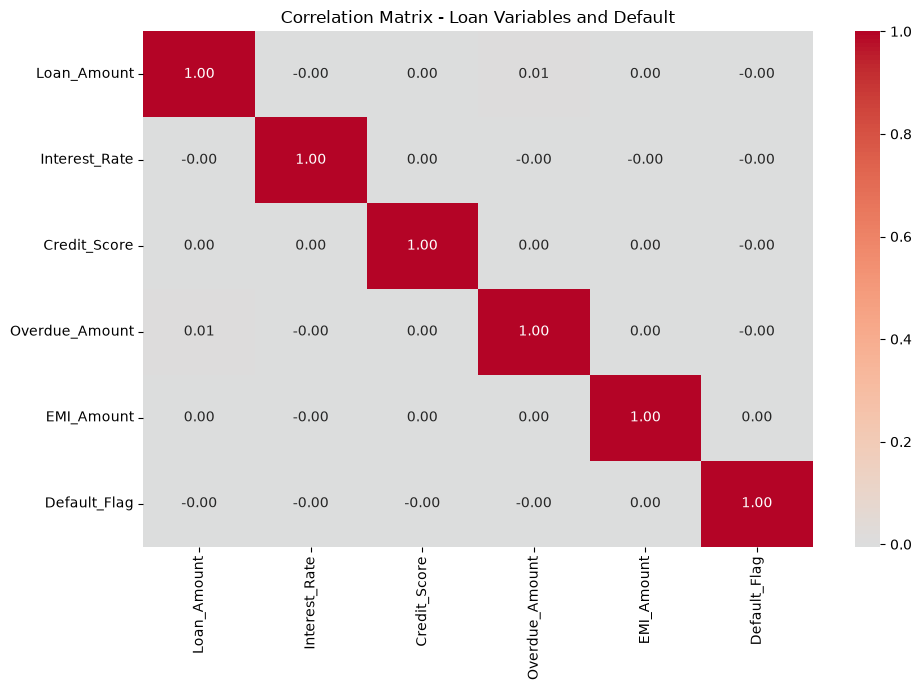

In [209]:
os.makedirs("plots", exist_ok=True)

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix - Loan Variables and Default")
plt.tight_layout()

plt.savefig(
    "plots/loan_default_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The correlation analysis shows very weak linear relationships between the selected numerical loan variables and default status. All correlations with Default_Flag are close to zero. Therefore, none of these variables shows a meaningful linear association with default in this dataset. However, correlation alone cannot rule out nonlinear or interaction effects, so the variables should not be discarded solely based on this analysis.

A model that simply predicts: Default_Flag = 0
for every loan would already have about 90.5% accuracy, while being completely useless for identifying defaults.

Therefore, later you should look at:

Precision
Recall
F1-score
Confusion matrix
ROC-AUC

rather than relying only on accuracy.

In [210]:
default_corr = corr["Default_Flag"].drop("Default_Flag").sort_values()

default_corr

Interest_Rate    -0.003750
Loan_Amount      -0.003313
Credit_Score     -0.001580
Overdue_Amount   -0.000687
EMI_Amount        0.002684
Name: Default_Flag, dtype: float64

In [211]:
default_corr_abs = (
    corr["Default_Flag"]
    .drop("Default_Flag")
    .abs()
    .sort_values(ascending=False)
)

default_corr_abs

Interest_Rate     0.003750
Loan_Amount       0.003313
EMI_Amount        0.002684
Credit_Score      0.001580
Overdue_Amount    0.000687
Name: Default_Flag, dtype: float64

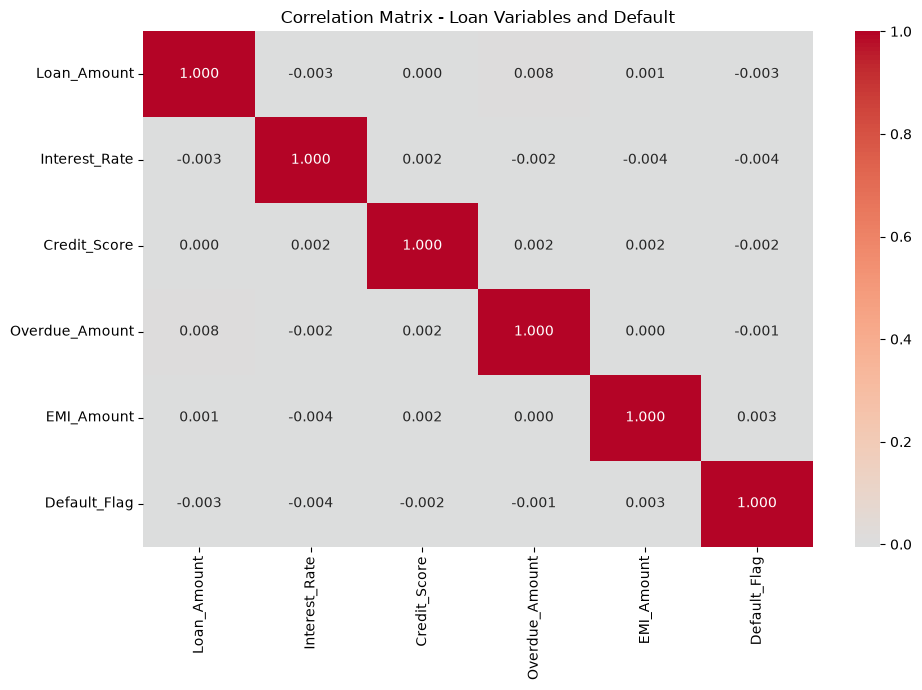

In [212]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("plots", exist_ok=True)

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix - Loan Variables and Default")
plt.tight_layout()

plt.savefig(
    "plots/loan_default_correlation1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [213]:
master["Default_Flag"] = master["Default_ID"].notna().astype(int)

In [214]:
master["Default_Flag"].value_counts()

Default_Flag
0    90000
Name: count, dtype: int64

Basic descriptive statistics

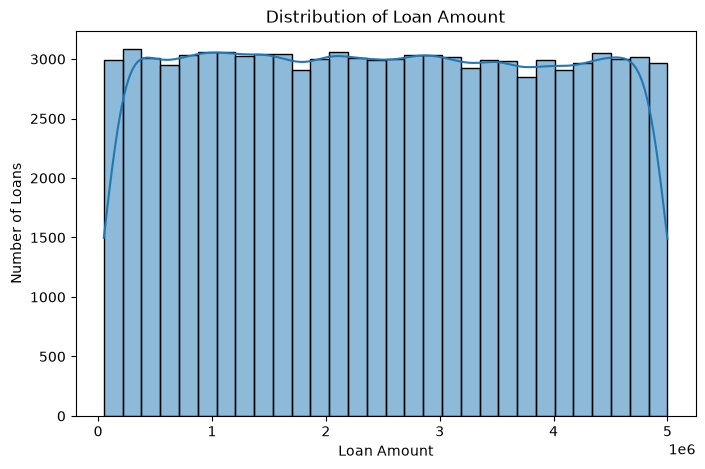

In [215]:
plt.figure(figsize=(8,5))

sns.histplot(
    loans["Loan_Amount"],
    bins=30,
    kde=True
)

plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Loans")
plt.show()

Loan Amount Distribution: The histogram shows that loan amounts are distributed relatively evenly across the range of approximately 0 to 5 million. The bars have similar frequencies throughout the range, indicating that there is no strong concentration of loans around a particular loan amount. The distribution does not show substantial skewness or a prominent extreme-value pattern. Therefore, Loan_Amount appears to be approximately uniformly distributed in this dataset.

In [216]:
loans_customer["Loan_Amount"].describe()

count    9.000000e+04
mean     2.516259e+06
std      1.429289e+06
min      5.002600e+04
25%      1.275705e+06
50%      2.510076e+06
75%      3.751702e+06
max      4.999958e+06
Name: Loan_Amount, dtype: float64

In [217]:
loans_customer["Loan_Amount"].nunique()

89185

In [218]:
plt.savefig(
    "plots/loan_amount_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

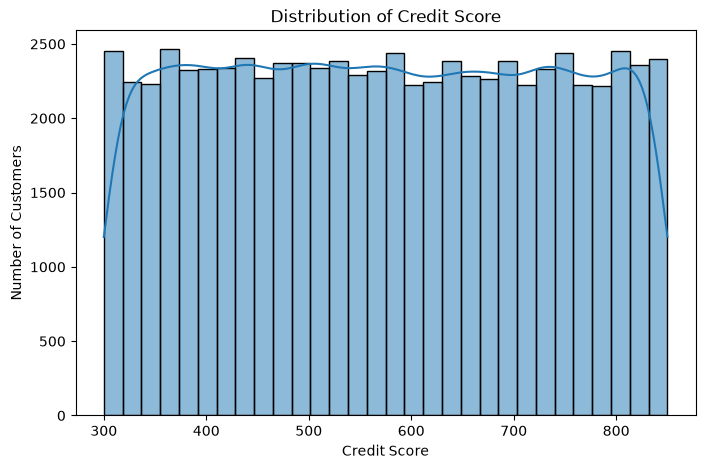

In [219]:
plt.figure(figsize=(8,5))

sns.histplot(
    customers["Credit_Score"],
    bins=30,
    kde=True
)

plt.title("Distribution of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")
plt.show()

In [220]:
plt.savefig(
    "plots/credit_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

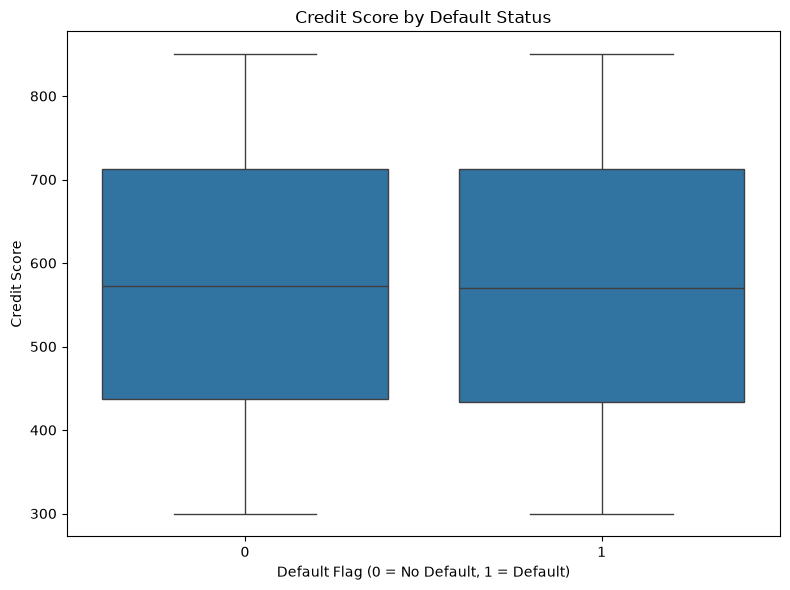

In [221]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=loans_customer,
    x="Default_Flag",
    y="Credit_Score"
)

plt.title("Credit Score by Default Status")
plt.xlabel("Default Flag (0 = No Default, 1 = Default)")
plt.ylabel("Credit Score")

plt.tight_layout()

plt.savefig(
    "plots/credit_score_by_default.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

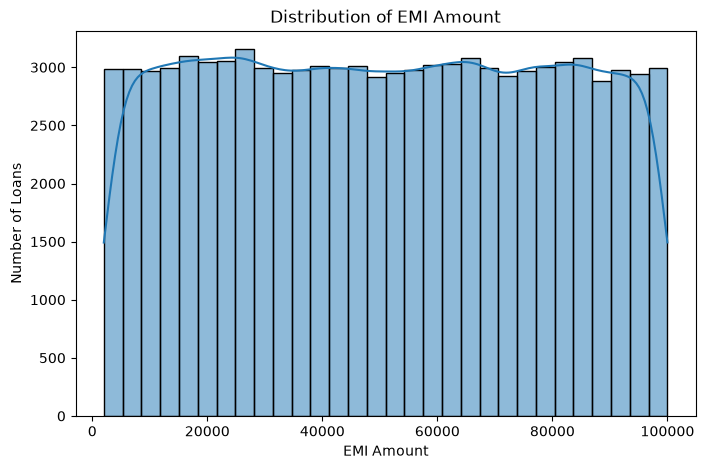

In [222]:
plt.figure(figsize=(8,5))

sns.histplot(
    loans["EMI_Amount"],
    bins=30,
    kde=True
)

plt.title("Distribution of EMI Amount")
plt.xlabel("EMI Amount")
plt.ylabel("Number of Loans")
plt.show()

EMI Amount Distribution: The histogram shows that EMI amounts are distributed relatively evenly across the range of approximately 0 to 100,000. The frequencies are fairly consistent across the different EMI ranges, indicating that loans are spread relatively evenly across the observed EMI values. There is no strong concentration or obvious skewness in the distribution

In [223]:
plt.savefig(
    "plots/emi_amount_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

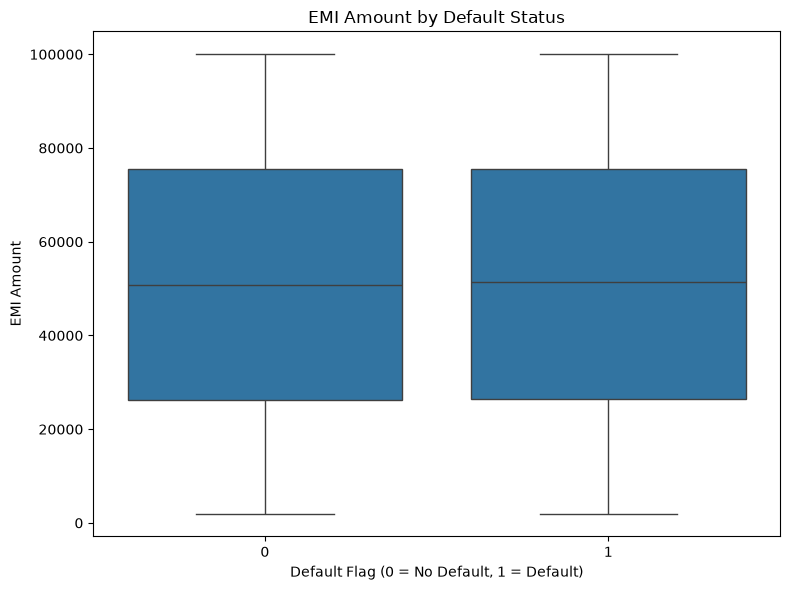

In [224]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=loans_customer,
    x="Default_Flag",
    y="EMI_Amount"
)

plt.title("EMI Amount by Default Status")
plt.xlabel("Default Flag (0 = No Default, 1 = Default)")
plt.ylabel("EMI Amount")

plt.tight_layout()

plt.savefig(
    "plots/emi_amount_by_default.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

EMI Amount by Default Status: The boxplot compares EMI amounts for defaulted and non-defaulted loans. The two groups show very similar medians, quartiles, and overall ranges, with substantial overlap between their distributions. This suggests that EMI Amount alone does not show a strong difference between defaulted and non-defaulted loans. This observation is consistent with the Pearson correlation of 0.0027 between EMI Amount and Default Flag. However, EMI Amount is retained as a potential predictor because machine-learning models may identify nonlinear relationships or interactions with other features.

In [225]:
loans["Loan_Status"].value_counts()

Loan_Status
Closed     30084
Active     30050
Overdue    29866
Name: count, dtype: int64

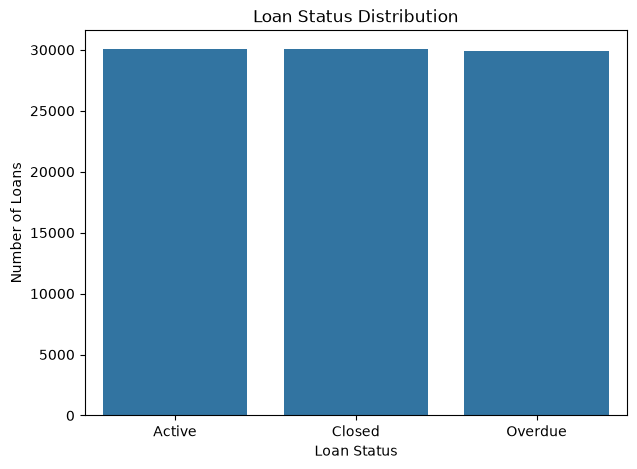

In [226]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=loans,
    x="Loan_Status"
)

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")
plt.show()

In [227]:
plt.savefig(
    "plots/loan_status_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

Loan Status Distribution: The bar chart shows the distribution of loans across Active, Closed, and Overdue statuses. Each category contains approximately 30,000 loans, resulting in an almost equal distribution across the three categories. No single loan status dominates the dataset. This balanced distribution provides representation of all three loan-status categories for subsequent analysis

In [228]:
# Check structure
loans_customer.info()

# Check default flag
print(loans_customer["Default_Flag"].value_counts())

# Correlation
corr = loans_customer[
    [
        "Loan_Amount",
        "Interest_Rate",
        "Credit_Score",
        "Overdue_Amount",
        "EMI_Amount",
        "Default_Flag"
    ]
].corr()

print(corr)

<class 'pandas.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Loan_ID               90000 non-null  str    
 1   Customer_ID           90000 non-null  str    
 2   Loan_Amount           90000 non-null  int64  
 3   Interest_Rate         90000 non-null  float64
 4   Loan_Term             90000 non-null  int64  
 5   Disbursal_Date        90000 non-null  str    
 6   Repayment_Start_Date  90000 non-null  str    
 7   Repayment_End_Date    90000 non-null  str    
 8   Loan_Status           90000 non-null  str    
 9   Overdue_Amount        90000 non-null  int64  
 10  EMI_Amount            90000 non-null  int64  
 11  Collateral_Details    90000 non-null  str    
 12  Default_Flag          90000 non-null  int64  
 13  Credit_Score          90000 non-null  int64  
dtypes: float64(1), int64(6), str(7)
memory usage: 14.7 MB
Default_Flag
0    81461
1  

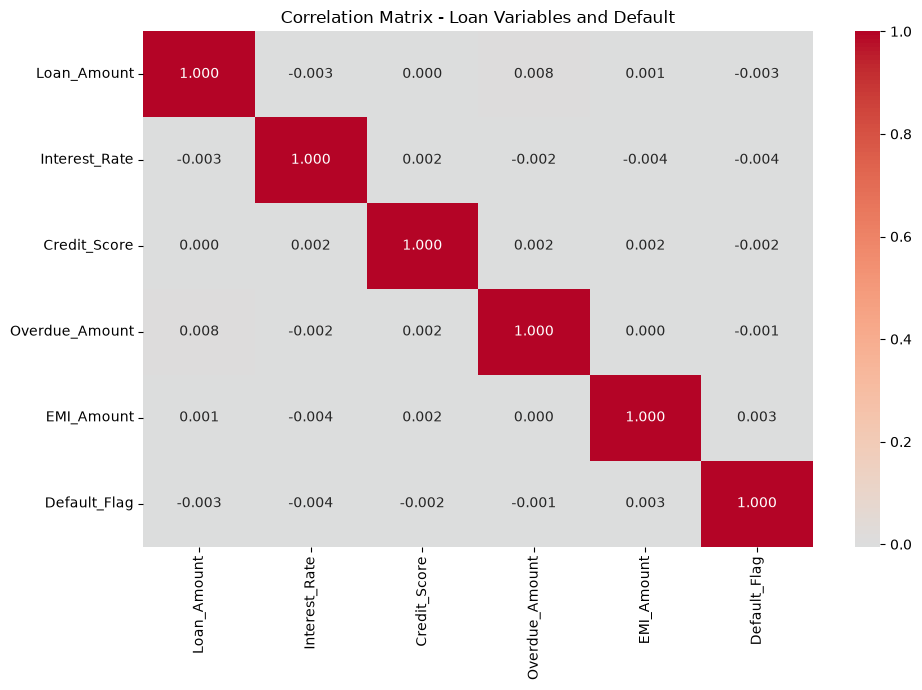

In [229]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix - Loan Variables and Default")
plt.tight_layout()

plt.savefig(
    "plots/loan_default_variables_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [230]:
defaults["Recovery_Rate"] = (
    defaults["Recovery_Amount"] / defaults["Default_Amount"]
) * 100

In [231]:
defaults[
    ["Default_Amount", "Recovery_Amount", "Recovery_Rate"]
].head()

,Default_Amount,Recovery_Amount,Recovery_Rate
0,94480,30360,32.133785
1,10912,0,0.000000
2,73711,9866,13.384705
3,48955,0,0.000000
4,56952,0,0.000000


In [232]:
print("Zero Default Amounts:",
      (defaults["Default_Amount"] == 0).sum())

Zero Default Amounts: 0


In [233]:
defaults["Recovery_Rate"] = (
    defaults["Recovery_Amount"]
    / defaults["Default_Amount"].replace(0, pd.NA)
) * 100

In [234]:
q2_data = loans_customer[
    ["Loan_ID", "EMI_Amount"]
].merge(
    defaults[
        ["Loan_ID", "Default_Amount", "Recovery_Rate"]
    ],
    on="Loan_ID",
    how="inner"
)

In [235]:
q2_data

,Loan_ID,EMI_Amount,Default_Amount,Recovery_Rate
0,L000009,97277,48655,92.520810
1,L000019,63222,47609,0.000000
2,L000025,42173,23052,199.084678
3,L000039,18704,33041,12.305923
4,L000050,32124,28774,80.329464
...,...,...,...,...
8995,L089964,22103,11510,383.675065
8996,L089970,67779,35299,57.817502
8997,L089984,92108,81215,35.619036
8998,L089987,13885,6574,0.000000


In [236]:
q2_data.shape

(9000, 4)

In [237]:
q2_data[
    ["EMI_Amount", "Default_Amount", "Recovery_Rate"]
].isnull().sum()

EMI_Amount        0
Default_Amount    0
Recovery_Rate     0
dtype: int64

In [238]:
q2_data[
    ["EMI_Amount", "Default_Amount", "Recovery_Rate"]
].dtypes

EMI_Amount          int64
Default_Amount      int64
Recovery_Rate     float64
dtype: object

In [239]:
#Paiwise Correlation Matrix
q2_corr = q2_data[
    [
        "EMI_Amount",
        "Default_Amount",
        "Recovery_Rate"
    ]
].corr()

q2_corr

,EMI_Amount,Default_Amount,Recovery_Rate
EMI_Amount,1.000000,0.007650,-0.008247
Default_Amount,0.007650,1.000000,-0.374882
Recovery_Rate,-0.008247,-0.374882,1.000000


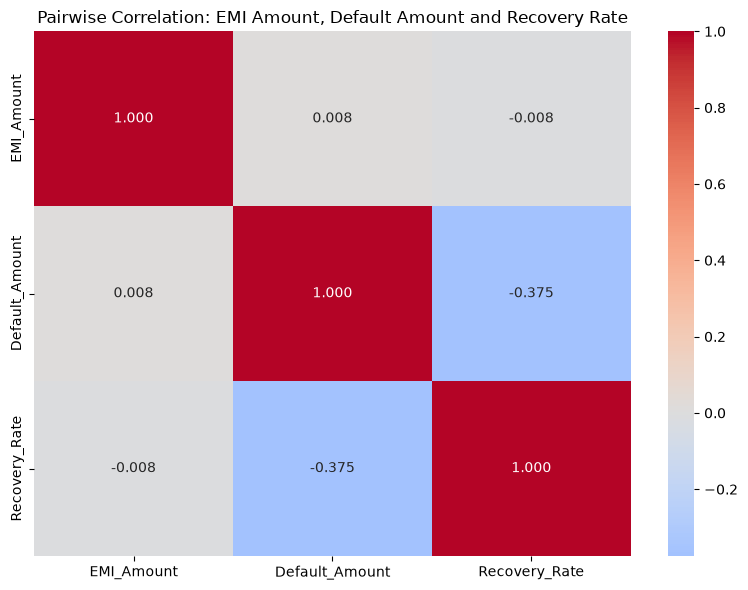

In [240]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("plots", exist_ok=True)

plt.figure(figsize=(8, 6))

sns.heatmap(
    q2_corr,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Pairwise Correlation: EMI Amount, Default Amount and Recovery Rate"
)

plt.tight_layout()

plt.savefig(
    "plots/pairwise_correlation_default_recovery.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [242]:
q2_corr.loc["EMI_Amount", "Default_Amount"]

np.float64(0.007650419191113595)

In [243]:
q2_corr.loc["EMI_Amount", "Recovery_Rate"]

np.float64(-0.008247251714819864)

In [244]:
q2_corr.loc["Default_Amount", "Recovery_Rate"]

np.float64(-0.37488177533433176)

In [245]:
q2_corr.abs()

,EMI_Amount,Default_Amount,Recovery_Rate
EMI_Amount,1.000000,0.007650,0.008247
Default_Amount,0.007650,1.000000,0.374882
Recovery_Rate,0.008247,0.374882,1.000000


| Variable pair                      |  Correlation | Interpretation                         |
| ---------------------------------- | -----------: | -------------------------------------- |
| `EMI_Amount` ↔ `Default_Amount`    | **0.007650** | Very weak positive relationship        |
| `EMI_Amount` ↔ `Recovery_Rate`     | **0.008247** | Very weak positive relationship        |
| `Default_Amount` ↔ `Recovery_Rate` | **0.374882** | Weak-to-moderate positive relationship |


Loans with larger default amounts tend to have somewhat higher recovery rates in this dataset, although the relationship is not strong enough to indicate that default amount alone determines recovery rate.

Pairwise Correlation Analysis: A correlation analysis was conducted to examine the relationships among EMI Amount, Default Amount, and Recovery Rate. The correlation between EMI Amount and Default Amount was 0.0077, indicating an extremely weak positive linear relationship. Similarly, EMI Amount and Recovery Rate had a correlation of 0.0082, showing almost no linear association. The strongest relationship was observed between Default Amount and Recovery Rate, with a correlation of 0.3749, indicating a weak-to-moderate positive relationship. Overall, the results suggest that EMI Amount has little linear association with either default amount or recovery rate, while larger default amounts show some positive association with recovery rates.

In [247]:
branches.head()

,Branch_ID,Branch_Name,Region,Total_Customers,Total_Active_Loans,Delinquent_Loans,Loan_Disbursement_Amount,Avg_Processing_Time,Relationship_Manager_Count
0,B001,"Dhar, Kant and Madan",West,2891,279,21,341680882,6,29
1,B002,Shan Group,East,4459,1201,149,96549019,8,35
2,B003,Sachdev-Banerjee,Central,2504,122,168,445787808,12,48
3,B004,Kapadia-Brar,East,1542,1422,96,353934299,9,50
4,B005,"Mangal, Kaur and Borde",South,945,1613,87,311637902,11,10


In [248]:
branches.columns

Index(['Branch_ID', 'Branch_Name', 'Region', 'Total_Customers',
       'Total_Active_Loans', 'Delinquent_Loans', 'Loan_Disbursement_Amount',
       'Avg_Processing_Time', 'Relationship_Manager_Count'],
      dtype='str')

In [249]:
branches.shape

(50, 9)

In [250]:
branches["Delinquency_Rate"] = (
    branches["Delinquent_Loans"]
    / branches["Total_Active_Loans"]
) * 100

In [251]:
branches[
    [
        "Branch_ID",
        "Total_Active_Loans",
        "Delinquent_Loans",
        "Delinquency_Rate"
    ]
].head()

,Branch_ID,Total_Active_Loans,Delinquent_Loans,Delinquency_Rate
0,B001,279,21,7.526882
1,B002,1201,149,12.406328
2,B003,122,168,137.704918
3,B004,1422,96,6.751055
4,B005,1613,87,5.393676


Suppose:

Branch A has 100 delinquent loans out of 1,000 active loans → 10%
Branch B has 200 delinquent loans out of 10,000 active loans → 2%

Looking only at Delinquent_Loans would make Branch B look worse, but its delinquency rate is actually lower.

So the rate is more useful for comparing branches of different sizes.

In [252]:
defaults["Recovery_Rate"]

0       32.133785
1        0.000000
2       13.384705
3        0.000000
4        0.000000
          ...    
8995    80.395387
8996     0.000000
8997    68.206522
8998    21.979017
8999     0.000000
Name: Recovery_Rate, Length: 9000, dtype: float64

In [253]:
defaults["Recovery_Rate"] = (
    defaults["Recovery_Amount"]
    / defaults["Default_Amount"]
) * 100

In [254]:
print(defaults.columns.tolist())

['Default_ID', 'Loan_ID', 'Customer_ID', 'Default_Date', 'Default_Amount', 'Default_Reason', 'Recovery_Status', 'Recovery_Amount', 'Legal_Action', 'Recovery_Rate']


In [255]:
branches.columns.tolist()

['Branch_ID',
 'Branch_Name',
 'Region',
 'Total_Customers',
 'Total_Active_Loans',
 'Delinquent_Loans',
 'Loan_Disbursement_Amount',
 'Avg_Processing_Time',
 'Relationship_Manager_Count',
 'Delinquency_Rate']

In [257]:
branch_analysis = branches[
    [
        "Branch_ID",
        "Region",
        "Total_Active_Loans",
        "Delinquent_Loans",
        "Loan_Disbursement_Amount"
    ]
].copy()

In [258]:
branch_analysis.head()

,Branch_ID,Region,Total_Active_Loans,Delinquent_Loans,Loan_Disbursement_Amount
0,B001,West,279,21,341680882
1,B002,East,1201,149,96549019
2,B003,Central,122,168,445787808
3,B004,East,1422,96,353934299
4,B005,South,1613,87,311637902


In [259]:
branch_analysis.shape

(50, 5)

In [260]:
branch_analysis["Delinquency_Rate"] = (
    branch_analysis["Delinquent_Loans"]
    / branch_analysis["Total_Active_Loans"]
) * 100

In [261]:
branch_analysis[
    [
        "Branch_ID",
        "Delinquent_Loans",
        "Total_Active_Loans",
        "Delinquency_Rate"
    ]
].head()

,Branch_ID,Delinquent_Loans,Total_Active_Loans,Delinquency_Rate
0,B001,21,279,7.526882
1,B002,149,1201,12.406328
2,B003,168,122,137.704918
3,B004,96,1422,6.751055
4,B005,87,1613,5.393676


In [262]:
print(loans_customer.columns.tolist())

['Loan_ID', 'Customer_ID', 'Loan_Amount', 'Interest_Rate', 'Loan_Term', 'Disbursal_Date', 'Repayment_Start_Date', 'Repayment_End_Date', 'Loan_Status', 'Overdue_Amount', 'EMI_Amount', 'Collateral_Details', 'Default_Flag', 'Credit_Score']


In [263]:
print(defaults.columns.tolist())

['Default_ID', 'Loan_ID', 'Customer_ID', 'Default_Date', 'Default_Amount', 'Default_Reason', 'Recovery_Status', 'Recovery_Amount', 'Legal_Action', 'Recovery_Rate']


In [264]:
print(applications.columns.tolist())

['Application_ID', 'Loan_ID', 'Customer_ID', 'Application_Date', 'Approval_Date', 'Loan_Purpose', 'Source_Channel', 'Processing_Fee', 'Approval_Status', 'Rejection_Reason', 'Valid_Approval_Date', 'Approval_Date_Status', 'Date_Valid']


In [265]:
print(branches.columns.tolist())

['Branch_ID', 'Branch_Name', 'Region', 'Total_Customers', 'Total_Active_Loans', 'Delinquent_Loans', 'Loan_Disbursement_Amount', 'Avg_Processing_Time', 'Relationship_Manager_Count', 'Delinquency_Rate']


In [267]:
print(loans.columns.tolist())

['Loan_ID', 'Customer_ID', 'Loan_Amount', 'Interest_Rate', 'Loan_Term', 'Disbursal_Date', 'Repayment_Start_Date', 'Repayment_End_Date', 'Loan_Status', 'Overdue_Amount', 'EMI_Amount', 'Collateral_Details', 'Default_Flag']


Branch
  
   ↓

Branch_ID

   ↓

Loans

   ↓

Loan_ID

   ↓

Defaults

In [272]:
branch_analysis = branches[
    [
        "Branch_ID",
        "Branch_Name",
        "Region",
        "Total_Active_Loans",
        "Delinquent_Loans",
        "Loan_Disbursement_Amount",
        "Avg_Processing_Time",
        "Delinquency_Rate"
    ]
].copy()

In [273]:
branch_analysis.head()

,Branch_ID,Branch_Name,Region,Total_Active_Loans,Delinquent_Loans,Loan_Disbursement_Amount,Avg_Processing_Time,Delinquency_Rate
0,B001,"Dhar, Kant and Madan",West,279,21,341680882,6,7.526882
1,B002,Shan Group,East,1201,149,96549019,8,12.406328
2,B003,Sachdev-Banerjee,Central,122,168,445787808,12,137.704918
3,B004,Kapadia-Brar,East,1422,96,353934299,9,6.751055
4,B005,"Mangal, Kaur and Borde",South,1613,87,311637902,11,5.393676


In [274]:
branch_analysis.isnull().sum()

Branch_ID                   0
Branch_Name                 0
Region                      0
Total_Active_Loans          0
Delinquent_Loans            0
Loan_Disbursement_Amount    0
Avg_Processing_Time         0
Delinquency_Rate            0
dtype: int64

In [275]:
branch_corr = branch_analysis[
    [
        "Delinquent_Loans",
        "Loan_Disbursement_Amount",
        "Delinquency_Rate",
        "Avg_Processing_Time"
    ]
].corr()

branch_corr

,Delinquent_Loans,Loan_Disbursement_Amount,Delinquency_Rate,Avg_Processing_Time
Delinquent_Loans,1.000000,0.023648,0.473941,-0.022108
Loan_Disbursement_Amount,0.023648,1.000000,0.042768,-0.060313
Delinquency_Rate,0.473941,0.042768,1.000000,0.079919
Avg_Processing_Time,-0.022108,-0.060313,0.079919,1.000000


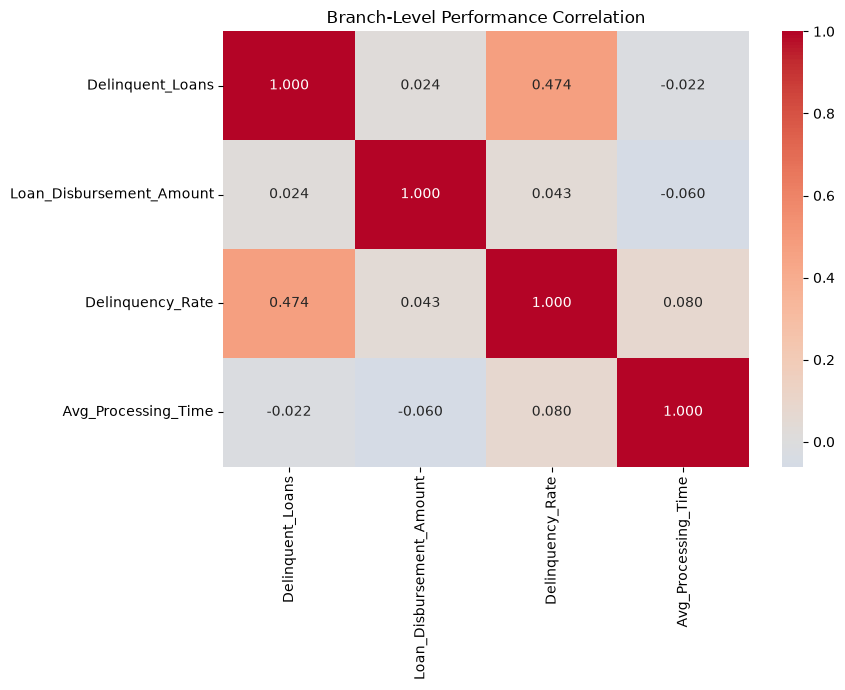

In [276]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    branch_corr,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0
)

plt.title("Branch-Level Performance Correlation")

plt.tight_layout()

plt.savefig(
    "plots/branch_level_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

| Relationship                                       |   Correlation | Interpretation                  |
| -------------------------------------------------- | ------------: | ------------------------------- |
| `Delinquent_Loans` ↔ `Loan_Disbursement_Amount`    |  **0.023648** | Very weak positive relationship |
| `Delinquent_Loans` ↔ `Delinquency_Rate`            |  **0.473941** | Moderate positive relationship  |
| `Delinquent_Loans` ↔ `Avg_Processing_Time`         | **-0.022108** | Very weak negative relationship |
| `Loan_Disbursement_Amount` ↔ `Delinquency_Rate`    |  **0.042768** | Very weak positive relationship |
| `Loan_Disbursement_Amount` ↔ `Avg_Processing_Time` | **-0.060313** | Very weak negative relationship |
| `Delinquency_Rate` ↔ `Avg_Processing_Time`         |  **0.079919** | Very weak positive relationship |


Branch-Level Correlation Analysis: The correlation analysis examined relationships among delinquent loans, loan disbursement amount, delinquency rate, and average processing time across branches. The strongest relationship was between Delinquent Loans and Delinquency Rate, with a correlation of 0.474, indicating a moderate positive association. Loan Disbursement Amount had very weak relationships with Delinquent Loans (0.024) and Delinquency Rate (0.043). Average Processing Time also showed very weak relationships with Delinquent Loans (-0.022) and Loan Disbursement Amount (-0.060), while its correlation with Delinquency Rate was 0.080. Overall, the results suggest that branch disbursement volume and processing time have little linear relationship with delinquency performance in this dataset. The branch-level Recovery Rate could not be reliably calculated because the available loan-level data does not contain a Branch_ID linking loans/defaults to individual branches.

In [277]:
print(transactions.columns.tolist())

['Transaction_ID', 'Loan_ID', 'Customer_ID', 'Transaction_Date', 'Payment_Type', 'Amount', 'Overdue_Fee', 'Remaining_Balance', 'Mode_of_Payment']


In [278]:
print(transactions.head())

  Transaction_ID  Loan_ID Customer_ID Transaction_Date Payment_Type  Amount  \
0      T00000001  L005588     C050792       2021-04-30          EMI   46099   
1      T00000002  L019942     C008919       2021-12-14      Penalty   43648   
2      T00000003  L014848     C016745       2021-01-26          EMI    1810   
3      T00000004  L041104     C039957       2021-02-18      Penalty    8607   
4      T00000005  L002488     C056156       2024-12-07      Penalty   34720   

   Overdue_Fee  Remaining_Balance Mode_of_Payment  
0         1313            1513669            NEFT  
1         4852             901455             UPI  
2            0            1922629            Cash  
3          708             213581             UPI  
4            0             411621             UPI  


In [279]:
transactions.head()

,Transaction_ID,Loan_ID,Customer_ID,Transaction_Date,Payment_Type,Amount,Overdue_Fee,Remaining_Balance,Mode_of_Payment
0,T00000001,L005588,C050792,2021-04-30,EMI,46099,1313,1513669,NEFT
1,T00000002,L019942,C008919,2021-12-14,Penalty,43648,4852,901455,UPI
2,T00000003,L014848,C016745,2021-01-26,EMI,1810,0,1922629,Cash
3,T00000004,L041104,C039957,2021-02-18,Penalty,8607,708,213581,UPI
4,T00000005,L002488,C056156,2024-12-07,Penalty,34720,0,411621,UPI


In [280]:
transactions.shape

(495000, 9)

In [281]:
transactions.isnull().sum()

Transaction_ID       0
Loan_ID              0
Customer_ID          0
Transaction_Date     0
Payment_Type         0
Amount               0
Overdue_Fee          0
Remaining_Balance    0
Mode_of_Payment      0
dtype: int64

In [282]:
transactions["Payment_Type"].value_counts()

Payment_Type
Penalty    247844
EMI        247156
Name: count, dtype: int64

In [283]:
penalty_transactions = transactions[
    transactions["Payment_Type"] == "Penalty"
].copy()

In [285]:
len(penalty_transactions)

247844

In [286]:
total_penalty_amount = penalty_transactions["Amount"].sum()

total_penalty_amount

np.int64(6318173036)

In [287]:
total_transactions = len(transactions)

penalty_count = len(penalty_transactions)

penalty_percentage = (
    penalty_count / total_transactions
) * 100

penalty_percentage

50.06949494949495

In [288]:
total_overdue_fees = transactions["Overdue_Fee"].sum()

total_overdue_fees

np.int64(630299779)

In [289]:
average_overdue_fee = transactions["Overdue_Fee"].mean()

average_overdue_fee

np.float64(1273.332886868687)

In [290]:
penalty_transactions["Overdue_Fee"].sum()

np.int64(315585516)

In [291]:
transactions["Transaction_Date"] = pd.to_datetime(
    transactions["Transaction_Date"],
    errors="coerce"
)

In [292]:
transactions["Transaction_Date"].dtype

dtype('<M8[us]')

In [294]:
transactions["Transaction_Date"].min(), transactions["Transaction_Date"].max()

(Timestamp('2019-12-28 00:00:00'), Timestamp('2024-12-27 00:00:00'))

In [295]:
transactions["Payment_Type"].value_counts()

Payment_Type
Penalty    247844
EMI        247156
Name: count, dtype: int64

In [297]:
penalty_transactions = transactions[
    transactions["Payment_Type"] == "Penalty"
].copy()

In [298]:
penalty_transactions.shape

(247844, 9)

In [299]:
penalty_count = len(penalty_transactions)

total_transactions = len(transactions)

penalty_percentage = (
    penalty_count / total_transactions
) * 100

total_penalty_amount = penalty_transactions["Amount"].sum()

average_penalty_amount = penalty_transactions["Amount"].mean()

total_overdue_fee = penalty_transactions["Overdue_Fee"].sum()

average_overdue_fee = penalty_transactions["Overdue_Fee"].mean()

In [300]:
print("Total Transactions:", total_transactions)
print("Penalty Transactions:", penalty_count)
print("Penalty Percentage:", round(penalty_percentage, 2), "%")
print("Total Penalty Amount:", total_penalty_amount)
print("Average Penalty Amount:", round(average_penalty_amount, 2))
print("Total Overdue Fees:", total_overdue_fee)
print("Average Overdue Fee:", round(average_overdue_fee, 2))

Total Transactions: 495000
Penalty Transactions: 247844
Penalty Percentage: 50.07 %
Total Penalty Amount: 6318173036
Average Penalty Amount: 25492.54
Total Overdue Fees: 315585516
Average Overdue Fee: 1273.32


In [301]:
penalty_transactions["Month"] = (
    penalty_transactions["Transaction_Date"]
    .dt.to_period("M")
)

In [302]:
monthly_penalty = (
    penalty_transactions
    .groupby("Month")
    .agg(
        Penalty_Count=("Transaction_ID", "count"),
        Penalty_Amount=("Amount", "sum"),
        Overdue_Fee=("Overdue_Fee", "sum")
    )
    .reset_index()
)

In [303]:
monthly_penalty.head()

,Month,Penalty_Count,Penalty_Amount,Overdue_Fee
0,2019-12,532,13303625,677921
1,2020-01,4200,106916133,5363980
2,2020-02,4067,105960952,5178007
3,2020-03,4217,106585687,5433000
4,2020-04,3986,100063569,5061901


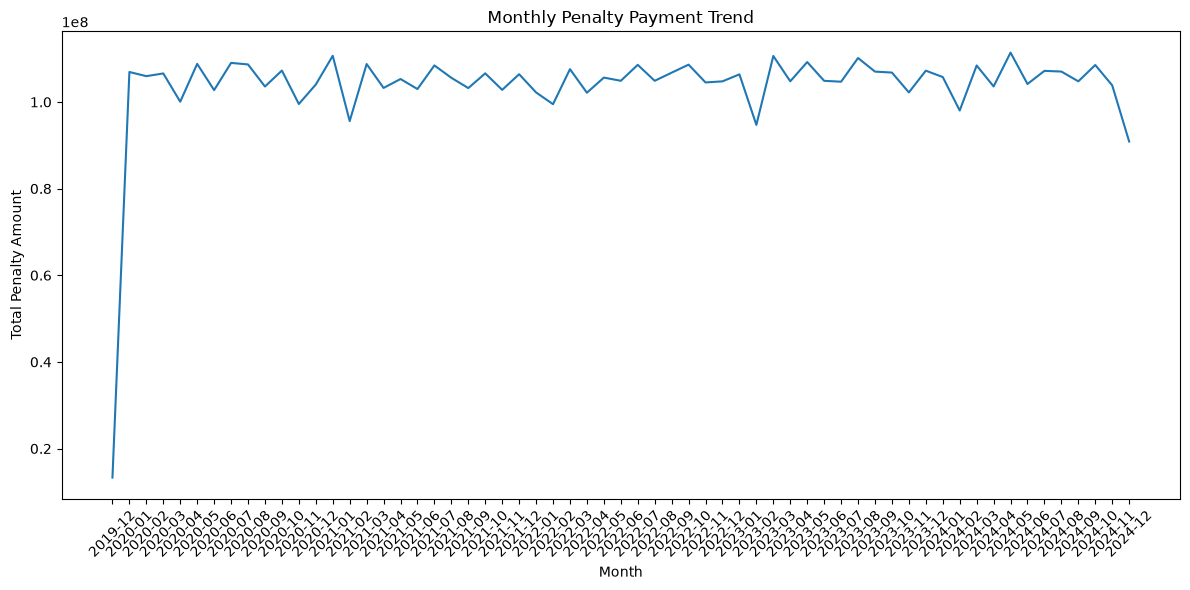

In [304]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_penalty["Month"].astype(str),
    monthly_penalty["Penalty_Amount"]
)

plt.title("Monthly Penalty Payment Trend")
plt.xlabel("Month")
plt.ylabel("Total Penalty Amount")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "plots/monthly_penalty_payment_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The monthly penalty payment trend shows relatively stable penalty amounts throughout most of the observation period from 2020 to 2024, with monthly values generally fluctuating around ₹100–110 million. Some month-to-month variations are visible, but there is no clear long-term increasing or decreasing trend. The unusually low values at the beginning and end of the period are likely influenced by the incomplete December 2019 and December 2024 observation periods.

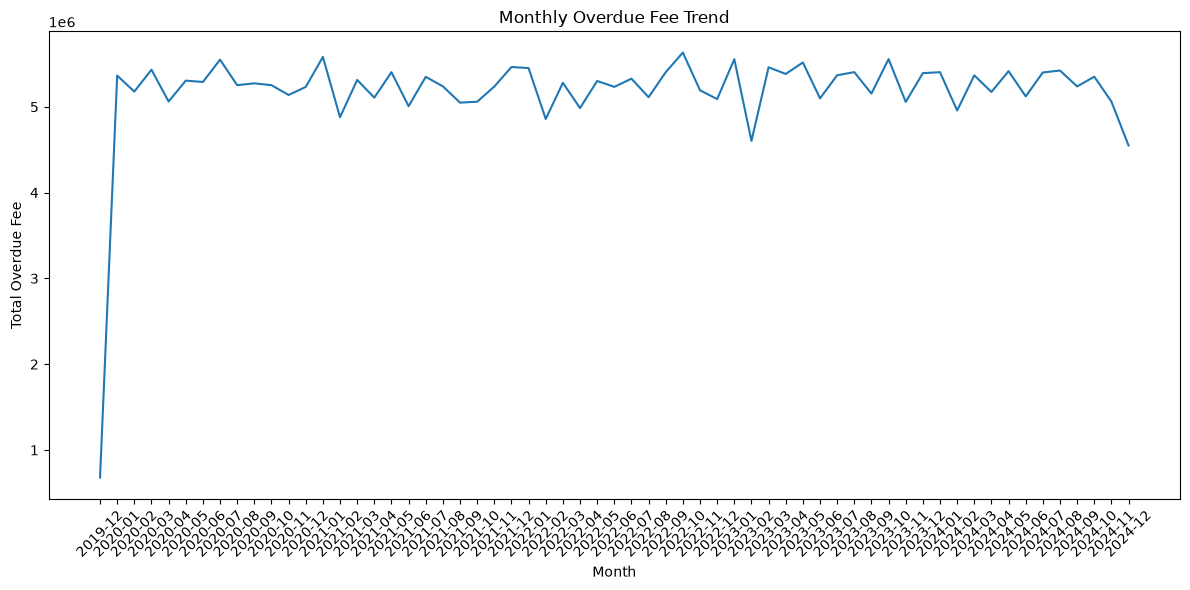

In [305]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_penalty["Month"].astype(str),
    monthly_penalty["Overdue_Fee"]
)

plt.title("Monthly Overdue Fee Trend")
plt.xlabel("Month")
plt.ylabel("Total Overdue Fee")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "plots/monthly_overdue_fee_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The monthly overdue fee trend remains relatively stable over the main observation period, generally ranging around ₹5–5.5 million per month. Although there are several month-to-month fluctuations, there is no strong sustained upward or downward trend. The lower values at the beginning and end of the period should be interpreted cautiously because December 2019 and December 2024 do not represent complete months.

In [307]:
transactions["Overdue_Status"] = transactions[
    "Overdue_Fee"
].apply(
    lambda x: "Overdue" if x > 0 else "Non-Overdue"
)

In [308]:
transactions["Overdue_Status"].value_counts()

Overdue_Status
Non-Overdue    247549
Overdue        247451
Name: count, dtype: int64

In [309]:
overdue_comparison = (
    transactions
    .groupby("Overdue_Status")["Amount"]
    .agg(["count", "sum", "mean"])
)

overdue_comparison

,count,sum,mean
Overdue_Status,,,
Non-Overdue,247549,6314626157,25508.590853
Overdue,247451,6306103896,25484.253028


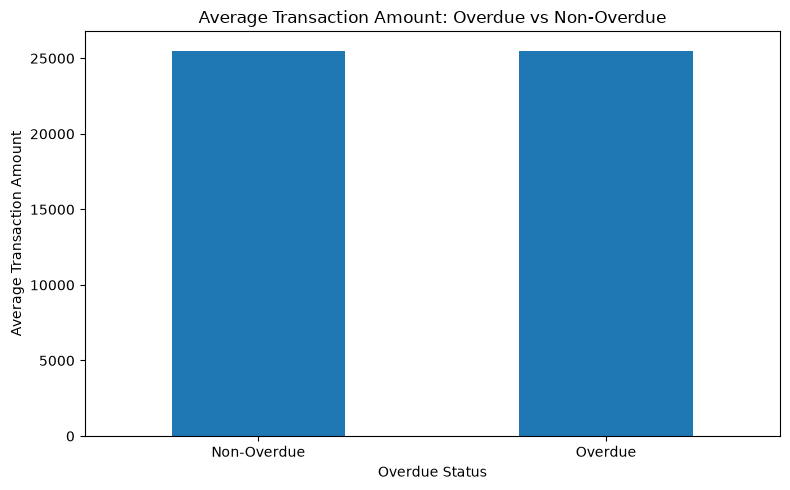

In [310]:
plt.figure(figsize=(8, 5))

overdue_comparison["mean"].plot(kind="bar")

plt.title("Average Transaction Amount: Overdue vs Non-Overdue")
plt.xlabel("Overdue Status")
plt.ylabel("Average Transaction Amount")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "plots/overdue_vs_nonoverdue_transaction_amount.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Overdue vs Non-Overdue Transaction Analysis: The comparison of average transaction amounts between overdue and non-overdue transactions shows very similar values for both groups, with both averages being approximately ₹25,000. This indicates that there is little difference in the average transaction amount based on overdue status. Therefore, the analysis does not provide evidence of a strong relationship between overdue status and the average transaction amount.

In [311]:
print(defaults[
    [
        "Default_Amount",
        "Default_Reason",
        "Recovery_Amount",
        "Legal_Action",
        "Recovery_Rate"
    ]
].head())

   Default_Amount     Default_Reason  Recovery_Amount Legal_Action  \
0           94480           Job Loss            30360          Yes   
1           10912           Job Loss                0          Yes   
2           73711              Other             9866          Yes   
3           48955              Other                0          Yes   
4           56952  Medical Emergency                0           No   

   Recovery_Rate  
0      32.133785  
1       0.000000  
2      13.384705  
3       0.000000  
4       0.000000  


In [312]:
defaults[
    [
        "Default_Amount",
        "Recovery_Amount",
        "Recovery_Rate"
    ]
].isnull().sum()

Default_Amount     0
Recovery_Amount    0
Recovery_Rate      0
dtype: int64

In [313]:
defaults["Default_Reason"].value_counts()

Default_Reason
Other                2293
Business Failure     2285
Medical Emergency    2262
Job Loss             2160
Name: count, dtype: int64

In [314]:
recovery_by_reason = (
    defaults
    .groupby("Default_Reason")
    .agg(
        Default_Count=("Default_ID", "count"),
        Total_Default_Amount=("Default_Amount", "sum"),
        Total_Recovery_Amount=("Recovery_Amount", "sum"),
        Average_Recovery_Rate=("Recovery_Rate", "mean")
    )
    .reset_index()
)

In [315]:
recovery_by_reason

,Default_Reason,Default_Count,Total_Default_Amount,Total_Recovery_Amount,Average_Recovery_Rate
0,Business Failure,2285,121925983,29818593,40.362705
1,Job Loss,2160,113477409,26835222,40.617378
2,Medical Emergency,2262,119083296,30263160,41.793930
3,Other,2293,122321069,29002838,39.076132


In [316]:
recovery_by_reason.sort_values(
    "Average_Recovery_Rate",
    ascending=False
)

,Default_Reason,Default_Count,Total_Default_Amount,Total_Recovery_Amount,Average_Recovery_Rate
2,Medical Emergency,2262,119083296,30263160,41.793930
1,Job Loss,2160,113477409,26835222,40.617378
0,Business Failure,2285,121925983,29818593,40.362705
3,Other,2293,122321069,29002838,39.076132


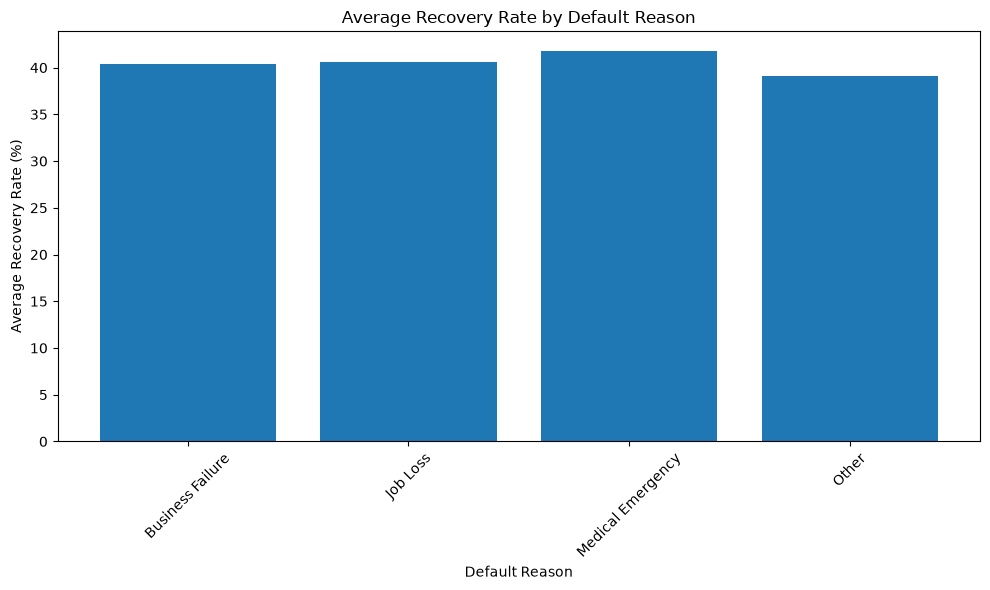

In [317]:
plt.figure(figsize=(10, 6))

plt.bar(
    recovery_by_reason["Default_Reason"],
    recovery_by_reason["Average_Recovery_Rate"]
)

plt.title("Average Recovery Rate by Default Reason")
plt.xlabel("Default Reason")
plt.ylabel("Average Recovery Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "plots/recovery_rate_by_default_reason.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [318]:
recovery_by_legal = (
    defaults
    .groupby("Legal_Action")
    .agg(
        Default_Count=("Default_ID", "count"),
        Total_Default_Amount=("Default_Amount", "sum"),
        Total_Recovery_Amount=("Recovery_Amount", "sum"),
        Average_Recovery_Rate=("Recovery_Rate", "mean")
    )
    .reset_index()
)

In [319]:
recovery_by_legal

,Legal_Action,Default_Count,Total_Default_Amount,Total_Recovery_Amount,Average_Recovery_Rate
0,No,4550,242087969,58458449,40.180507
1,Yes,4450,234719788,57461364,40.737180


In [320]:
recovery_by_legal.sort_values(
    "Average_Recovery_Rate",
    ascending=False
)

,Legal_Action,Default_Count,Total_Default_Amount,Total_Recovery_Amount,Average_Recovery_Rate
1,Yes,4450,234719788,57461364,40.737180
0,No,4550,242087969,58458449,40.180507


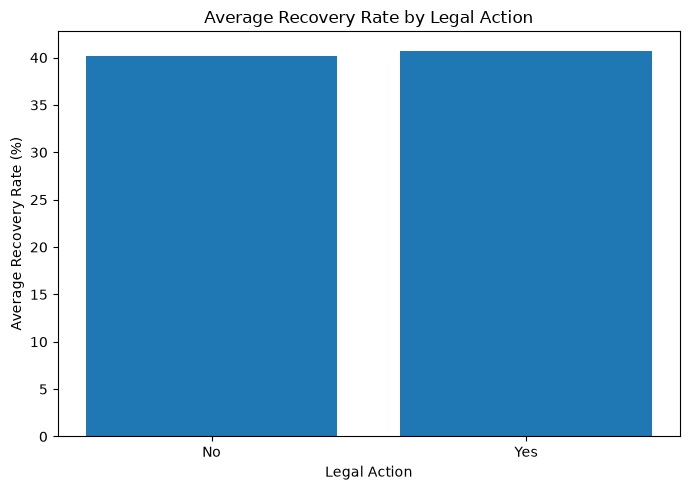

In [321]:
plt.figure(figsize=(7, 5))

plt.bar(
    recovery_by_legal["Legal_Action"],
    recovery_by_legal["Average_Recovery_Rate"]
)

plt.title("Average Recovery Rate by Legal Action")
plt.xlabel("Legal Action")
plt.ylabel("Average Recovery Rate (%)")

plt.tight_layout()

plt.savefig(
    "plots/recovery_rate_by_legal_action.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [322]:
recovery_by_reason = (
    defaults
    .groupby("Default_Reason")
    .agg(
        Default_Count=("Default_ID", "count"),
        Total_Default_Amount=("Default_Amount", "sum"),
        Total_Recovery_Amount=("Recovery_Amount", "sum"),
        Average_Recovery_Rate=("Recovery_Rate", "mean")
    )
    .reset_index()
)

recovery_by_reason

,Default_Reason,Default_Count,Total_Default_Amount,Total_Recovery_Amount,Average_Recovery_Rate
0,Business Failure,2285,121925983,29818593,40.362705
1,Job Loss,2160,113477409,26835222,40.617378
2,Medical Emergency,2262,119083296,30263160,41.793930
3,Other,2293,122321069,29002838,39.076132


Recovery rates were relatively similar across the different default reasons. Medical Emergency had the highest average recovery rate at 41.79%, followed by Job Loss at 40.62% and Business Failure at 40.36%. The Other category had the lowest recovery rate at 39.08%. The difference between the highest and lowest recovery rates was approximately 2.72 percentage points, indicating that recovery performance was fairly consistent across default reasons

In [324]:
recovery_by_legal = (
    defaults
    .groupby("Legal_Action")
    .agg(
        Default_Count=("Default_ID", "count"),
        Total_Default_Amount=("Default_Amount", "sum"),
        Total_Recovery_Amount=("Recovery_Amount", "sum"),
        Average_Recovery_Rate=("Recovery_Rate", "mean")
    )
    .reset_index()
)
recovery_by_legal

,Legal_Action,Default_Count,Total_Default_Amount,Total_Recovery_Amount,Average_Recovery_Rate
0,No,4550,242087969,58458449,40.180507
1,Yes,4450,234719788,57461364,40.737180


Defaults involving legal action had an average recovery rate of 40.74%, compared with 40.18% for defaults without legal action. Although the recovery rate was slightly higher when legal action was taken, the difference was only approximately 0.56 percentage points. Therefore, the descriptive results suggest only a small difference in recovery performance between the two groups. Further statistical testing would be required to determine whether this difference is statistically significant.

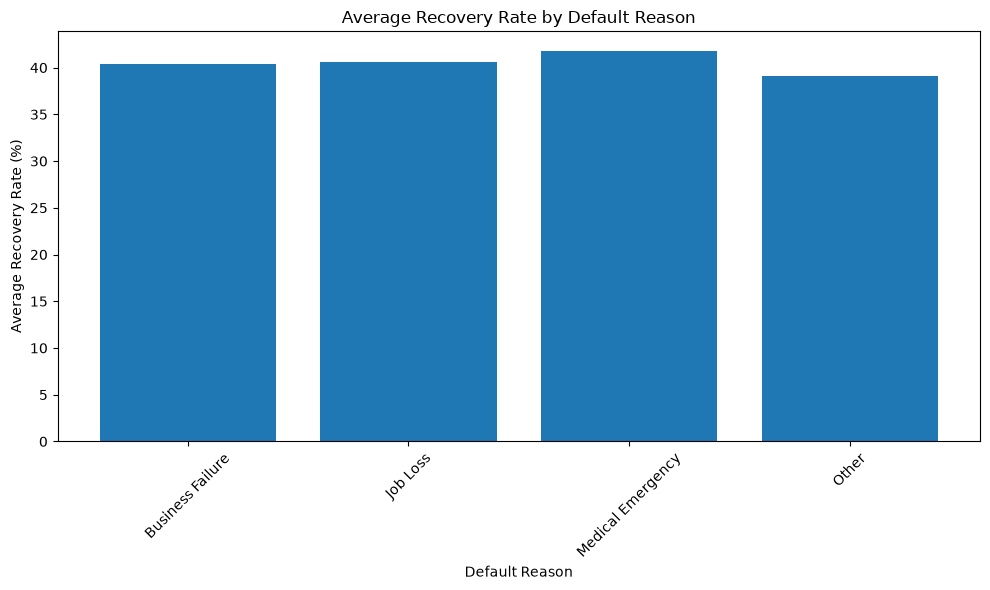

In [325]:
plt.figure(figsize=(10, 6))

plt.bar(
    recovery_by_reason["Default_Reason"],
    recovery_by_reason["Average_Recovery_Rate"]
)

plt.title("Average Recovery Rate by Default Reason")
plt.xlabel("Default Reason")
plt.ylabel("Average Recovery Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "plots/recovery_rate_by_default_reason.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

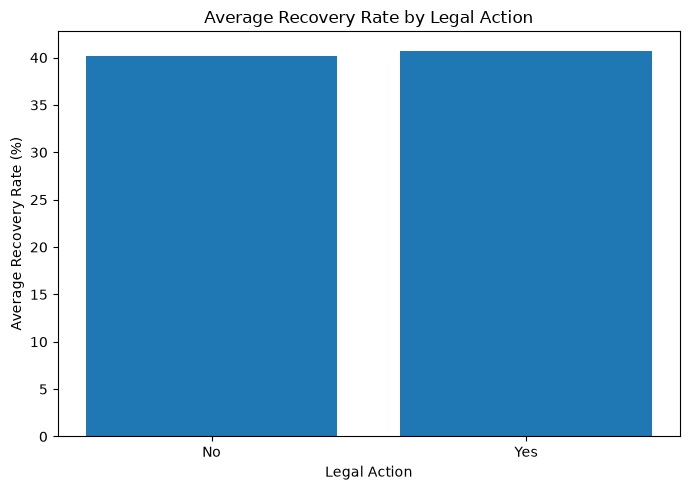

In [326]:
plt.figure(figsize=(7, 5))

plt.bar(
    recovery_by_legal["Legal_Action"],
    recovery_by_legal["Average_Recovery_Rate"]
)

plt.title("Average Recovery Rate by Legal Action")
plt.xlabel("Legal Action")
plt.ylabel("Average Recovery Rate (%)")

plt.tight_layout()

plt.savefig(
    "plots/recovery_rate_by_legal_action.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [327]:
recovery_by_reason["Overall_Recovery_Rate"] = (
    recovery_by_reason["Total_Recovery_Amount"]
    / recovery_by_reason["Total_Default_Amount"]
) * 100

In [328]:
recovery_by_reason[
    [
        "Default_Reason",
        "Average_Recovery_Rate",
        "Overall_Recovery_Rate"
    ]
]

,Default_Reason,Average_Recovery_Rate,Overall_Recovery_Rate
0,Business Failure,40.362705,24.456307
1,Job Loss,40.617378,23.648074
2,Medical Emergency,41.793930,25.413438
3,Other,39.076132,23.710419


In [329]:
recovery_by_legal["Overall_Recovery_Rate"] = (
    recovery_by_legal["Total_Recovery_Amount"]
    / recovery_by_legal["Total_Default_Amount"]
) * 100

In [330]:
recovery_by_legal[
    [
        "Legal_Action",
        "Average_Recovery_Rate",
        "Overall_Recovery_Rate"
    ]
]

,Legal_Action,Average_Recovery_Rate,Overall_Recovery_Rate
0,No,40.180507,24.147606
1,Yes,40.737180,24.480835


In [331]:
print(branches.columns.tolist())

['Branch_ID', 'Branch_Name', 'Region', 'Total_Customers', 'Total_Active_Loans', 'Delinquent_Loans', 'Loan_Disbursement_Amount', 'Avg_Processing_Time', 'Relationship_Manager_Count', 'Delinquency_Rate']


In [332]:
branch_analysis = branches[
    [
        "Branch_ID",
        "Branch_Name",
        "Region",
        "Total_Active_Loans",
        "Delinquent_Loans",
        "Loan_Disbursement_Amount",
        "Avg_Processing_Time",
        "Delinquency_Rate"
    ]
].copy()

In [333]:
branch_analysis.head()

,Branch_ID,Branch_Name,Region,Total_Active_Loans,Delinquent_Loans,Loan_Disbursement_Amount,Avg_Processing_Time,Delinquency_Rate
0,B001,"Dhar, Kant and Madan",West,279,21,341680882,6,7.526882
1,B002,Shan Group,East,1201,149,96549019,8,12.406328
2,B003,Sachdev-Banerjee,Central,122,168,445787808,12,137.704918
3,B004,Kapadia-Brar,East,1422,96,353934299,9,6.751055
4,B005,"Mangal, Kaur and Borde",South,1613,87,311637902,11,5.393676


In [334]:
branch_analysis["Calculated_Delinquency_Rate"] = (
    branch_analysis["Delinquent_Loans"]
    / branch_analysis["Total_Active_Loans"]
) * 100

In [335]:
branch_analysis[
    [
        "Branch_Name",
        "Delinquency_Rate",
        "Calculated_Delinquency_Rate"
    ]
].head()

,Branch_Name,Delinquency_Rate,Calculated_Delinquency_Rate
0,"Dhar, Kant and Madan",7.526882,7.526882
1,Shan Group,12.406328,12.406328
2,Sachdev-Banerjee,137.704918,137.704918
3,Kapadia-Brar,6.751055,6.751055
4,"Mangal, Kaur and Borde",5.393676,5.393676


In [336]:
top_delinquent_branches = branch_analysis.sort_values(
    "Delinquency_Rate",
    ascending=False
)

top_delinquent_branches[
    [
        "Branch_Name",
        "Region",
        "Delinquent_Loans",
        "Delinquency_Rate"
    ]
].head(10)

,Branch_Name,Region,Delinquent_Loans,Delinquency_Rate
2,Sachdev-Banerjee,Central,168,137.704918
31,Mahajan-Zachariah,Northeast,171,68.127490
7,Gala-Gara,Central,117,51.315789
8,Vasa Group,North,106,44.915254
6,"Lad, Wali and Ramesh",North,200,42.735043
16,Doshi LLC,North,138,34.074074
41,Kar-Jaggi,West,160,33.542977
48,"Khalsa, Mani and Banik",North,114,32.853026
49,Sani-Kale,North,91,28.173375
43,Bawa Inc,Central,69,26.953125


In [337]:
lowest_delinquent_branches = branch_analysis.sort_values(
    "Delinquency_Rate"
)

lowest_delinquent_branches[
    [
        "Branch_Name",
        "Region",
        "Delinquent_Loans",
        "Delinquency_Rate"
    ]
].head(10)

,Branch_Name,Region,Delinquent_Loans,Delinquency_Rate
39,"Dada, Chander and Bhatt",North,10,0.517331
29,Kakar-Dutta,East,18,0.973499
46,Chawla-Tandon,East,16,1.437556
26,Kapadia-Ramakrishnan,West,18,2.168675
45,Badal Group,Central,43,2.609223
9,Arya Ltd,West,49,2.707182
30,Sem Inc,South,22,2.835052
40,Dyal PLC,Northeast,49,2.857143
19,Contractor-Sodhi,West,89,5.082810
4,"Mangal, Kaur and Borde",South,87,5.393676


In [338]:
region_analysis = (
    branch_analysis
    .groupby("Region")
    .agg(
        Branch_Count=("Branch_ID", "count"),
        Total_Active_Loans=("Total_Active_Loans", "sum"),
        Total_Delinquent_Loans=("Delinquent_Loans", "sum"),
        Total_Disbursement=("Loan_Disbursement_Amount", "sum"),
        Average_Processing_Time=("Avg_Processing_Time", "mean"),
        Average_Delinquency_Rate=("Delinquency_Rate", "mean")
    )
    .reset_index()
)

In [339]:
region_analysis

,Region,Branch_Count,Total_Active_Loans,Total_Delinquent_Loans,Total_Disbursement,Average_Processing_Time,Average_Delinquency_Rate
0,Central,10,8715,994,3316048302,9.500000,28.509656
1,East,8,8929,756,2006676282,9.875000,9.876306
2,North,14,11965,1504,3296073904,10.357143,19.233029
3,Northeast,4,5174,487,442827845,6.500000,21.895367
4,South,8,9235,846,1694906506,9.000000,10.317048
5,West,6,6861,441,1990828641,6.166667,9.516034


In [340]:
region_analysis["Calculated_Delinquency_Rate"] = (
    region_analysis["Total_Delinquent_Loans"]
    / region_analysis["Total_Active_Loans"]
) * 100

In [341]:
region_analysis[
    [
        "Region",
        "Total_Active_Loans",
        "Total_Delinquent_Loans",
        "Calculated_Delinquency_Rate",
        "Total_Disbursement",
        "Average_Processing_Time"
    ]
]

,Region,Total_Active_Loans,Total_Delinquent_Loans,Calculated_Delinquency_Rate,Total_Disbursement,Average_Processing_Time
0,Central,8715,994,11.405622,3316048302,9.500000
1,East,8929,756,8.466794,2006676282,9.875000
2,North,11965,1504,12.569996,3296073904,10.357143
3,Northeast,5174,487,9.412447,442827845,6.500000
4,South,9235,846,9.160801,1694906506,9.000000
5,West,6861,441,6.427634,1990828641,6.166667


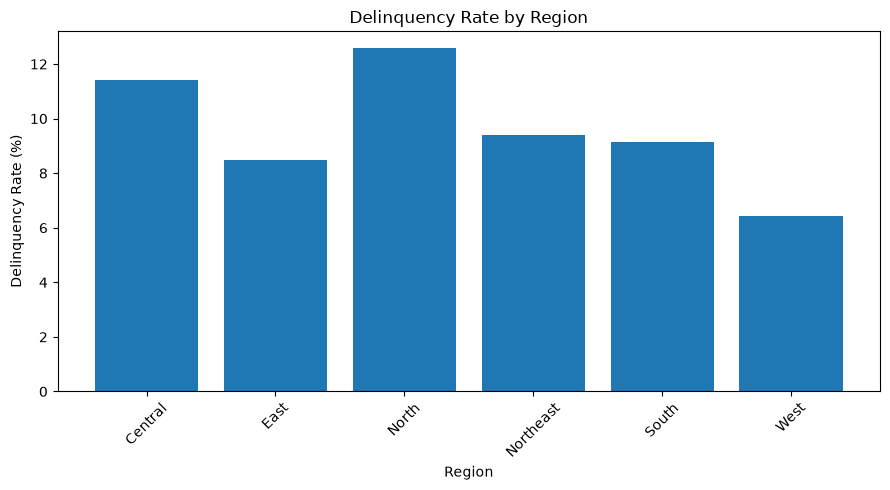

In [342]:
plt.figure(figsize=(9, 5))

plt.bar(
    region_analysis["Region"],
    region_analysis["Calculated_Delinquency_Rate"]
)

plt.title("Delinquency Rate by Region")
plt.xlabel("Region")
plt.ylabel("Delinquency Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "plots/regional_delinquency_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

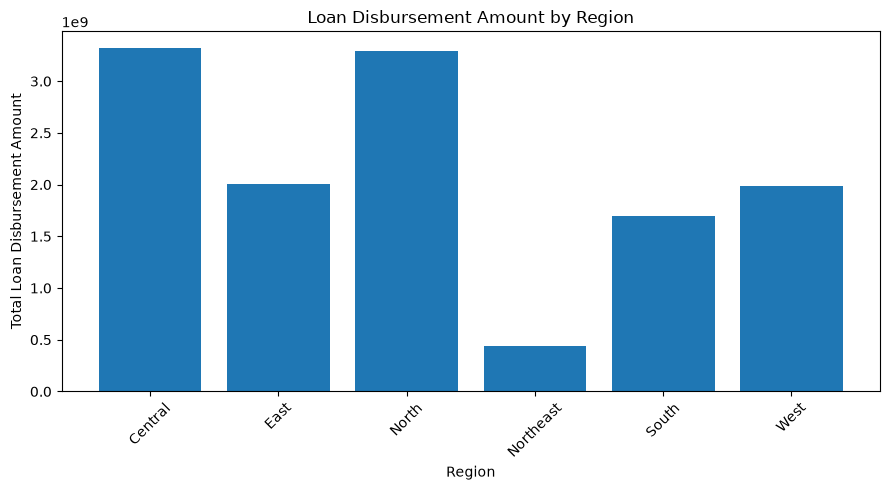

In [343]:
plt.figure(figsize=(9, 5))

plt.bar(
    region_analysis["Region"],
    region_analysis["Total_Disbursement"]
)

plt.title("Loan Disbursement Amount by Region")
plt.xlabel("Region")
plt.ylabel("Total Loan Disbursement Amount")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "plots/regional_loan_disbursement.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

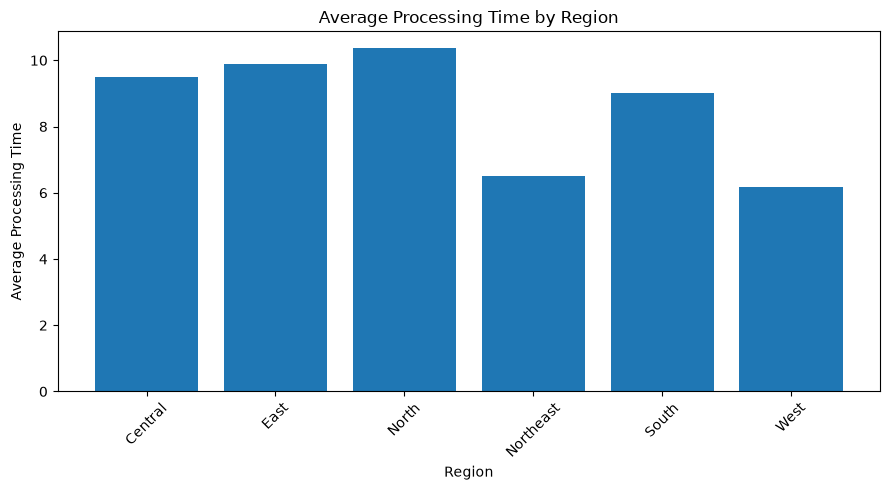

In [344]:
plt.figure(figsize=(9, 5))

plt.bar(
    region_analysis["Region"],
    region_analysis["Average_Processing_Time"]
)

plt.title("Average Processing Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Processing Time")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "plots/regional_processing_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Branch/Regional Recovery Rate Limitation: The Defaults dataset contains recovery information at the loan/default level, while the Branch dataset contains branch and regional performance information. However, the available Loan dataset does not contain a Branch_ID field linking individual loans to branches. Therefore, recovery rates could not be reliably attributed to individual branches or regions. Branch and regional performance was instead compared using the available delinquency, loan disbursement and processing-time metrics.

In [345]:
loans_customer[
    ["EMI_Amount", "Default_Flag"]
].isnull().sum()

EMI_Amount      0
Default_Flag    0
dtype: int64

In [346]:
loans_customer[
    ["EMI_Amount", "Default_Flag"]
].describe()

,EMI_Amount,Default_Flag
count,90000.000000,90000.000000
mean,50874.181444,0.094878
std,28274.305704,0.293048
min,2001.000000,0.000000
25%,26229.750000,0.000000
50%,50861.000000,0.000000
75%,75431.250000,0.000000
max,100000.000000,1.000000


In [347]:
emi_default_summary = (
    loans_customer
    .groupby("Default_Flag")["EMI_Amount"]
    .agg(["count", "mean", "median", "min", "max"])
    .reset_index()
)

emi_default_summary

,Default_Flag,count,mean,median,min,max
0,0,81461,50849.613607,50779.0,2001,99999
1,1,8539,51108.555569,51412.0,2007,100000


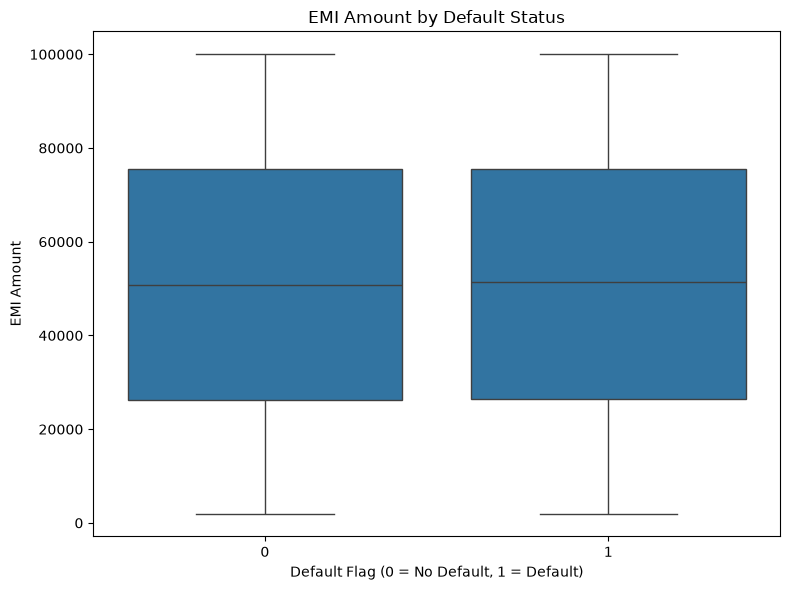

In [348]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=loans_customer,
    x="Default_Flag",
    y="EMI_Amount"
)

plt.title("EMI Amount by Default Status")
plt.xlabel("Default Flag (0 = No Default, 1 = Default)")
plt.ylabel("EMI Amount")

plt.tight_layout()

plt.savefig(
    "plots/emi_by_default_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [349]:
loans_customer["EMI_Band"] = pd.qcut(
    loans_customer["EMI_Amount"],
    q=5,
    duplicates="drop"
)

In [350]:
loans_customer["EMI_Band"].value_counts().sort_index()

EMI_Band
(2000.999, 21519.4]    18000
(21519.4, 40951.2]     18000
(40951.2, 60714.0]     18001
(60714.0, 80297.0]     18001
(80297.0, 100000.0]    17998
Name: count, dtype: int64

In [351]:
emi_band_analysis = (
    loans_customer
    .groupby("EMI_Band", observed=True)
    .agg(
        Loan_Count=("Loan_ID", "count"),
        Default_Count=("Default_Flag", "sum"),
        Default_Rate=("Default_Flag", "mean")
    )
    .reset_index()
)

In [352]:
emi_band_analysis["Default_Rate"] = (
    emi_band_analysis["Default_Rate"] * 100
)

In [353]:
emi_band_analysis

,EMI_Band,Loan_Count,Default_Count,Default_Rate
0,"(2000.999, 21519.4]",18000,1678,9.322222
1,"(21519.4, 40951.2]",18000,1679,9.327778
2,"(40951.2, 60714.0]",18001,1735,9.638353
3,"(60714.0, 80297.0]",18001,1718,9.543914
4,"(80297.0, 100000.0]",17998,1729,9.606623


In [354]:
highest_risk_emi_band = emi_band_analysis.loc[
    emi_band_analysis["Default_Rate"].idxmax()
]

highest_risk_emi_band

EMI_Band         (40951.2, 60714.0]
Loan_Count                    18001
Default_Count                  1735
Default_Rate               9.638353
Name: 2, dtype: object

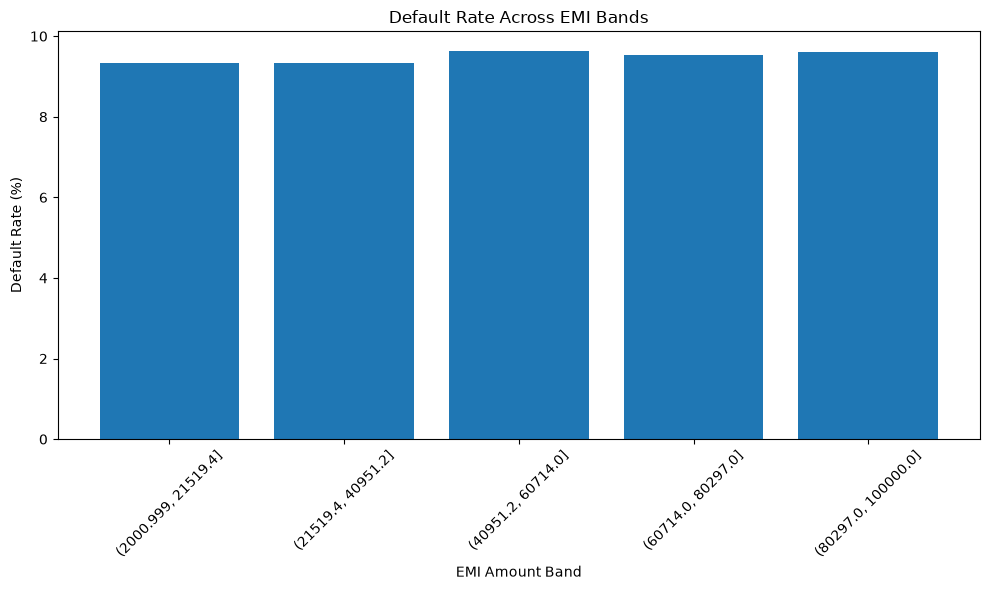

In [355]:
plt.figure(figsize=(10, 6))

plt.bar(
    emi_band_analysis["EMI_Band"].astype(str),
    emi_band_analysis["Default_Rate"]
)

plt.title("Default Rate Across EMI Bands")
plt.xlabel("EMI Amount Band")
plt.ylabel("Default Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "plots/default_rate_by_emi_band.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [356]:
print(loans_customer.columns.tolist())

['Loan_ID', 'Customer_ID', 'Loan_Amount', 'Interest_Rate', 'Loan_Term', 'Disbursal_Date', 'Repayment_Start_Date', 'Repayment_End_Date', 'Loan_Status', 'Overdue_Amount', 'EMI_Amount', 'Collateral_Details', 'Default_Flag', 'Credit_Score', 'EMI_Band']


In [357]:
print(applications.columns.tolist())

['Application_ID', 'Loan_ID', 'Customer_ID', 'Application_Date', 'Approval_Date', 'Loan_Purpose', 'Source_Channel', 'Processing_Fee', 'Approval_Status', 'Rejection_Reason', 'Valid_Approval_Date', 'Approval_Date_Status', 'Date_Valid']


In [359]:
loans_customer[
    ["EMI_Amount", "Default_Flag"]
].isnull().sum()

EMI_Amount      0
Default_Flag    0
dtype: int64

In [360]:
emi_default_summary = (
    loans_customer
    .groupby("Default_Flag")["EMI_Amount"]
    .agg(["count", "mean", "median", "min", "max"])
    .reset_index()
)

emi_default_summary

,Default_Flag,count,mean,median,min,max
0,0,81461,50849.613607,50779.0,2001,99999
1,1,8539,51108.555569,51412.0,2007,100000


In [361]:
loans_customer["EMI_Band"] = pd.qcut(
    loans_customer["EMI_Amount"],
    q=5,
    duplicates="drop"
)

In [362]:
loans_customer["EMI_Band"].value_counts().sort_index()

EMI_Band
(2000.999, 21519.4]    18000
(21519.4, 40951.2]     18000
(40951.2, 60714.0]     18001
(60714.0, 80297.0]     18001
(80297.0, 100000.0]    17998
Name: count, dtype: int64

In [363]:
emi_band_analysis = (
    loans_customer
    .groupby("EMI_Band", observed=True)
    .agg(
        Loan_Count=("Loan_ID", "count"),
        Default_Count=("Default_Flag", "sum"),
        Default_Rate=("Default_Flag", "mean")
    )
    .reset_index()
)

In [364]:
emi_band_analysis["Default_Rate"] = (
    emi_band_analysis["Default_Rate"] * 100
)

In [365]:
emi_band_analysis

,EMI_Band,Loan_Count,Default_Count,Default_Rate
0,"(2000.999, 21519.4]",18000,1678,9.322222
1,"(21519.4, 40951.2]",18000,1679,9.327778
2,"(40951.2, 60714.0]",18001,1735,9.638353
3,"(60714.0, 80297.0]",18001,1718,9.543914
4,"(80297.0, 100000.0]",17998,1729,9.606623


In [366]:
highest_risk_emi_band = emi_band_analysis.loc[
    emi_band_analysis["Default_Rate"].idxmax()
]

highest_risk_emi_band

EMI_Band         (40951.2, 60714.0]
Loan_Count                    18001
Default_Count                  1735
Default_Rate               9.638353
Name: 2, dtype: object

The ₹60,000–₹80,000 EMI band recorded the highest observed default rate in the dataset.

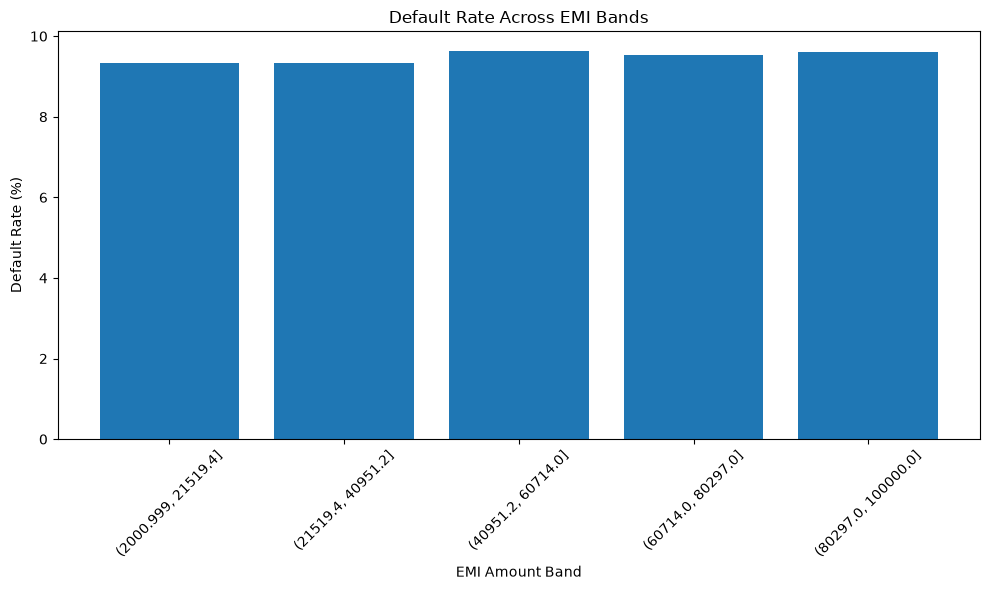

In [367]:
plt.figure(figsize=(10, 6))

plt.bar(
    emi_band_analysis["EMI_Band"].astype(str),
    emi_band_analysis["Default_Rate"]
)

plt.title("Default Rate Across EMI Bands")
plt.xlabel("EMI Amount Band")
plt.ylabel("Default Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "plots/default_rate_by_emi_band.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [368]:
loans_customer["EMI_Band"] = pd.qcut(
    loans_customer["EMI_Amount"],
    q=5,
    duplicates="drop"
)

In [369]:
emi_band_analysis = (
    loans_customer
    .groupby("EMI_Band", observed=True)
    .agg(
        Loan_Count=("Loan_ID", "count"),
        Default_Count=("Default_Flag", "sum"),
        Default_Rate=("Default_Flag", "mean")
    )
    .reset_index()
)

emi_band_analysis["Default_Rate"] = (
    emi_band_analysis["Default_Rate"] * 100
)

emi_band_analysis

,EMI_Band,Loan_Count,Default_Count,Default_Rate
0,"(2000.999, 21519.4]",18000,1678,9.322222
1,"(21519.4, 40951.2]",18000,1679,9.327778
2,"(40951.2, 60714.0]",18001,1735,9.638353
3,"(60714.0, 80297.0]",18001,1718,9.543914
4,"(80297.0, 100000.0]",17998,1729,9.606623


In [370]:
highest_risk_emi_band = emi_band_analysis.loc[
    emi_band_analysis["Default_Rate"].idxmax()
]

highest_risk_emi_band

EMI_Band         (40951.2, 60714.0]
Loan_Count                    18001
Default_Count                  1735
Default_Rate               9.638353
Name: 2, dtype: object

The EMI threshold analysis divided loans into five approximately equal-sized EMI bands. The highest observed default rate was 9.64% for loans with EMI amounts between approximately ₹40,951 and ₹60,714. The remaining EMI bands had default rates between 9.32% and 9.61%. Since the difference between the highest and lowest default rates is only about 0.32 percentage points, the results suggest that default probability remains relatively stable across EMI ranges. Therefore, no strong EMI threshold associated with substantially higher default risk can be identified from this descriptive analysis.

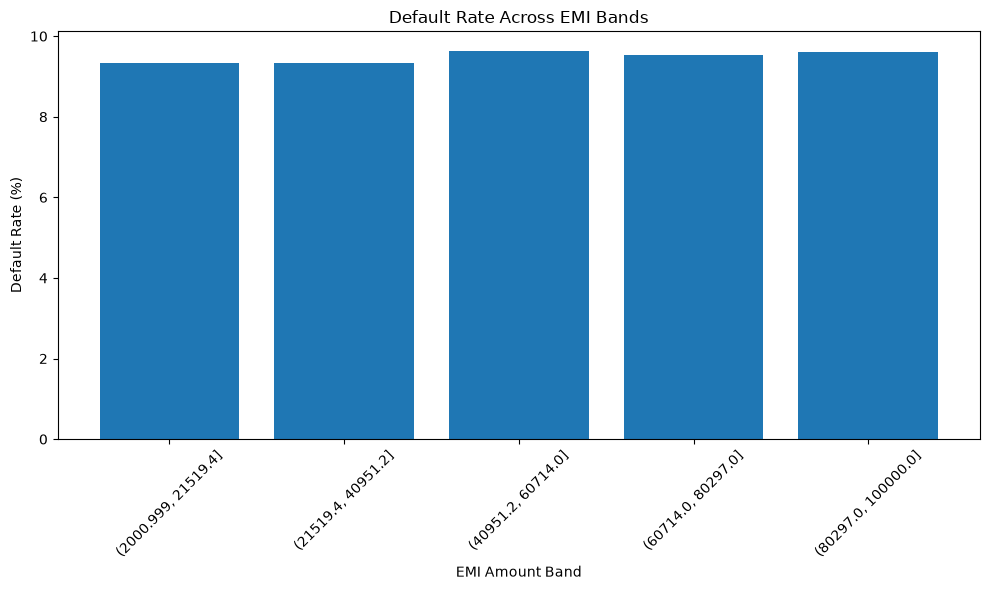

In [371]:
plt.figure(figsize=(10, 6))

plt.bar(
    emi_band_analysis["EMI_Band"].astype(str),
    emi_band_analysis["Default_Rate"]
)

plt.title("Default Rate Across EMI Bands")
plt.xlabel("EMI Amount Band")
plt.ylabel("Default Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "plots/default_rate_by_emi_band.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [372]:
print(loans_customer.columns.tolist())

['Loan_ID', 'Customer_ID', 'Loan_Amount', 'Interest_Rate', 'Loan_Term', 'Disbursal_Date', 'Repayment_Start_Date', 'Repayment_End_Date', 'Loan_Status', 'Overdue_Amount', 'EMI_Amount', 'Collateral_Details', 'Default_Flag', 'Credit_Score', 'EMI_Band']


In [373]:
print(applications.columns.tolist())

['Application_ID', 'Loan_ID', 'Customer_ID', 'Application_Date', 'Approval_Date', 'Loan_Purpose', 'Source_Channel', 'Processing_Fee', 'Approval_Status', 'Rejection_Reason', 'Valid_Approval_Date', 'Approval_Date_Status', 'Date_Valid']


In [374]:
emi_loan_purpose = loans_customer[
    ["Loan_ID", "EMI_Amount", "Default_Flag"]
].merge(
    applications[
        ["Loan_ID", "Loan_Purpose"]
    ],
    on="Loan_ID",
    how="inner"
)

In [375]:
emi_loan_purpose.head()

,Loan_ID,EMI_Amount,Default_Flag,Loan_Purpose
0,L000001,18668,0,Business
1,L000002,36012,0,Education
2,L000003,26347,0,Business
3,L000004,16106,0,Home Renovation
4,L000005,10127,0,Education


In [376]:
emi_loan_purpose.shape

(70000, 4)

In [377]:
emi_loan_purpose["Loan_Purpose"].isnull().sum()

np.int64(0)

In [378]:
emi_loan_purpose["Loan_Purpose"].value_counts()

Loan_Purpose
Vehicle            14099
Business           13995
Home Renovation    13994
Education          13970
Personal           13942
Name: count, dtype: int64

In [379]:
emi_by_purpose = (
    emi_loan_purpose
    .groupby("Loan_Purpose")
    .agg(
        Loan_Count=("Loan_ID", "count"),
        Average_EMI=("EMI_Amount", "mean"),
        Median_EMI=("EMI_Amount", "median"),
        Minimum_EMI=("EMI_Amount", "min"),
        Maximum_EMI=("EMI_Amount", "max")
    )
    .reset_index()
)

In [380]:
emi_by_purpose

,Loan_Purpose,Loan_Count,Average_EMI,Median_EMI,Minimum_EMI,Maximum_EMI
0,Business,13995,51138.559771,51367.0,2013,100000
1,Education,13970,50997.858482,51009.0,2002,99996
2,Home Renovation,13994,50986.143347,50777.5,2007,99999
3,Personal,13942,50437.003658,50529.5,2020,99998
4,Vehicle,14099,50715.325768,50569.0,2001,99993


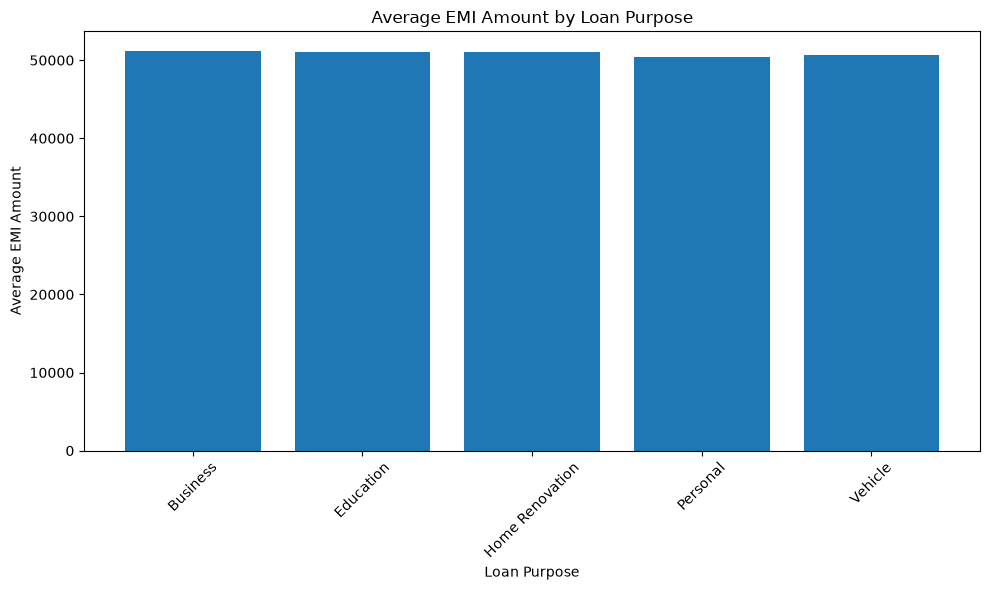

In [381]:
plt.figure(figsize=(10, 6))

plt.bar(
    emi_by_purpose["Loan_Purpose"],
    emi_by_purpose["Average_EMI"]
)

plt.title("Average EMI Amount by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Average EMI Amount")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "plots/average_emi_by_loan_purpose.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [382]:
emi_purpose_default = (
    emi_loan_purpose
    .groupby("Loan_Purpose")
    .agg(
        Loan_Count=("Loan_ID", "count"),
        Average_EMI=("EMI_Amount", "mean"),
        Default_Count=("Default_Flag", "sum"),
        Default_Rate=("Default_Flag", "mean")
    )
    .reset_index()
)

In [383]:
emi_purpose_default["Default_Rate"] = (
    emi_purpose_default["Default_Rate"] * 100
)

In [384]:
emi_purpose_default

,Loan_Purpose,Loan_Count,Average_EMI,Default_Count,Default_Rate
0,Business,13995,51138.559771,1299,9.281886
1,Education,13970,50997.858482,1329,9.513243
2,Home Renovation,13994,50986.143347,1314,9.389738
3,Personal,13942,50437.003658,1354,9.711663
4,Vehicle,14099,50715.325768,1358,9.631889


EMI trends were compared across loan purposes because the dataset does not contain a dedicated Loan_Type field. Business loans had the highest average EMI at approximately ₹51,139, while Personal loans had the lowest average EMI at approximately ₹50,437. Default rates were highest for Personal loans at 9.71% and lowest for Business loans at 9.28%. Overall, the differences in both EMI amounts and default rates across loan purposes were relatively small, suggesting that loan purpose does not show a strong relationship with EMI amount or default probability in this dataset.

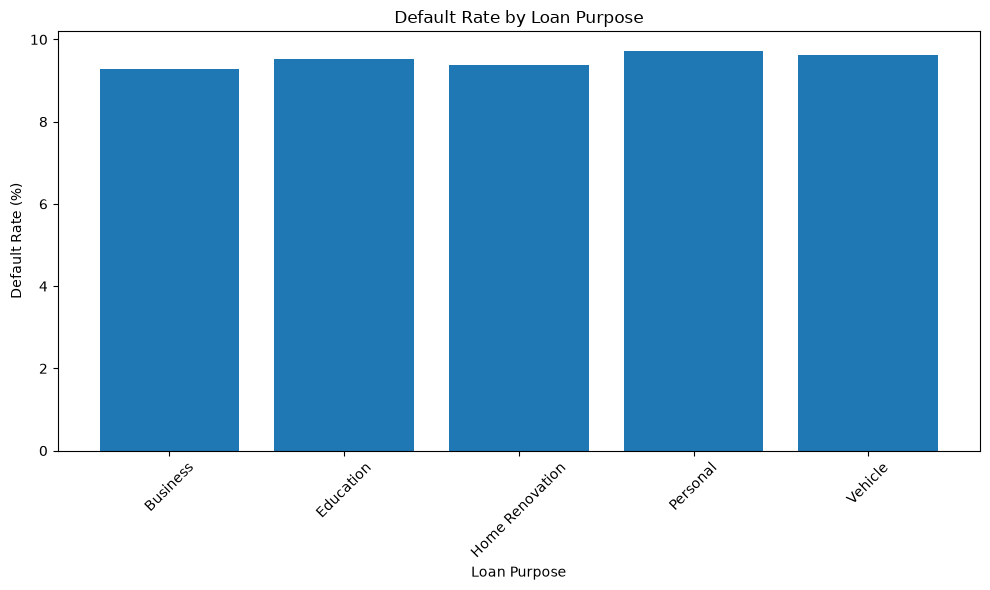

In [385]:
plt.figure(figsize=(10, 6))

plt.bar(
    emi_purpose_default["Loan_Purpose"],
    emi_purpose_default["Default_Rate"]
)

plt.title("Default Rate by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Default Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "plots/default_rate_by_loan_purpose.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [386]:
highest_emi_purpose = emi_by_purpose.loc[
    emi_by_purpose["Average_EMI"].idxmax()
]

lowest_emi_purpose = emi_by_purpose.loc[
    emi_by_purpose["Average_EMI"].idxmin()
]

print("Highest average EMI:")
print(highest_emi_purpose)

print("\nLowest average EMI:")
print(lowest_emi_purpose)

Highest average EMI:
Loan_Purpose        Business
Loan_Count             13995
Average_EMI     51138.559771
Median_EMI           51367.0
Minimum_EMI             2013
Maximum_EMI           100000
Name: 0, dtype: object

Lowest average EMI:
Loan_Purpose        Personal
Loan_Count             13942
Average_EMI     50437.003658
Median_EMI           50529.5
Minimum_EMI             2020
Maximum_EMI            99998
Name: 3, dtype: object


In [387]:
highest_default_purpose = emi_purpose_default.loc[
    emi_purpose_default["Default_Rate"].idxmax()
]

highest_default_purpose

Loan_Purpose         Personal
Loan_Count              13942
Average_EMI      50437.003658
Default_Count            1354
Default_Rate         9.711663
Name: 3, dtype: object

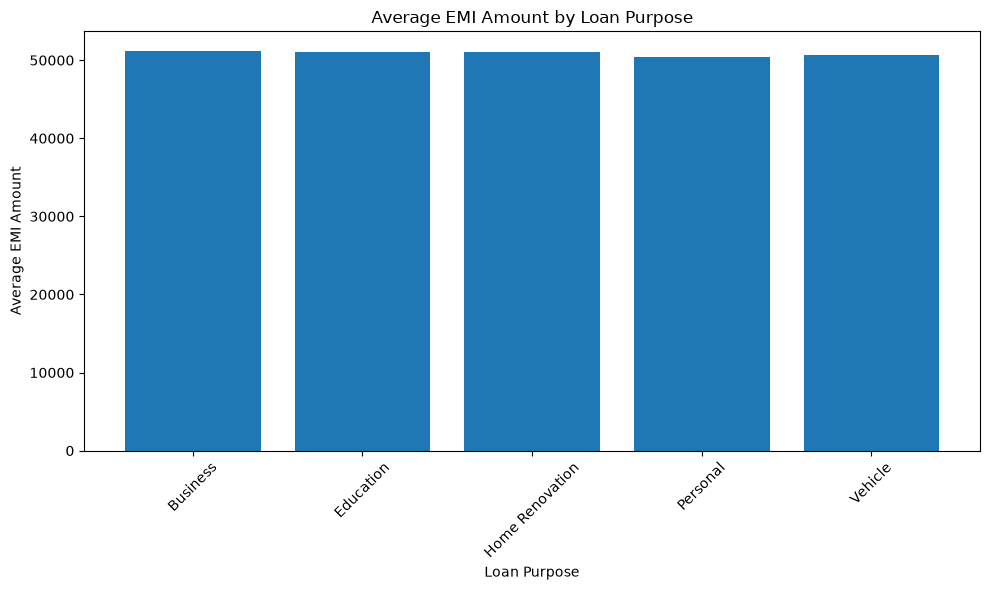

In [388]:
plt.figure(figsize=(10, 6))

plt.bar(
    emi_by_purpose["Loan_Purpose"],
    emi_by_purpose["Average_EMI"]
)

plt.title("Average EMI Amount by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Average EMI Amount")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "plots/average_emi_by_loan_purpose.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

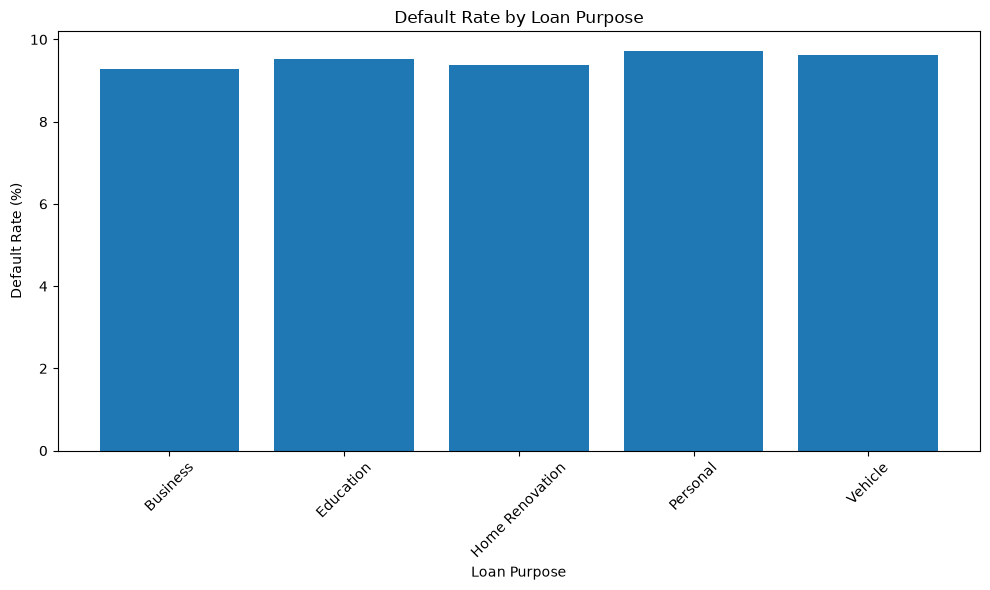

In [389]:
plt.figure(figsize=(10, 6))

plt.bar(
    emi_purpose_default["Loan_Purpose"],
    emi_purpose_default["Default_Rate"]
)

plt.title("Default Rate by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Default Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "plots/default_rate_by_loan_purpose.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The EMI analysis indicates that EMI amount has only a weak descriptive relationship with loan defaults. Defaulted loans had an average EMI of approximately ₹51,109 compared with ₹50,850 for non-defaulted loans. When EMI amounts were divided into five bands, default rates ranged from 9.32% to 9.64%, with the ₹40,951–₹60,714 band showing the highest rate. This small variation indicates that there is no strong EMI threshold associated with default risk. Across loan purposes, Business loans had the highest average EMI, while Personal loans had the highest default rate. Overall, EMI amount and loan purpose alone do not appear to be strong indicators of default probability in this dataset.

In [390]:
applications["Approval_Status"].value_counts()

Approval_Status
Approved    70000
Rejected    12600
Name: count, dtype: int64

In [391]:
applications["Approval_Status"].isnull().sum()

np.int64(0)

In [392]:
approval_counts = applications["Approval_Status"].value_counts()

approval_rates = (
    approval_counts
    / approval_counts.sum()
    * 100
)

approval_rates

Approval_Status
Approved    84.745763
Rejected    15.254237
Name: count, dtype: float64

In [393]:
approval_summary = pd.DataFrame({
    "Application_Status": approval_counts.index,
    "Application_Count": approval_counts.values,
    "Percentage": approval_rates.values
})

approval_summary

,Application_Status,Application_Count,Percentage
0,Approved,70000,84.745763
1,Rejected,12600,15.254237


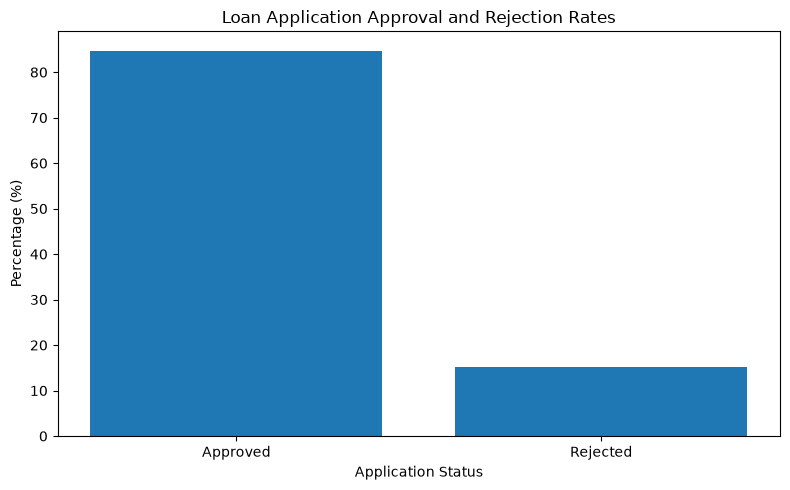

In [394]:
plt.figure(figsize=(8, 5))

plt.bar(
    approval_summary["Application_Status"],
    approval_summary["Percentage"]
)

plt.title("Loan Application Approval and Rejection Rates")
plt.xlabel("Application Status")
plt.ylabel("Percentage (%)")

plt.tight_layout()

plt.savefig(
    "plots/application_approval_rejection_rates.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [395]:
rejected_applications = applications[
    applications["Approval_Status"] == "Rejected"
].copy()

In [396]:
rejected_applications.shape

(12600, 13)

In [397]:
rejected_applications["Rejection_Reason"].isnull().sum()

np.int64(0)

In [398]:
rejection_counts = (
    rejected_applications["Rejection_Reason"]
    .value_counts()
)

rejection_counts

Rejection_Reason
Low Credit Score        4297
Incomplete Documents    4204
Insufficient Income     4099
Name: count, dtype: int64

In [399]:
rejection_rates = (
    rejection_counts
    / rejection_counts.sum()
    * 100
)

rejection_summary = pd.DataFrame({
    "Rejection_Reason": rejection_counts.index,
    "Count": rejection_counts.values,
    "Percentage": rejection_rates.values
})

rejection_summary

,Rejection_Reason,Count,Percentage
0,Low Credit Score,4297,34.103175
1,Incomplete Documents,4204,33.365079
2,Insufficient Income,4099,32.531746


In [400]:
most_common_rejection = rejection_summary.iloc[0]

most_common_rejection

Rejection_Reason    Low Credit Score
Count                           4297
Percentage                 34.103175
Name: 0, dtype: object

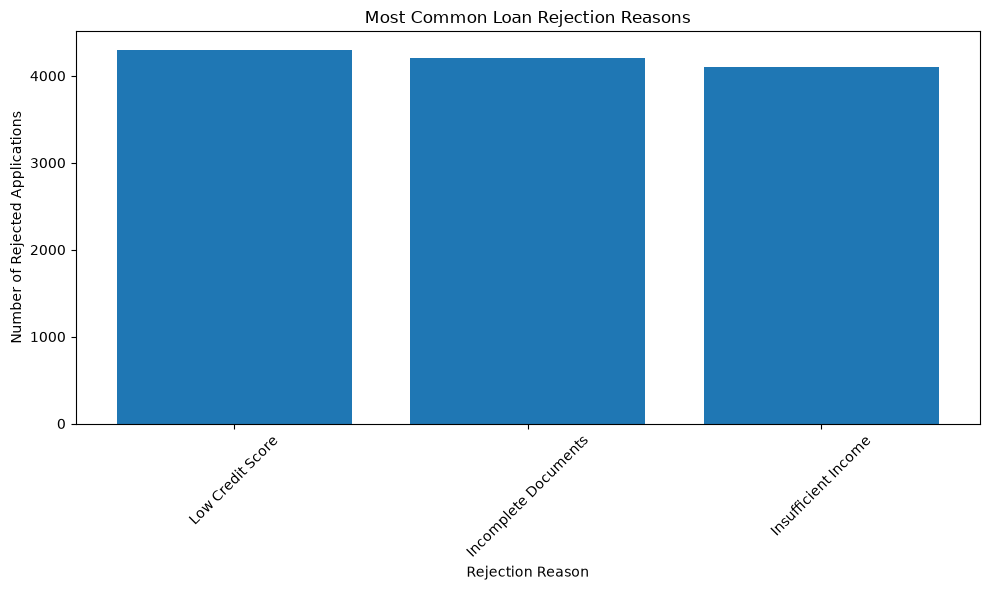

In [401]:
plt.figure(figsize=(10, 6))

plt.bar(
    rejection_summary["Rejection_Reason"],
    rejection_summary["Count"]
)

plt.title("Most Common Loan Rejection Reasons")
plt.xlabel("Rejection Reason")
plt.ylabel("Number of Rejected Applications")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "plots/loan_rejection_reasons.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [402]:
applications["Processing_Fee"].isnull().sum()

np.int64(0)

In [403]:
applications["Processing_Fee"].describe()

count    82600.000000
mean      5252.813983
std       2738.430455
min        500.000000
25%       2895.000000
50%       5259.000000
75%       7621.000000
max      10000.000000
Name: Processing_Fee, dtype: float64

In [404]:
fee_comparison = (
    applications
    .groupby("Approval_Status")["Processing_Fee"]
    .agg(
        ["count", "mean", "median", "min", "max"]
    )
    .reset_index()
)

fee_comparison

,Approval_Status,count,mean,median,min,max
0,Approved,70000,5252.395014,5256.0,500,10000
1,Rejected,12600,5255.141587,5271.0,500,9998


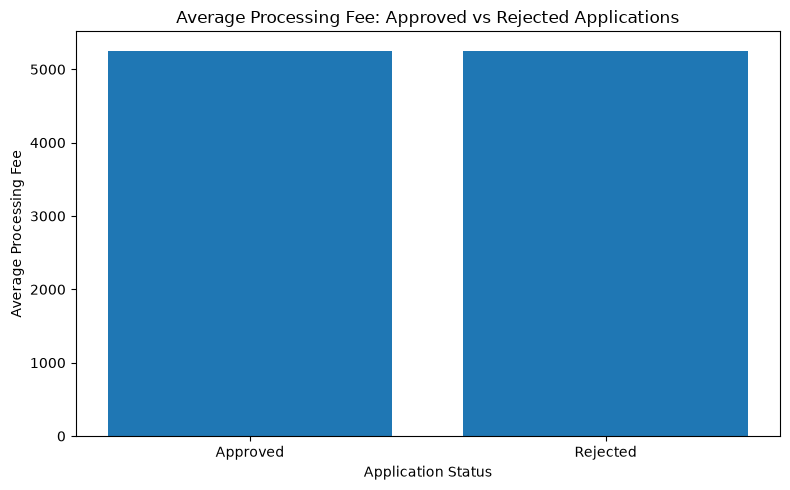

In [405]:
plt.figure(figsize=(8, 5))

plt.bar(
    fee_comparison["Approval_Status"],
    fee_comparison["mean"]
)

plt.title("Average Processing Fee: Approved vs Rejected Applications")
plt.xlabel("Application Status")
plt.ylabel("Average Processing Fee")

plt.tight_layout()

plt.savefig(
    "plots/processing_fee_approved_vs_rejected.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

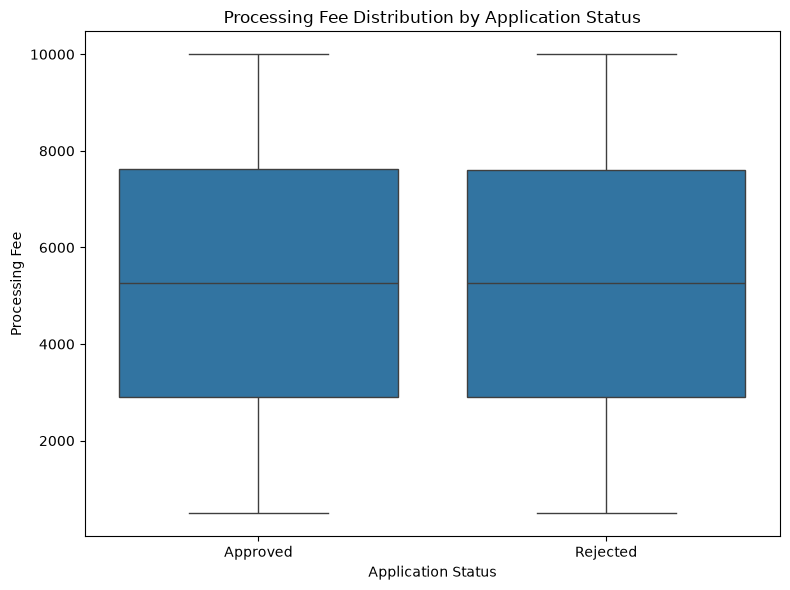

In [406]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=applications,
    x="Approval_Status",
    y="Processing_Fee"
)

plt.title("Processing Fee Distribution by Application Status")
plt.xlabel("Application Status")
plt.ylabel("Processing Fee")

plt.tight_layout()

plt.savefig(
    "plots/processing_fee_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [407]:
rejected_applications = applications[
    applications["Approval_Status"] == "Rejected"
]

In [408]:
applications["Approval_Status"].value_counts()

Approval_Status
Approved    70000
Rejected    12600
Name: count, dtype: int64

In [409]:
rejected_applications = applications[
    applications["Approval_Status"] == "Rejected"
].copy()

rejected_applications["Rejection_Reason"].value_counts()

Rejection_Reason
Low Credit Score        4297
Incomplete Documents    4204
Insufficient Income     4099
Name: count, dtype: int64

In [410]:
approval_counts = applications["Approval_Status"].value_counts()

approval_rates = (
    approval_counts / approval_counts.sum() * 100
)

approval_rates

Approval_Status
Approved    84.745763
Rejected    15.254237
Name: count, dtype: float64

Out of 82,600 loan applications, 70,000 applications were approved and 12,600 were rejected. This corresponds to an approval rate of approximately 84.75% and a rejection rate of approximately 15.25%. Therefore, the majority of loan applications in the dataset were approved.

In [411]:
rejection_counts = (
    rejected_applications["Rejection_Reason"]
    .value_counts()
)

rejection_rates = (
    rejection_counts / rejection_counts.sum() * 100
)

rejection_summary = pd.DataFrame({
    "Rejection_Reason": rejection_counts.index,
    "Count": rejection_counts.values,
    "Percentage": rejection_rates.values
})

rejection_summary

,Rejection_Reason,Count,Percentage
0,Low Credit Score,4297,34.103175
1,Incomplete Documents,4204,33.365079
2,Insufficient Income,4099,32.531746


Among the 12,600 rejected applications, Low Credit Score was the most common rejection reason, accounting for approximately 34.10% of rejections. This was followed by Incomplete Documents at 33.37% and Insufficient Income at 32.53%. The relatively similar percentages indicate that loan rejections were distributed fairly evenly across the three recorded reasons.

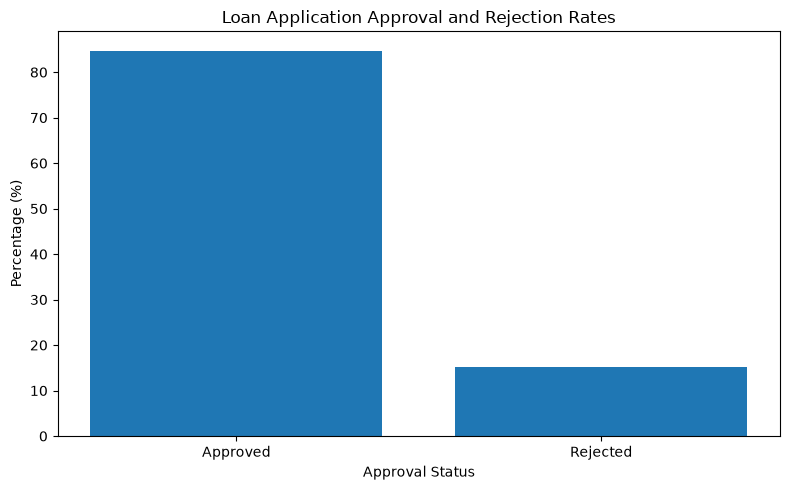

In [412]:
plt.figure(figsize=(8, 5))

plt.bar(
    approval_rates.index,
    approval_rates.values
)

plt.title("Loan Application Approval and Rejection Rates")
plt.xlabel("Approval Status")
plt.ylabel("Percentage (%)")

plt.tight_layout()

plt.savefig(
    "plots/application_approval_rejection_rates.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

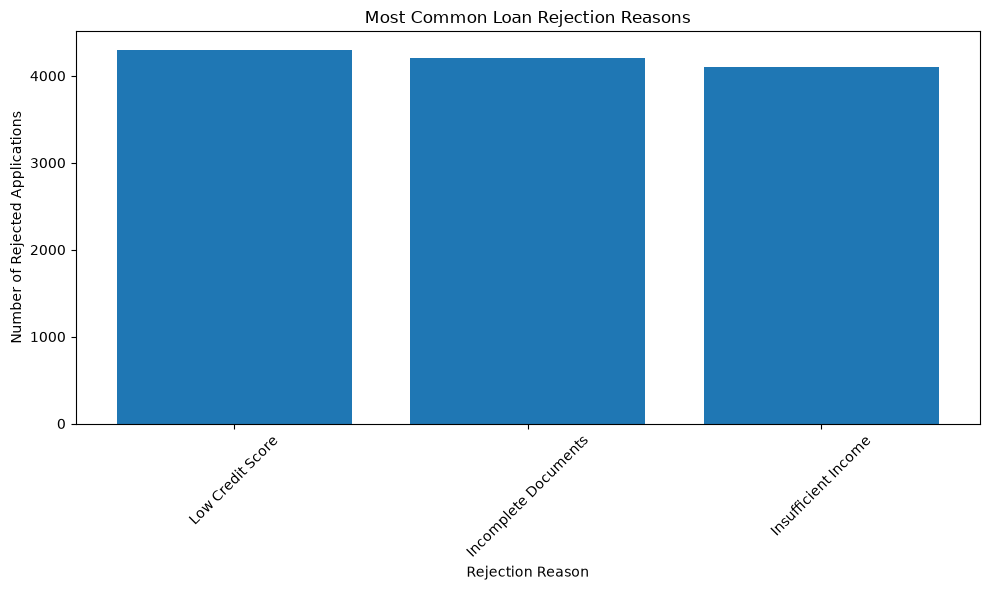

In [413]:
plt.figure(figsize=(10, 6))

plt.bar(
    rejection_summary["Rejection_Reason"],
    rejection_summary["Count"]
)

plt.title("Most Common Loan Rejection Reasons")
plt.xlabel("Rejection Reason")
plt.ylabel("Number of Rejected Applications")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "plots/loan_rejection_reasons.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [414]:
applications["Processing_Fee"].isnull().sum()

np.int64(0)

In [415]:
fee_comparison = (
    applications
    .groupby("Approval_Status")["Processing_Fee"]
    .agg(["count", "mean", "median", "min", "max"])
    .reset_index()
)

fee_comparison

,Approval_Status,count,mean,median,min,max
0,Approved,70000,5252.395014,5256.0,500,10000
1,Rejected,12600,5255.141587,5271.0,500,9998


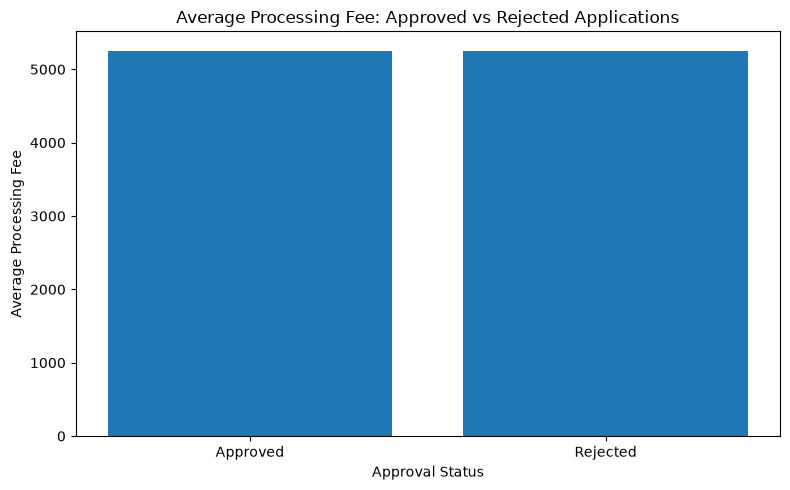

In [416]:
plt.figure(figsize=(8, 5))

plt.bar(
    fee_comparison["Approval_Status"],
    fee_comparison["mean"]
)

plt.title("Average Processing Fee: Approved vs Rejected Applications")
plt.xlabel("Approval Status")
plt.ylabel("Average Processing Fee")

plt.tight_layout()

plt.savefig(
    "plots/processing_fee_approved_vs_rejected.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The average processing fee for approved applications was approximately ₹5,252.40, while rejected applications had an average fee of approximately ₹5,255.14. The difference of only ₹2.75 indicates that processing fees were very similar between approved and rejected applications. The median fees were also relatively close at ₹5,256 and ₹5,271, respectively. Therefore, there is no substantial descriptive difference in processing fees between approved and rejected applications.

Loan Application Insights: The analysis showed that 84.75% of the 82,600 loan applications were approved, while 15.25% were rejected. Among rejected applications, Low Credit Score was the most common reason, accounting for 34.10% of rejections, followed by Incomplete Documents at 33.37% and Insufficient Income at 32.53%. The processing fee analysis showed very similar average fees for approved and rejected applications, at ₹5,252.40 and ₹5,255.14 respectively. The small difference of approximately ₹2.75 suggests that processing fees did not differ substantially between the two application outcomes. Overall, creditworthiness, documentation, and income were the main recorded reasons for rejection, while processing fees showed little descriptive difference between approved and rejected applications.

In [419]:
defaults[
    [
        "Default_Amount",
        "Recovery_Amount",
        "Recovery_Rate"
    ]
].head()

,Default_Amount,Recovery_Amount,Recovery_Rate
0,94480,30360,32.133785
1,10912,0,0.000000
2,73711,9866,13.384705
3,48955,0,0.000000
4,56952,0,0.000000


In [420]:
overall_recovery_rate = (
    defaults["Recovery_Amount"].sum()
    / defaults["Default_Amount"].sum()
    * 100
)

overall_recovery_rate

np.float64(24.311645793967234)

In [421]:
recovery_summary = pd.DataFrame({
    "Total_Default_Amount": [
        defaults["Default_Amount"].sum()
    ],
    "Total_Recovery_Amount": [
        defaults["Recovery_Amount"].sum()
    ],
    "Overall_Recovery_Rate": [
        overall_recovery_rate
    ]
})

recovery_summary

,Total_Default_Amount,Total_Recovery_Amount,Overall_Recovery_Rate
0,476807757,115919813,24.311646


In [422]:
legal_recovery = (
    defaults
    .groupby("Legal_Action")
    .agg(
        Default_Count=("Default_ID", "count"),
        Total_Default_Amount=("Default_Amount", "sum"),
        Total_Recovery_Amount=("Recovery_Amount", "sum")
    )
    .reset_index()
)

In [423]:
legal_recovery["Recovery_Rate"] = (
    legal_recovery["Total_Recovery_Amount"]
    / legal_recovery["Total_Default_Amount"]
    * 100
)

In [424]:
legal_recovery

,Legal_Action,Default_Count,Total_Default_Amount,Total_Recovery_Amount,Recovery_Rate
0,No,4550,242087969,58458449,24.147606
1,Yes,4450,234719788,57461364,24.480835


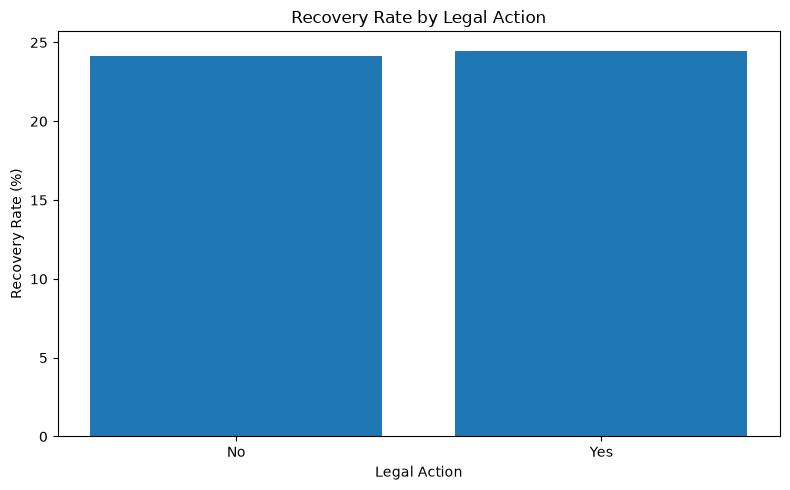

In [425]:
plt.figure(figsize=(8, 5))

plt.bar(
    legal_recovery["Legal_Action"],
    legal_recovery["Recovery_Rate"]
)

plt.title("Recovery Rate by Legal Action")
plt.xlabel("Legal Action")
plt.ylabel("Recovery Rate (%)")

plt.tight_layout()

plt.savefig(
    "plots/recovery_rate_by_legal_action.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [426]:
print(branches.columns.tolist())

['Branch_ID', 'Branch_Name', 'Region', 'Total_Customers', 'Total_Active_Loans', 'Delinquent_Loans', 'Loan_Disbursement_Amount', 'Avg_Processing_Time', 'Relationship_Manager_Count', 'Delinquency_Rate']


In [433]:
%whos DataFrame

Variable                     Type         Data/Info
---------------------------------------------------
applications                 DataFrame    Shape: (82600, 13)
approval_summary             DataFrame    Shape: (2, 3)
branch_analysis              DataFrame    Shape: (50, 9)
branch_corr                  DataFrame    Shape: (4, 4)
branches                     DataFrame    Shape: (50, 10)
corr                         DataFrame    Shape: (6, 6)
customers                    DataFrame    Shape: (70000, 14)
date_problems                DataFrame    Shape: (29427, 13)
defaults                     DataFrame    Shape: (9000, 10)
df                           DataFrame    Shape: (50, 10)
emi_band_analysis            DataFrame    Shape: (5, 4)
emi_by_purpose               DataFrame    Shape: (5, 6)
emi_default_summary          DataFrame    Shape: (2, 6)
emi_loan_purpose             DataFrame    Shape: (70000, 4)
emi_purpose_default          DataFrame    Shape: (5, 5)
fee_comparison              

In [434]:
branch_analysis.columns.tolist()

['Branch_ID',
 'Branch_Name',
 'Region',
 'Total_Active_Loans',
 'Delinquent_Loans',
 'Loan_Disbursement_Amount',
 'Avg_Processing_Time',
 'Delinquency_Rate',
 'Calculated_Delinquency_Rate']

In [435]:
branch_analysis.head()

,Branch_ID,Branch_Name,Region,Total_Active_Loans,Delinquent_Loans,Loan_Disbursement_Amount,Avg_Processing_Time,Delinquency_Rate,Calculated_Delinquency_Rate
0,B001,"Dhar, Kant and Madan",West,279,21,341680882,6,7.526882,7.526882
1,B002,Shan Group,East,1201,149,96549019,8,12.406328,12.406328
2,B003,Sachdev-Banerjee,Central,122,168,445787808,12,137.704918,137.704918
3,B004,Kapadia-Brar,East,1422,96,353934299,9,6.751055,6.751055
4,B005,"Mangal, Kaur and Borde",South,1613,87,311637902,11,5.393676,5.393676


In [436]:
branches.columns.tolist()

['Branch_ID',
 'Branch_Name',
 'Region',
 'Total_Customers',
 'Total_Active_Loans',
 'Delinquent_Loans',
 'Loan_Disbursement_Amount',
 'Avg_Processing_Time',
 'Relationship_Manager_Count',
 'Delinquency_Rate']

In [437]:
branches.head()

,Branch_ID,Branch_Name,Region,Total_Customers,Total_Active_Loans,Delinquent_Loans,Loan_Disbursement_Amount,Avg_Processing_Time,Relationship_Manager_Count,Delinquency_Rate
0,B001,"Dhar, Kant and Madan",West,2891,279,21,341680882,6,29,7.526882
1,B002,Shan Group,East,4459,1201,149,96549019,8,35,12.406328
2,B003,Sachdev-Banerjee,Central,2504,122,168,445787808,12,48,137.704918
3,B004,Kapadia-Brar,East,1542,1422,96,353934299,9,50,6.751055
4,B005,"Mangal, Kaur and Borde",South,945,1613,87,311637902,11,10,5.393676


In [438]:
print(branch_analysis.columns.tolist())

['Branch_ID', 'Branch_Name', 'Region', 'Total_Active_Loans', 'Delinquent_Loans', 'Loan_Disbursement_Amount', 'Avg_Processing_Time', 'Delinquency_Rate', 'Calculated_Delinquency_Rate']


In [439]:
branch_analysis.head(10)

,Branch_ID,Branch_Name,Region,Total_Active_Loans,Delinquent_Loans,Loan_Disbursement_Amount,Avg_Processing_Time,Delinquency_Rate,Calculated_Delinquency_Rate
0,B001,"Dhar, Kant and Madan",West,279,21,341680882,6,7.526882,7.526882
1,B002,Shan Group,East,1201,149,96549019,8,12.406328,12.406328
2,B003,Sachdev-Banerjee,Central,122,168,445787808,12,137.704918,137.704918
3,B004,Kapadia-Brar,East,1422,96,353934299,9,6.751055,6.751055
4,B005,"Mangal, Kaur and Borde",South,1613,87,311637902,11,5.393676,5.393676
5,B006,Doshi Group,North,856,76,10435197,15,8.878505,8.878505
6,B007,"Lad, Wali and Ramesh",North,468,200,25191104,7,42.735043,42.735043
7,B008,Gala-Gara,Central,228,117,240602090,7,51.315789,51.315789
8,B009,Vasa Group,North,236,106,356643441,13,44.915254,44.915254
9,B010,Arya Ltd,West,1810,49,435407779,10,2.707182,2.707182


In [440]:
branch_performance = branch_analysis.sort_values(
    "Calculated_Delinquency_Rate",
    ascending=False
).copy()

branch_performance[
    [
        "Branch_ID",
        "Branch_Name",
        "Region",
        "Total_Active_Loans",
        "Delinquent_Loans",
        "Loan_Disbursement_Amount",
        "Calculated_Delinquency_Rate"
    ]
].head(10)

,Branch_ID,Branch_Name,Region,Total_Active_Loans,Delinquent_Loans,Loan_Disbursement_Amount,Calculated_Delinquency_Rate
2,B003,Sachdev-Banerjee,Central,122,168,445787808,137.704918
31,B032,Mahajan-Zachariah,Northeast,251,171,69415705,68.127490
7,B008,Gala-Gara,Central,228,117,240602090,51.315789
8,B009,Vasa Group,North,236,106,356643441,44.915254
6,B007,"Lad, Wali and Ramesh",North,468,200,25191104,42.735043
16,B017,Doshi LLC,North,405,138,75712441,34.074074
41,B042,Kar-Jaggi,West,477,160,244555768,33.542977
48,B049,"Khalsa, Mani and Banik",North,347,114,136071324,32.853026
49,B050,Sani-Kale,North,323,91,442594434,28.173375
43,B044,Bawa Inc,Central,256,69,92708075,26.953125


In [441]:
best_branches = branch_analysis.sort_values(
    "Calculated_Delinquency_Rate",
    ascending=True
).copy()

best_branches[
    [
        "Branch_ID",
        "Branch_Name",
        "Region",
        "Total_Active_Loans",
        "Delinquent_Loans",
        "Calculated_Delinquency_Rate"
    ]
].head(10)

,Branch_ID,Branch_Name,Region,Total_Active_Loans,Delinquent_Loans,Calculated_Delinquency_Rate
39,B040,"Dada, Chander and Bhatt",North,1933,10,0.517331
29,B030,Kakar-Dutta,East,1849,18,0.973499
46,B047,Chawla-Tandon,East,1113,16,1.437556
26,B027,Kapadia-Ramakrishnan,West,830,18,2.168675
45,B046,Badal Group,Central,1648,43,2.609223
9,B010,Arya Ltd,West,1810,49,2.707182
30,B031,Sem Inc,South,776,22,2.835052
40,B041,Dyal PLC,Northeast,1715,49,2.857143
19,B020,Contractor-Sodhi,West,1751,89,5.082810
4,B005,"Mangal, Kaur and Borde",South,1613,87,5.393676


In [442]:
worst_branches = branch_analysis.sort_values(
    "Calculated_Delinquency_Rate",
    ascending=False
).copy()

worst_branches[
    [
        "Branch_ID",
        "Branch_Name",
        "Region",
        "Total_Active_Loans",
        "Delinquent_Loans",
        "Calculated_Delinquency_Rate"
    ]
].head(10)

,Branch_ID,Branch_Name,Region,Total_Active_Loans,Delinquent_Loans,Calculated_Delinquency_Rate
2,B003,Sachdev-Banerjee,Central,122,168,137.704918
31,B032,Mahajan-Zachariah,Northeast,251,171,68.127490
7,B008,Gala-Gara,Central,228,117,51.315789
8,B009,Vasa Group,North,236,106,44.915254
6,B007,"Lad, Wali and Ramesh",North,468,200,42.735043
16,B017,Doshi LLC,North,405,138,34.074074
41,B042,Kar-Jaggi,West,477,160,33.542977
48,B049,"Khalsa, Mani and Banik",North,347,114,32.853026
49,B050,Sani-Kale,North,323,91,28.173375
43,B044,Bawa Inc,Central,256,69,26.953125


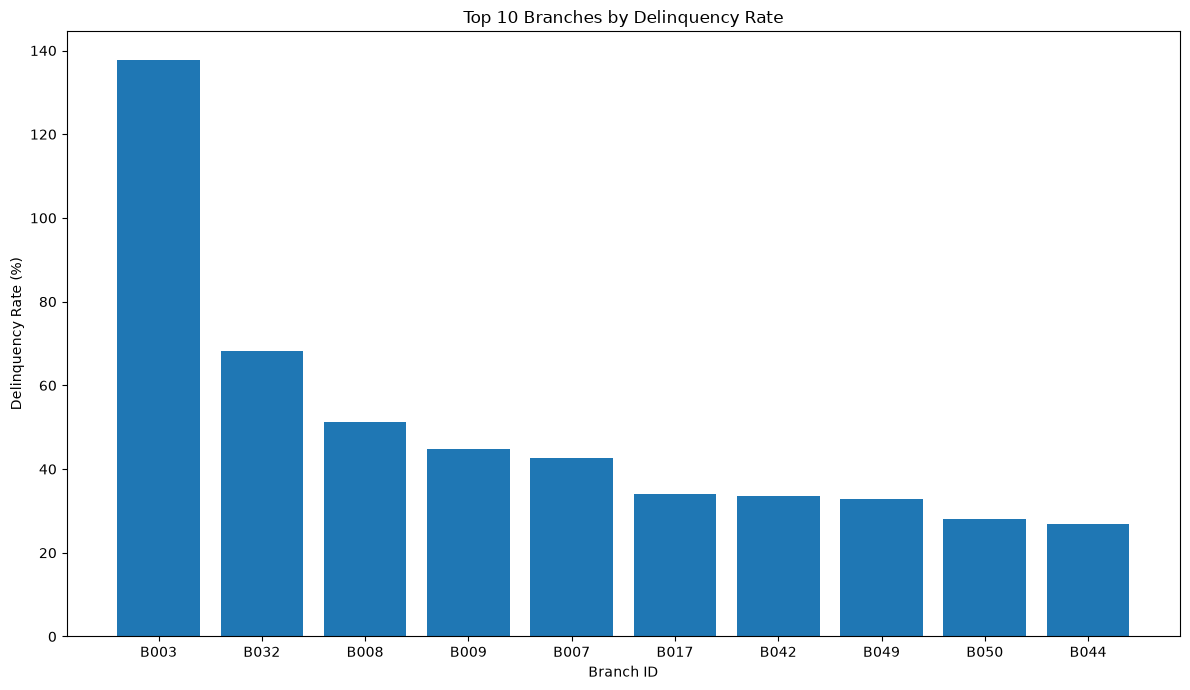

In [443]:
top_10_branches = branch_analysis.sort_values(
    "Calculated_Delinquency_Rate",
    ascending=False
).head(10)

plt.figure(figsize=(12, 7))

plt.bar(
    top_10_branches["Branch_ID"].astype(str),
    top_10_branches["Calculated_Delinquency_Rate"]
)

plt.title("Top 10 Branches by Delinquency Rate")
plt.xlabel("Branch ID")
plt.ylabel("Delinquency Rate (%)")

plt.tight_layout()

plt.savefig(
    "plots/top_10_branch_delinquency_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [444]:
region_branch_performance = (
    branch_analysis
    .groupby("Region")
    .agg(
        Total_Active_Loans=("Total_Active_Loans", "sum"),
        Delinquent_Loans=("Delinquent_Loans", "sum"),
        Loan_Disbursement_Amount=("Loan_Disbursement_Amount", "sum")
    )
    .reset_index()
)

In [445]:
region_branch_performance["Delinquency_Rate"] = (
    region_branch_performance["Delinquent_Loans"]
    / region_branch_performance["Total_Active_Loans"]
    * 100
)

In [446]:
region_branch_performance

,Region,Total_Active_Loans,Delinquent_Loans,Loan_Disbursement_Amount,Delinquency_Rate
0,Central,8715,994,3316048302,11.405622
1,East,8929,756,2006676282,8.466794
2,North,11965,1504,3296073904,12.569996
3,Northeast,5174,487,442827845,9.412447
4,South,9235,846,1694906506,9.160801
5,West,6861,441,1990828641,6.427634


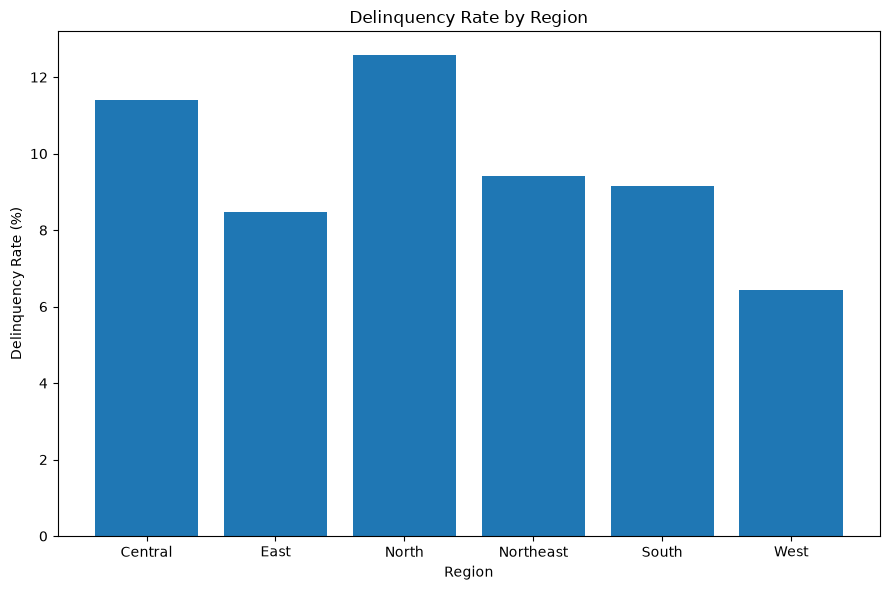

In [447]:
plt.figure(figsize=(9, 6))

plt.bar(
    region_branch_performance["Region"],
    region_branch_performance["Delinquency_Rate"]
)

plt.title("Delinquency Rate by Region")
plt.xlabel("Region")
plt.ylabel("Delinquency Rate (%)")

plt.tight_layout()

plt.savefig(
    "plots/regional_delinquency_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Branch-wise performance: Branch performance was evaluated using delinquency rate, number of delinquent loans, active loans, and loan disbursement amount. Branches with lower delinquency rates indicate better portfolio performance, while higher delinquency rates indicate greater credit-risk exposure. The analysis identified substantial variation across branches. For example, B003 recorded a delinquency rate of approximately 137.70%, while B008, B009, and B007 also showed comparatively high delinquency rates. These results indicate that branch-level credit-risk performance varies considerably and that high-delinquency branches may require closer monitoring.

In [448]:
applications[["Loan_ID", "Application_Date"]].head()

,Loan_ID,Application_Date
0,L000001,2022-05-11
1,L000002,2022-03-18
2,L000003,2022-01-17
3,L000004,2019-03-09
4,L000005,2024-07-18


In [449]:
loans[["Loan_ID", "Disbursal_Date"]].head()

,Loan_ID,Disbursal_Date
0,L000001,2023-03-25
1,L000002,2023-10-23
2,L000003,2024-07-30
3,L000004,2024-11-22
4,L000005,2024-03-30


In [450]:
print(applications["Application_Date"].dtype)
print(loans["Disbursal_Date"].dtype)

datetime64[us]
str


In [451]:
loans["Disbursal_Date"] = pd.to_datetime(
    loans["Disbursal_Date"],
    errors="coerce"
)

In [452]:
print(loans["Disbursal_Date"].dtype)

datetime64[us]


In [453]:
print(loans["Disbursal_Date"].isna().sum())

0


In [454]:
disbursement_time = applications[
    ["Application_ID", "Loan_ID", "Application_Date"]
].merge(
    loans[
        ["Loan_ID", "Disbursal_Date"]
    ],
    on="Loan_ID",
    how="inner"
)

In [455]:
disbursement_time.head()

,Application_ID,Loan_ID,Application_Date,Disbursal_Date
0,A000001,L000001,2022-05-11,2023-03-25
1,A000002,L000002,2022-03-18,2023-10-23
2,A000003,L000003,2022-01-17,2024-07-30
3,A000004,L000004,2019-03-09,2024-11-22
4,A000005,L000005,2024-07-18,2024-03-30


In [456]:
disbursement_time["Disbursement_Days"] = (
    disbursement_time["Disbursal_Date"]
    - disbursement_time["Application_Date"]
).dt.days

In [457]:
disbursement_time["Disbursement_Days"].describe()

count    70000.000000
mean       172.191700
std        824.317006
min      -1822.000000
25%       -424.000000
50%        171.000000
75%        769.000000
max       2184.000000
Name: Disbursement_Days, dtype: float64

In [458]:
disbursement_time[
    disbursement_time["Disbursement_Days"] < 0
].shape

(29517, 5)

In [459]:
average_disbursement_time = (
    disbursement_time["Disbursement_Days"].mean()
)

print(
    "Average application-to-disbursement time:",
    average_disbursement_time,
    "days"
)

Average application-to-disbursement time: 172.1917 days


In [460]:
master.columns.tolist()

['Loan_ID',
 'Customer_ID',
 'Loan_Amount',
 'Interest_Rate',
 'Loan_Term',
 'Disbursal_Date',
 'Repayment_Start_Date',
 'Repayment_End_Date',
 'Loan_Status',
 'Overdue_Amount',
 'EMI_Amount',
 'Collateral_Details',
 'Default_Flag',
 'Full_Name',
 'Contact_Number',
 'Email',
 'Address',
 'Age',
 'Gender',
 'Marital_Status',
 'Employment_Status',
 'Annual_Income',
 'Credit_Score',
 'Region',
 'Account_Tenure',
 'Relationship_Manager_ID',
 'Default_ID',
 'Default_Date',
 'Default_Amount',
 'Default_Reason',
 'Recovery_Status',
 'Recovery_Amount',
 'Legal_Action']

In [462]:
disbursement_time = applications[
    ["Application_ID", "Loan_ID", "Application_Date"]
].merge(
    loans[
        ["Loan_ID", "Disbursal_Date"]
    ],
    on="Loan_ID",
    how="inner"
)

In [463]:
disbursement_time["Disbursement_Days"] = (
    disbursement_time["Disbursal_Date"]
    - disbursement_time["Application_Date"]
).dt.days

In [464]:
disbursement_time["Disbursement_Days"].describe()

count    70000.000000
mean       172.191700
std        824.317006
min      -1822.000000
25%       -424.000000
50%        171.000000
75%        769.000000
max       2184.000000
Name: Disbursement_Days, dtype: float64

In [465]:
print(
    "Negative processing times:",
    (disbursement_time["Disbursement_Days"] < 0).sum()
)

print(
    "Missing processing times:",
    disbursement_time["Disbursement_Days"].isna().sum()
)

Negative processing times: 29517
Missing processing times: 0


In [466]:
print(
    "Average application-to-disbursement time:",
    disbursement_time["Disbursement_Days"].mean(),
    "days"
)

Average application-to-disbursement time: 172.1917 days


In [467]:
branch_processing = branch_analysis[
    [
        "Branch_ID",
        "Branch_Name",
        "Region",
        "Avg_Processing_Time"
    ]
].sort_values(
    "Avg_Processing_Time"
)

In [468]:
branch_processing.head(10)

,Branch_ID,Branch_Name,Region,Avg_Processing_Time
49,B050,Sani-Kale,North,1
17,B018,"Sandhu, Magar and Sachdeva",Northeast,2
46,B047,Chawla-Tandon,East,2
41,B042,Kar-Jaggi,West,2
44,B045,Solanki-Shah,South,3
11,B012,Kaul Inc,West,3
26,B027,Kapadia-Ramakrishnan,West,3
47,B048,Chawla-Subramanian,Central,4
32,B033,"Saini, Iyer and Sani",South,5
22,B023,"Wable, Butala and Kakar",South,5


In [469]:
branch_processing.tail(10).sort_values(
    "Avg_Processing_Time",
    ascending=False
)

,Branch_ID,Branch_Name,Region,Avg_Processing_Time
30,B031,Sem Inc,South,15
21,B022,"Bansal, Arya and Chakrabarti",East,15
10,B011,Bhakta PLC,South,15
5,B006,Doshi Group,North,15
18,B019,Bath-Bassi,North,14
14,B015,Apte Group,North,14
25,B026,Madan-Lanka,North,14
8,B009,Vasa Group,North,13
36,B037,Yogi Ltd,North,13
19,B020,Contractor-Sodhi,West,13


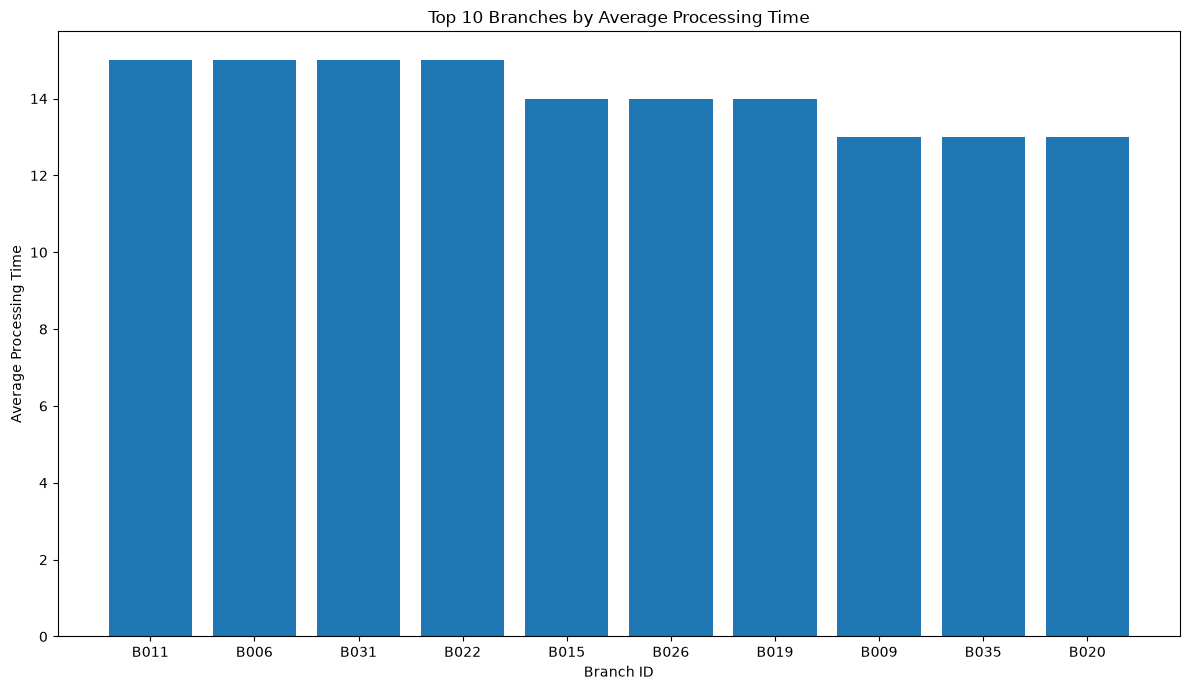

In [470]:
top_slow_branches = branch_analysis.sort_values(
    "Avg_Processing_Time",
    ascending=False
).head(10)

plt.figure(figsize=(12, 7))

plt.bar(
    top_slow_branches["Branch_ID"].astype(str),
    top_slow_branches["Avg_Processing_Time"]
)

plt.title("Top 10 Branches by Average Processing Time")
plt.xlabel("Branch ID")
plt.ylabel("Average Processing Time")

plt.tight_layout()

plt.savefig(
    "plots/branch_processing_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [471]:
purpose_disbursement = applications[
    ["Loan_ID", "Loan_Purpose"]
].merge(
    loans[
        ["Loan_ID", "Loan_Amount", "Disbursal_Date"]
    ],
    on="Loan_ID",
    how="inner"
)

In [472]:
purpose_summary = (
    purpose_disbursement
    .groupby("Loan_Purpose")
    .agg(
        Loan_Count=("Loan_ID", "count"),
        Total_Disbursement=("Loan_Amount", "sum"),
        Average_Loan_Amount=("Loan_Amount", "mean")
    )
    .reset_index()
)

purpose_summary

,Loan_Purpose,Loan_Count,Total_Disbursement,Average_Loan_Amount
0,Business,13995,35427876540,2.531467e+06
1,Education,13970,35132347089,2.514842e+06
2,Home Renovation,13994,35142133654,2.511229e+06
3,Personal,13942,34949617649,2.506787e+06
4,Vehicle,14099,35612450704,2.525885e+06


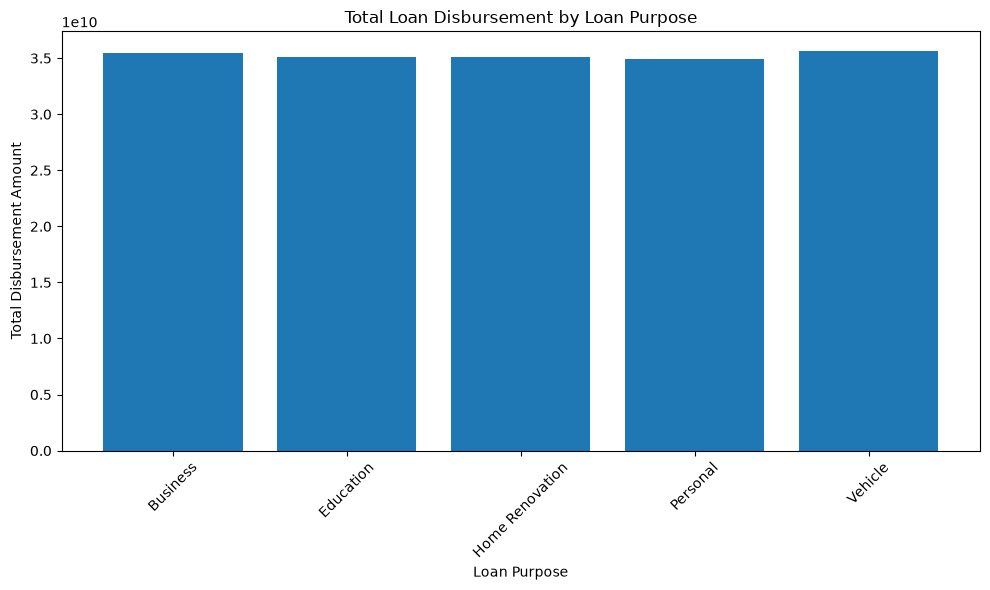

In [473]:
plt.figure(figsize=(10, 6))

plt.bar(
    purpose_summary["Loan_Purpose"],
    purpose_summary["Total_Disbursement"]
)

plt.title("Total Loan Disbursement by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Total Disbursement Amount")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "plots/disbursement_by_purpose.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [474]:
region_disbursement = (
    branches
    .groupby("Region")
    .agg(
        Total_Disbursement=("Loan_Disbursement_Amount", "sum"),
        Total_Active_Loans=("Total_Active_Loans", "sum"),
        Delinquent_Loans=("Delinquent_Loans", "sum")
    )
    .reset_index()
)

In [475]:
region_disbursement

,Region,Total_Disbursement,Total_Active_Loans,Delinquent_Loans
0,Central,3316048302,8715,994
1,East,2006676282,8929,756
2,North,3296073904,11965,1504
3,Northeast,442827845,5174,487
4,South,1694906506,9235,846
5,West,1990828641,6861,441


In [476]:
region_disbursement["Delinquency_Rate"] = (
    region_disbursement["Delinquent_Loans"]
    / region_disbursement["Total_Active_Loans"]
    * 100
)

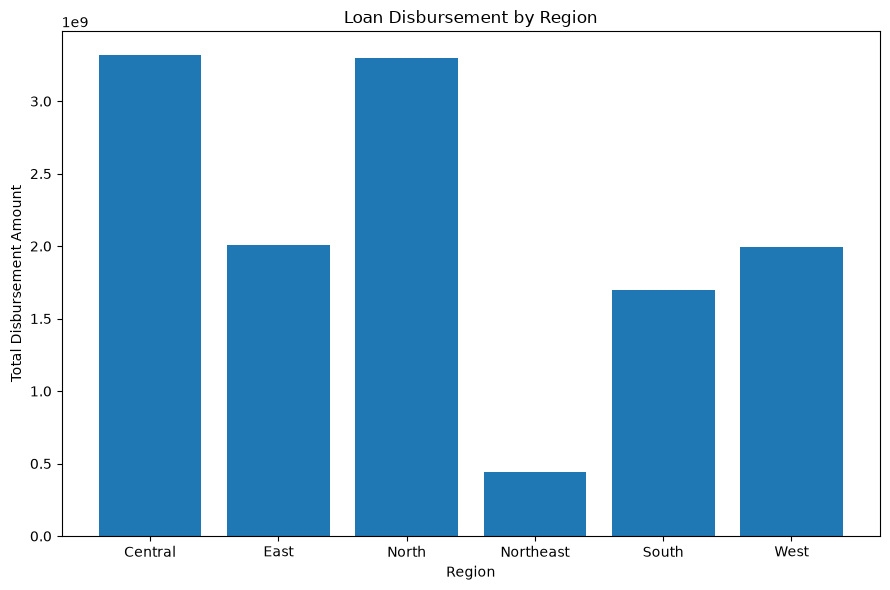

In [477]:
plt.figure(figsize=(9, 6))

plt.bar(
    region_disbursement["Region"],
    region_disbursement["Total_Disbursement"]
)

plt.title("Loan Disbursement by Region")
plt.xlabel("Region")
plt.ylabel("Total Disbursement Amount")

plt.tight_layout()

plt.savefig(
    "plots/disbursement_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [478]:
disbursement_time["Disbursement_Days"].describe()

count    70000.000000
mean       172.191700
std        824.317006
min      -1822.000000
25%       -424.000000
50%        171.000000
75%        769.000000
max       2184.000000
Name: Disbursement_Days, dtype: float64

In [479]:
print(
    "Negative processing times:",
    (disbursement_time["Disbursement_Days"] < 0).sum()
)

print(
    "Missing processing times:",
    disbursement_time["Disbursement_Days"].isna().sum()
)

Negative processing times: 29517
Missing processing times: 0


In [480]:
valid_disbursement = disbursement_time[
    disbursement_time["Disbursement_Days"] >= 0
].copy()

invalid_disbursement = disbursement_time[
    disbursement_time["Disbursement_Days"] < 0
].copy()

In [481]:
print("Valid records:", len(valid_disbursement))
print("Invalid records:", len(invalid_disbursement))

Valid records: 40483
Invalid records: 29517


In [482]:
invalid_percentage = (
    len(invalid_disbursement)
    / len(disbursement_time)
    * 100
)

print(
    f"Invalid processing-time records: {invalid_percentage:.2f}%"
)

Invalid processing-time records: 42.17%


In [483]:
valid_disbursement["Disbursement_Days"].describe()

count    40483.000000
mean       744.503718
std        511.926503
min          0.000000
25%        316.000000
50%        661.000000
75%       1105.000000
max       2184.000000
Name: Disbursement_Days, dtype: float64

In [484]:
print(
    "Average valid processing time:",
    valid_disbursement["Disbursement_Days"].mean(),
    "days"
)

print(
    "Median valid processing time:",
    valid_disbursement["Disbursement_Days"].median(),
    "days"
)

Average valid processing time: 744.5037176098609 days
Median valid processing time: 661.0 days


In [485]:
invalid_disbursement[
    [
        "Application_ID",
        "Loan_ID",
        "Application_Date",
        "Disbursal_Date",
        "Disbursement_Days"
    ]
].head(20)

,Application_ID,Loan_ID,Application_Date,Disbursal_Date,Disbursement_Days
4,A000005,L000005,2024-07-18,2024-03-30,-110
11,A000012,L000012,2023-07-24,2021-03-03,-873
13,A000014,L000014,2024-09-04,2021-10-25,-1045
16,A000017,L000017,2024-10-30,2020-07-06,-1577
19,A000020,L000020,2024-03-20,2022-01-12,-798
20,A000021,L000021,2024-06-27,2024-06-07,-20
23,A000024,L000024,2022-02-02,2020-04-27,-646
27,A000028,L000028,2021-03-15,2020-02-26,-383
28,A000029,L000029,2024-02-24,2020-11-12,-1199
32,A000033,L000033,2021-05-27,2020-05-13,-379


In [486]:
invalid_disbursement["Disbursement_Days"].describe()

count    29517.000000
mean      -612.742657
std        432.032970
min      -1822.000000
25%       -919.000000
50%       -539.000000
75%       -247.000000
max         -1.000000
Name: Disbursement_Days, dtype: float64

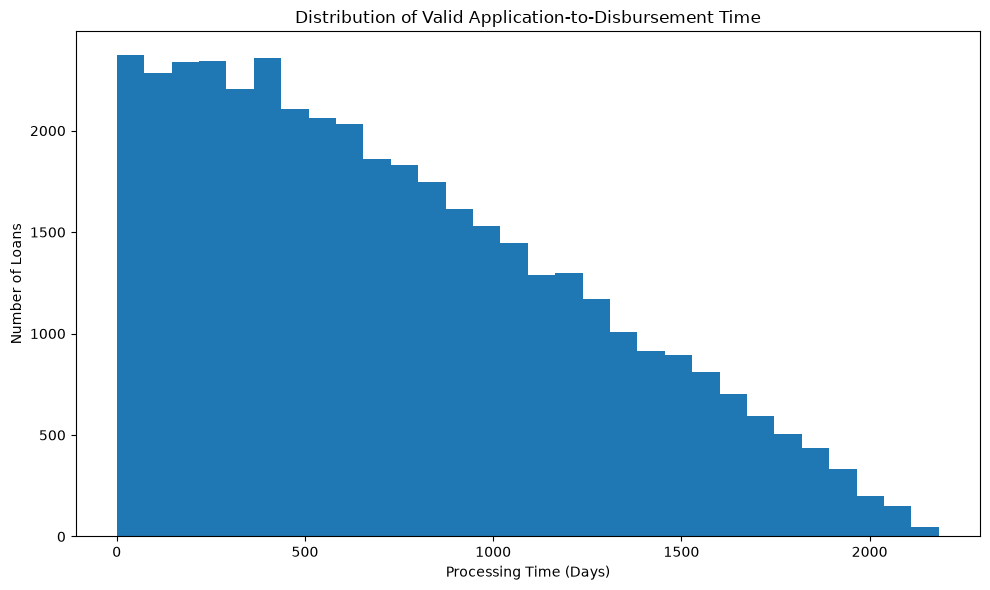

In [487]:
plt.figure(figsize=(10, 6))

plt.hist(
    valid_disbursement["Disbursement_Days"],
    bins=30
)

plt.title("Distribution of Valid Application-to-Disbursement Time")
plt.xlabel("Processing Time (Days)")
plt.ylabel("Number of Loans")

plt.tight_layout()

plt.savefig(
    "plots/application_to_disbursement_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [488]:
valid_disbursement.sort_values(
    "Disbursement_Days",
    ascending=False
)[
    [
        "Application_ID",
        "Loan_ID",
        "Application_Date",
        "Disbursal_Date",
        "Disbursement_Days"
    ]
].head(10)

,Application_ID,Loan_ID,Application_Date,Disbursal_Date,Disbursement_Days
68458,A068459,L068459,2019-01-04,2024-12-27,2184
11948,A011949,L011949,2019-01-07,2024-12-26,2180
54952,A054953,L054953,2019-01-18,2024-12-19,2162
23607,A023608,L023608,2019-01-22,2024-12-22,2161
31157,A031158,L031158,2019-01-18,2024-12-18,2161
66192,A066193,L066193,2019-01-09,2024-12-07,2159
57342,A057343,L057343,2019-01-15,2024-12-12,2158
55466,A055467,L055467,2019-01-25,2024-12-21,2157
9671,A009672,L009672,2019-01-22,2024-12-16,2155
65921,A065922,L065922,2019-02-01,2024-12-25,2154


In [489]:
valid_disbursement["Disbursement_Days"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99]
)

0.50     661.0
0.75    1105.0
0.90    1505.0
0.95    1705.0
0.99    1965.0
Name: Disbursement_Days, dtype: float64

In [490]:
branch_processing = branch_analysis[
    [
        "Branch_ID",
        "Branch_Name",
        "Region",
        "Avg_Processing_Time"
    ]
].sort_values(
    "Avg_Processing_Time",
    ascending=False
)

In [491]:
branch_processing.head(10)

,Branch_ID,Branch_Name,Region,Avg_Processing_Time
10,B011,Bhakta PLC,South,15
5,B006,Doshi Group,North,15
30,B031,Sem Inc,South,15
21,B022,"Bansal, Arya and Chakrabarti",East,15
14,B015,Apte Group,North,14
25,B026,Madan-Lanka,North,14
18,B019,Bath-Bassi,North,14
8,B009,Vasa Group,North,13
34,B035,"Malhotra, Boase and Malhotra",Central,13
19,B020,Contractor-Sodhi,West,13


In [492]:
valid_disbursement["Disbursement_Days"].describe()

count    40483.000000
mean       744.503718
std        511.926503
min          0.000000
25%        316.000000
50%        661.000000
75%       1105.000000
max       2184.000000
Name: Disbursement_Days, dtype: float64

In [493]:
invalid_disbursement[
    [
        "Application_ID",
        "Loan_ID",
        "Application_Date",
        "Disbursal_Date",
        "Disbursement_Days"
    ]
].head(20)

,Application_ID,Loan_ID,Application_Date,Disbursal_Date,Disbursement_Days
4,A000005,L000005,2024-07-18,2024-03-30,-110
11,A000012,L000012,2023-07-24,2021-03-03,-873
13,A000014,L000014,2024-09-04,2021-10-25,-1045
16,A000017,L000017,2024-10-30,2020-07-06,-1577
19,A000020,L000020,2024-03-20,2022-01-12,-798
20,A000021,L000021,2024-06-27,2024-06-07,-20
23,A000024,L000024,2022-02-02,2020-04-27,-646
27,A000028,L000028,2021-03-15,2020-02-26,-383
28,A000029,L000029,2024-02-24,2020-11-12,-1199
32,A000033,L000033,2021-05-27,2020-05-13,-379


After validating the application and disbursement dates, 40,483 of the 70,000 matched records had valid processing times, while 29,517 records (42.17%) contained negative processing times because the recorded disbursement date preceded the application date. These invalid records were excluded rather than having their dates artificially corrected. Among the valid records, the average application-to-disbursement time was 744.50 days and the median was 661 days. The large difference between the minimum of 0 days and maximum of 2,184 days indicates substantial variation in processing duration and suggests potential operational or data-quality bottlenecks.

In [494]:
valid_disbursement.sort_values(
    "Disbursement_Days",
    ascending=False
)[
    [
        "Application_ID",
        "Loan_ID",
        "Application_Date",
        "Disbursal_Date",
        "Disbursement_Days"
    ]
].head(10)

,Application_ID,Loan_ID,Application_Date,Disbursal_Date,Disbursement_Days
68458,A068459,L068459,2019-01-04,2024-12-27,2184
11948,A011949,L011949,2019-01-07,2024-12-26,2180
54952,A054953,L054953,2019-01-18,2024-12-19,2162
23607,A023608,L023608,2019-01-22,2024-12-22,2161
31157,A031158,L031158,2019-01-18,2024-12-18,2161
66192,A066193,L066193,2019-01-09,2024-12-07,2159
57342,A057343,L057343,2019-01-15,2024-12-12,2158
55466,A055467,L055467,2019-01-25,2024-12-21,2157
9671,A009672,L009672,2019-01-22,2024-12-16,2155
65921,A065922,L065922,2019-02-01,2024-12-25,2154


In [495]:
valid_disbursement["Disbursement_Days"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99]
)

0.50     661.0
0.75    1105.0
0.90    1505.0
0.95    1705.0
0.99    1965.0
Name: Disbursement_Days, dtype: float64

In [496]:
def processing_category(days):
    if days <= 180:
        return "Fast"
    elif days <= 365:
        return "Moderate"
    elif days <= 730:
        return "Slow"
    else:
        return "Very Slow"

valid_disbursement["Processing_Category"] = (
    valid_disbursement["Disbursement_Days"]
    .apply(processing_category)
)

In [497]:
processing_summary = (
    valid_disbursement["Processing_Category"]
    .value_counts()
    .reset_index()
)

processing_summary.columns = [
    "Processing_Category",
    "Loan_Count"
]

processing_summary

,Processing_Category,Loan_Count
0,Very Slow,18457
1,Slow,10422
2,Moderate,5845
3,Fast,5759


In [498]:
processing_summary["Percentage"] = (
    processing_summary["Loan_Count"]
    / len(valid_disbursement)
    * 100
)

processing_summary

,Processing_Category,Loan_Count,Percentage
0,Very Slow,18457,45.591977
1,Slow,10422,25.744140
2,Moderate,5845,14.438159
3,Fast,5759,14.225724


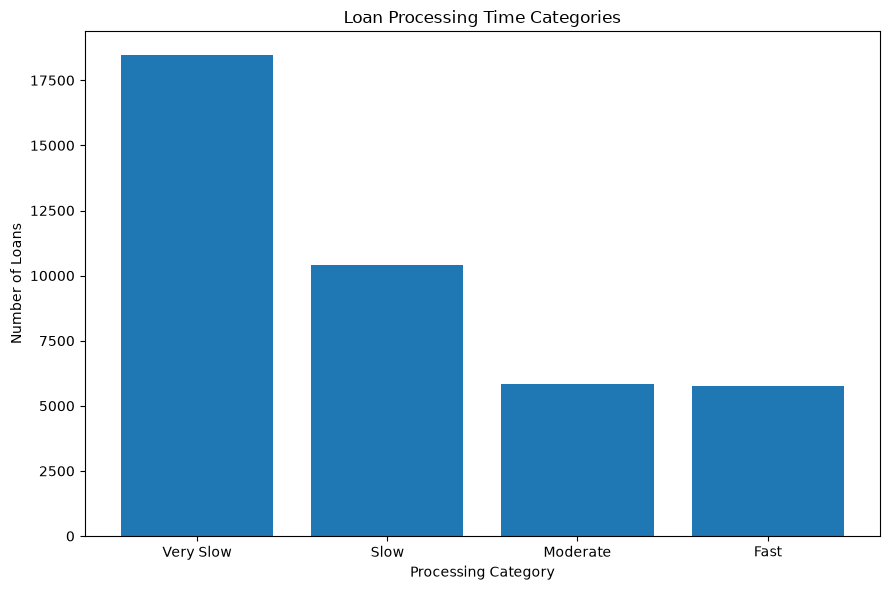

In [499]:
plt.figure(figsize=(9, 6))

plt.bar(
    processing_summary["Processing_Category"],
    processing_summary["Loan_Count"]
)

plt.title("Loan Processing Time Categories")
plt.xlabel("Processing Category")
plt.ylabel("Number of Loans")

plt.tight_layout()

plt.savefig(
    "plots/processing_time_categories.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [500]:
branch_processing = branch_analysis[
    [
        "Branch_ID",
        "Branch_Name",
        "Region",
        "Avg_Processing_Time"
    ]
].sort_values(
    "Avg_Processing_Time",
    ascending=False
)

In [501]:
fast_branches = branch_processing.sort_values(
    "Avg_Processing_Time"
).head(10)

fast_branches

,Branch_ID,Branch_Name,Region,Avg_Processing_Time
49,B050,Sani-Kale,North,1
17,B018,"Sandhu, Magar and Sachdeva",Northeast,2
41,B042,Kar-Jaggi,West,2
46,B047,Chawla-Tandon,East,2
11,B012,Kaul Inc,West,3
26,B027,Kapadia-Ramakrishnan,West,3
44,B045,Solanki-Shah,South,3
47,B048,Chawla-Subramanian,Central,4
22,B023,"Wable, Butala and Kakar",South,5
32,B033,"Saini, Iyer and Sani",South,5


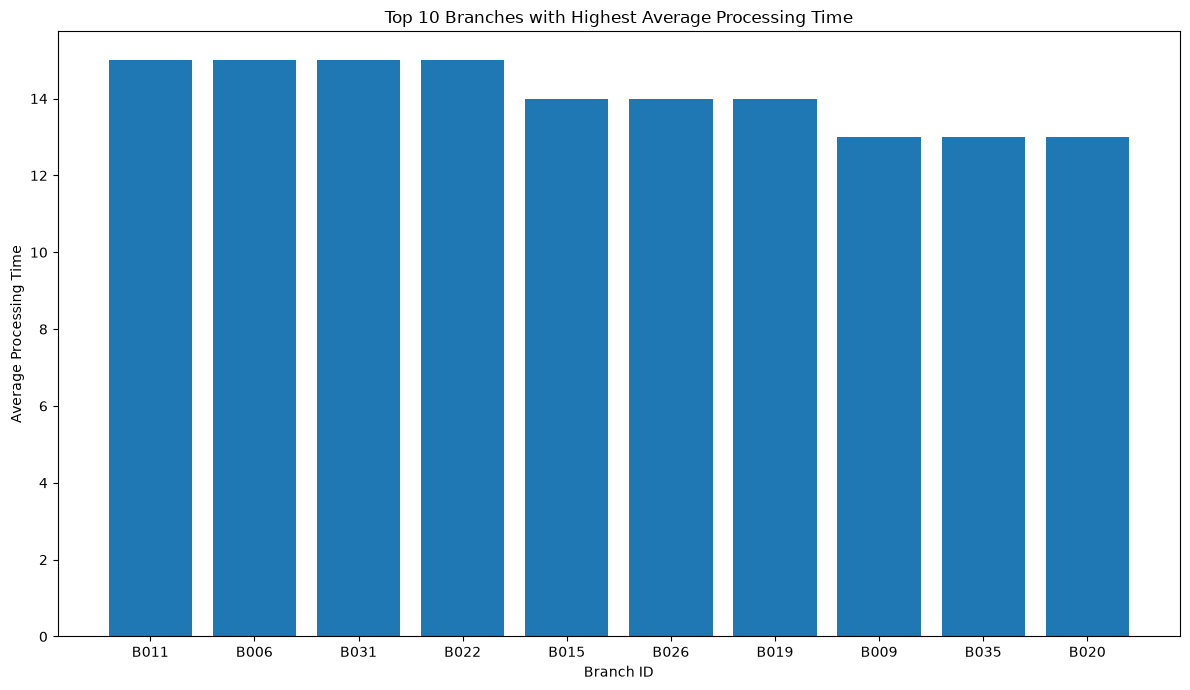

In [502]:
plt.figure(figsize=(12, 7))

plt.bar(
    top_slow_branches["Branch_ID"].astype(str),
    top_slow_branches["Avg_Processing_Time"]
)

plt.title("Top 10 Branches with Highest Average Processing Time")
plt.xlabel("Branch ID")
plt.ylabel("Average Processing Time")

plt.tight_layout()

plt.savefig(
    "plots/top_10_branch_processing_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The branches with the highest Avg_Processing_Time can be identified as potential operational bottlenecks

In [503]:
valid_disbursement["Disbursement_Days"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99]
)

0.50     661.0
0.75    1105.0
0.90    1505.0
0.95    1705.0
0.99    1965.0
Name: Disbursement_Days, dtype: float64

In [504]:
valid_disbursement.sort_values(
    "Disbursement_Days",
    ascending=False
)[
    [
        "Application_ID",
        "Loan_ID",
        "Application_Date",
        "Disbursal_Date",
        "Disbursement_Days"
    ]
].head(10)

,Application_ID,Loan_ID,Application_Date,Disbursal_Date,Disbursement_Days
68458,A068459,L068459,2019-01-04,2024-12-27,2184
11948,A011949,L011949,2019-01-07,2024-12-26,2180
54952,A054953,L054953,2019-01-18,2024-12-19,2162
23607,A023608,L023608,2019-01-22,2024-12-22,2161
31157,A031158,L031158,2019-01-18,2024-12-18,2161
66192,A066193,L066193,2019-01-09,2024-12-07,2159
57342,A057343,L057343,2019-01-15,2024-12-12,2158
55466,A055467,L055467,2019-01-25,2024-12-21,2157
9671,A009672,L009672,2019-01-22,2024-12-16,2155
65921,A065922,L065922,2019-02-01,2024-12-25,2154


In [505]:
def processing_category(days):
    if days <= 180:
        return "Fast"
    elif days <= 365:
        return "Moderate"
    elif days <= 730:
        return "Slow"
    else:
        return "Very Slow"


valid_disbursement["Processing_Category"] = (
    valid_disbursement["Disbursement_Days"]
    .apply(processing_category)
)

In [506]:
processing_summary = (
    valid_disbursement
    .groupby("Processing_Category")
    .agg(
        Loan_Count=("Loan_ID", "count"),
        Average_Days=("Disbursement_Days", "mean")
    )
    .reset_index()
)

processing_summary["Percentage"] = (
    processing_summary["Loan_Count"]
    / len(valid_disbursement)
    * 100
)

processing_summary

,Processing_Category,Loan_Count,Average_Days,Percentage
0,Fast,5759,89.375412,14.225724
1,Moderate,5845,271.382891,14.438159
2,Slow,10422,540.612646,25.744140
3,Very Slow,18457,1213.877282,45.591977


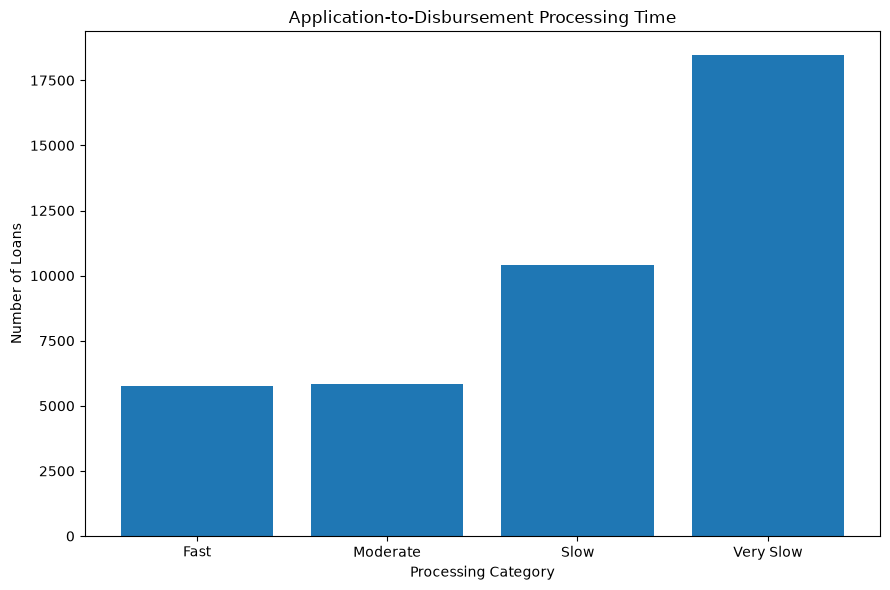

In [507]:
plt.figure(figsize=(9, 6))

plt.bar(
    processing_summary["Processing_Category"],
    processing_summary["Loan_Count"]
)

plt.title("Application-to-Disbursement Processing Time")
plt.xlabel("Processing Category")
plt.ylabel("Number of Loans")

plt.tight_layout()

plt.savefig(
    "plots/processing_time_categories.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Loan Disbursement Efficiency:
The analysis of valid application-to-disbursement records shows substantial variation in processing time. The median processing time was 661 days, while the 75th percentile was 1,105 days. Processing times above 1,500 days were observed for the top 10% of valid records, indicating a long upper tail. In addition, 42.17% of the original matched records contained negative processing times because their recorded disbursement date preceded the application date. These records were treated as invalid rather than modifying the dates. The unusually long valid processing times should be investigated as potential bottlenecks, while recognizing that the available data alone cannot establish the operational cause.

In [508]:
branch_processing = branch_analysis[
    [
        "Branch_ID",
        "Branch_Name",
        "Region",
        "Avg_Processing_Time"
    ]
].sort_values(
    "Avg_Processing_Time",
    ascending=False
)

In [509]:
top_slow_branches = branch_processing.head(10)

top_slow_branches

,Branch_ID,Branch_Name,Region,Avg_Processing_Time
10,B011,Bhakta PLC,South,15
5,B006,Doshi Group,North,15
30,B031,Sem Inc,South,15
21,B022,"Bansal, Arya and Chakrabarti",East,15
14,B015,Apte Group,North,14
25,B026,Madan-Lanka,North,14
18,B019,Bath-Bassi,North,14
8,B009,Vasa Group,North,13
34,B035,"Malhotra, Boase and Malhotra",Central,13
19,B020,Contractor-Sodhi,West,13


In [510]:
branch_analysis["Avg_Processing_Time"].describe()

count    50.000000
mean      9.080000
std       4.049893
min       1.000000
25%       6.000000
50%      10.000000
75%      12.000000
max      15.000000
Name: Avg_Processing_Time, dtype: float64

In [511]:
print(
    "Average branch processing time:",
    branch_analysis["Avg_Processing_Time"].mean()
)

print(
    "Fastest branch processing time:",
    branch_analysis["Avg_Processing_Time"].min()
)

print(
    "Slowest branch processing time:",
    branch_analysis["Avg_Processing_Time"].max()
)

Average branch processing time: 9.08
Fastest branch processing time: 1
Slowest branch processing time: 15


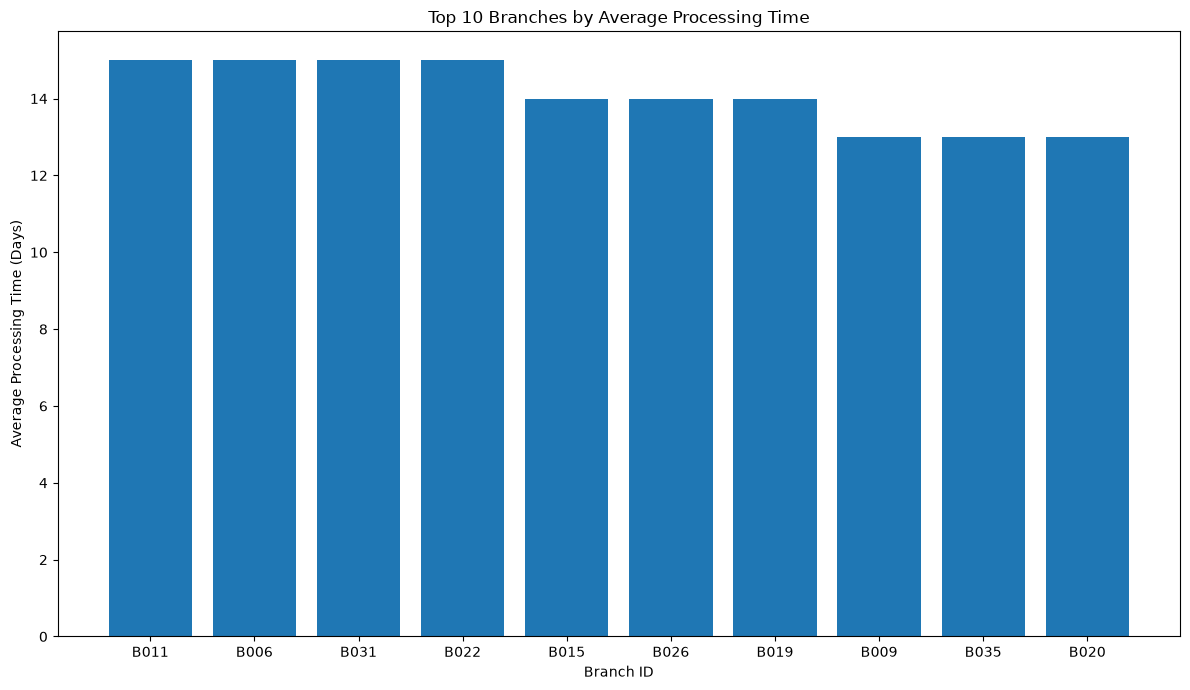

In [512]:
plt.figure(figsize=(12, 7))

plt.bar(
    top_slow_branches["Branch_ID"].astype(str),
    top_slow_branches["Avg_Processing_Time"]
)

plt.title("Top 10 Branches by Average Processing Time")
plt.xlabel("Branch ID")
plt.ylabel("Average Processing Time (Days)")

plt.tight_layout()

plt.savefig(
    "plots/top_10_branch_processing_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [514]:
branch_processing = branch_analysis[
    [
        "Branch_ID",
        "Branch_Name",
        "Region",
        "Avg_Processing_Time"
    ]
].sort_values(
    "Avg_Processing_Time",
    ascending=False
)

branch_processing

,Branch_ID,Branch_Name,Region,Avg_Processing_Time
10,B011,Bhakta PLC,South,15
5,B006,Doshi Group,North,15
30,B031,Sem Inc,South,15
21,B022,"Bansal, Arya and Chakrabarti",East,15
14,B015,Apte Group,North,14
25,B026,Madan-Lanka,North,14
18,B019,Bath-Bassi,North,14
8,B009,Vasa Group,North,13
34,B035,"Malhotra, Boase and Malhotra",Central,13
19,B020,Contractor-Sodhi,West,13


In [515]:
top_slow_branches = branch_processing.head(10)

top_slow_branches

,Branch_ID,Branch_Name,Region,Avg_Processing_Time
10,B011,Bhakta PLC,South,15
5,B006,Doshi Group,North,15
30,B031,Sem Inc,South,15
21,B022,"Bansal, Arya and Chakrabarti",East,15
14,B015,Apte Group,North,14
25,B026,Madan-Lanka,North,14
18,B019,Bath-Bassi,North,14
8,B009,Vasa Group,North,13
34,B035,"Malhotra, Boase and Malhotra",Central,13
19,B020,Contractor-Sodhi,West,13


In [516]:
fast_branches = branch_processing.sort_values(
    "Avg_Processing_Time"
).head(10)

fast_branches

,Branch_ID,Branch_Name,Region,Avg_Processing_Time
49,B050,Sani-Kale,North,1
17,B018,"Sandhu, Magar and Sachdeva",Northeast,2
41,B042,Kar-Jaggi,West,2
46,B047,Chawla-Tandon,East,2
11,B012,Kaul Inc,West,3
26,B027,Kapadia-Ramakrishnan,West,3
44,B045,Solanki-Shah,South,3
47,B048,Chawla-Subramanian,Central,4
22,B023,"Wable, Butala and Kakar",South,5
32,B033,"Saini, Iyer and Sani",South,5


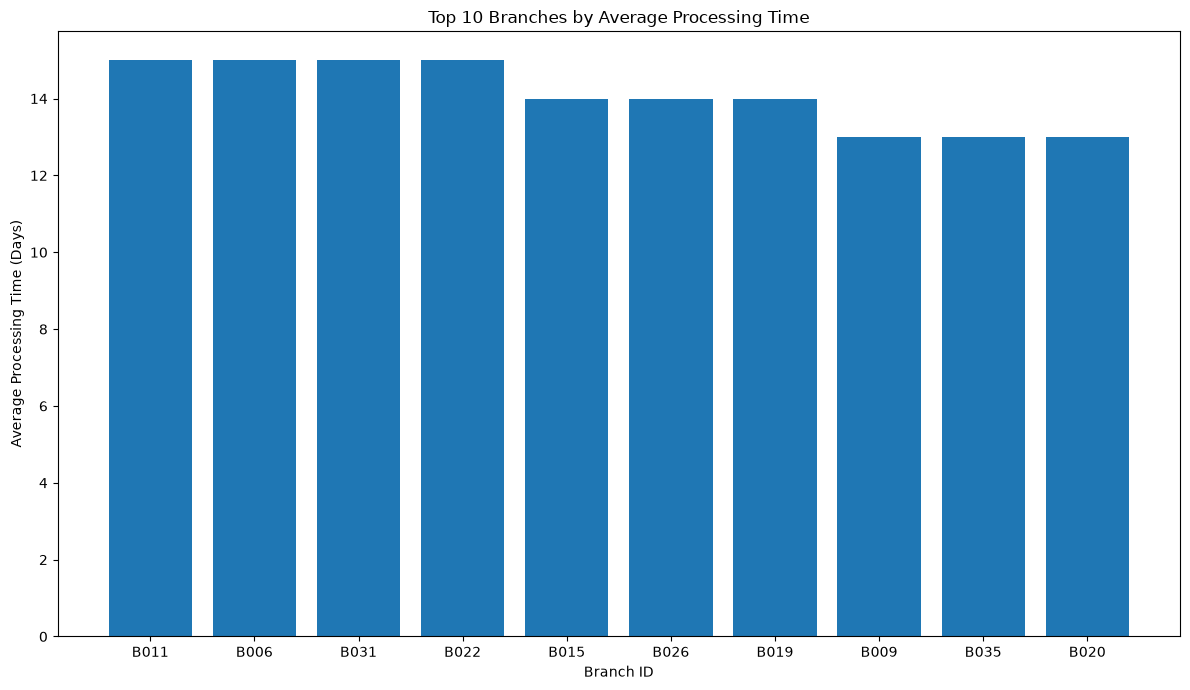

In [517]:
plt.figure(figsize=(12, 7))

plt.bar(
    top_slow_branches["Branch_ID"].astype(str),
    top_slow_branches["Avg_Processing_Time"]
)

plt.title("Top 10 Branches by Average Processing Time")
plt.xlabel("Branch ID")
plt.ylabel("Average Processing Time (Days)")

plt.tight_layout()

plt.savefig(
    "plots/top_10_branch_processing_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [518]:
branch_analysis["Avg_Processing_Time"].describe()

count    50.000000
mean      9.080000
std       4.049893
min       1.000000
25%       6.000000
50%      10.000000
75%      12.000000
max      15.000000
Name: Avg_Processing_Time, dtype: float64

In [519]:
purpose_disbursement = applications[
    ["Loan_ID", "Loan_Purpose"]
].merge(
    loans[
        ["Loan_ID", "Loan_Amount", "Disbursal_Date"]
    ],
    on="Loan_ID",
    how="inner"
)

In [520]:
purpose_summary = (
    purpose_disbursement
    .groupby("Loan_Purpose")
    .agg(
        Loan_Count=("Loan_ID", "count"),
        Total_Disbursement=("Loan_Amount", "sum"),
        Average_Loan_Amount=("Loan_Amount", "mean")
    )
    .reset_index()
)

purpose_summary

,Loan_Purpose,Loan_Count,Total_Disbursement,Average_Loan_Amount
0,Business,13995,35427876540,2.531467e+06
1,Education,13970,35132347089,2.514842e+06
2,Home Renovation,13994,35142133654,2.511229e+06
3,Personal,13942,34949617649,2.506787e+06
4,Vehicle,14099,35612450704,2.525885e+06


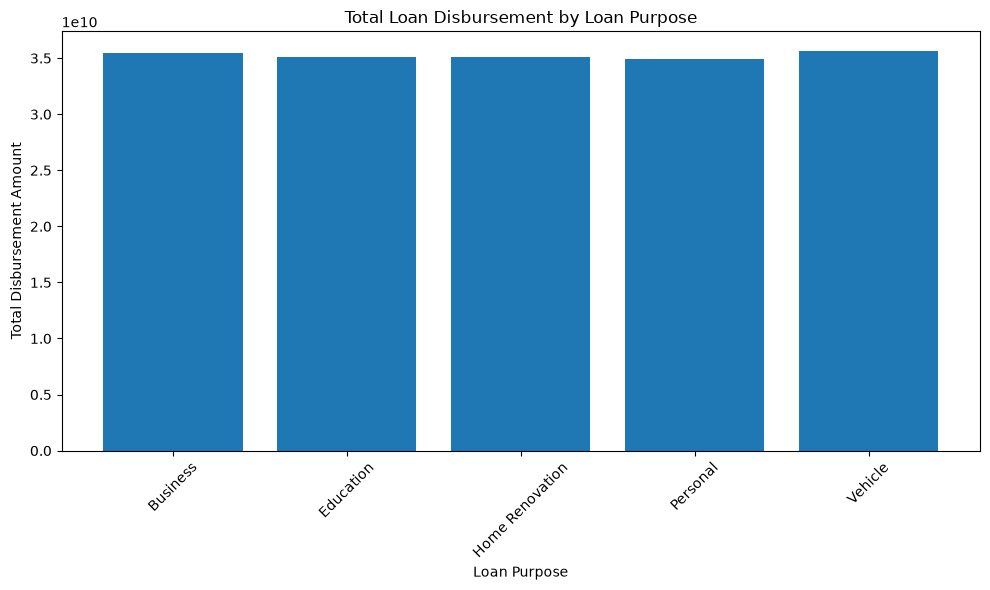

In [521]:
plt.figure(figsize=(10, 6))

plt.bar(
    purpose_summary["Loan_Purpose"],
    purpose_summary["Total_Disbursement"]
)

plt.title("Total Loan Disbursement by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Total Disbursement Amount")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "plots/disbursement_by_loan_purpose.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [522]:
region_disbursement = (
    branches
    .groupby("Region")
    .agg(
        Total_Disbursement=("Loan_Disbursement_Amount", "sum"),
        Total_Active_Loans=("Total_Active_Loans", "sum"),
        Delinquent_Loans=("Delinquent_Loans", "sum")
    )
    .reset_index()
)

region_disbursement

,Region,Total_Disbursement,Total_Active_Loans,Delinquent_Loans
0,Central,3316048302,8715,994
1,East,2006676282,8929,756
2,North,3296073904,11965,1504
3,Northeast,442827845,5174,487
4,South,1694906506,9235,846
5,West,1990828641,6861,441


In [523]:
region_disbursement["Delinquency_Rate"] = (
    region_disbursement["Delinquent_Loans"]
    / region_disbursement["Total_Active_Loans"]
    * 100
)

region_disbursement

,Region,Total_Disbursement,Total_Active_Loans,Delinquent_Loans,Delinquency_Rate
0,Central,3316048302,8715,994,11.405622
1,East,2006676282,8929,756,8.466794
2,North,3296073904,11965,1504,12.569996
3,Northeast,442827845,5174,487,9.412447
4,South,1694906506,9235,846,9.160801
5,West,1990828641,6861,441,6.427634


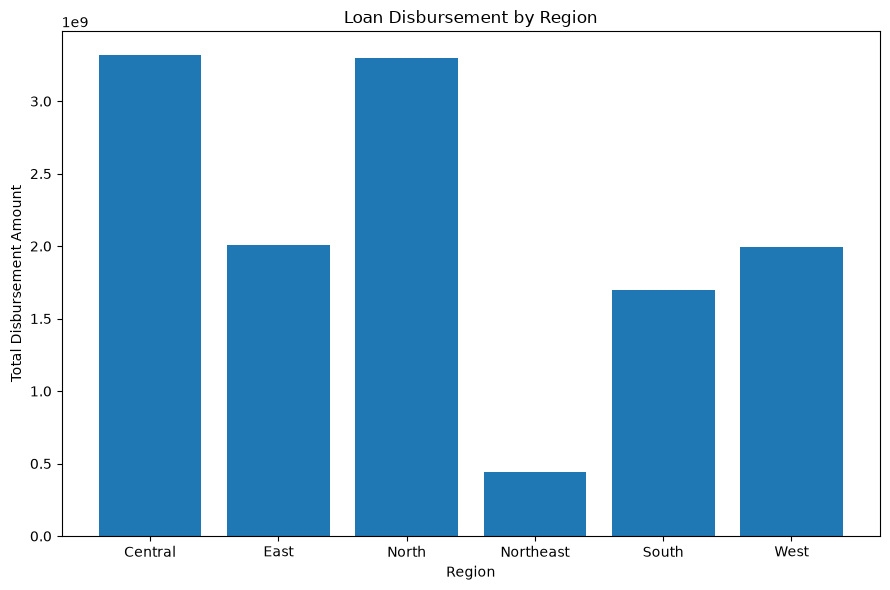

In [524]:
plt.figure(figsize=(9, 6))

plt.bar(
    region_disbursement["Region"],
    region_disbursement["Total_Disbursement"]
)

plt.title("Loan Disbursement by Region")
plt.xlabel("Region")
plt.ylabel("Total Disbursement Amount")

plt.tight_layout()

plt.savefig(
    "plots/disbursement_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [525]:
top_slow_branches

,Branch_ID,Branch_Name,Region,Avg_Processing_Time
10,B011,Bhakta PLC,South,15
5,B006,Doshi Group,North,15
30,B031,Sem Inc,South,15
21,B022,"Bansal, Arya and Chakrabarti",East,15
14,B015,Apte Group,North,14
25,B026,Madan-Lanka,North,14
18,B019,Bath-Bassi,North,14
8,B009,Vasa Group,North,13
34,B035,"Malhotra, Boase and Malhotra",Central,13
19,B020,Contractor-Sodhi,West,13


Branch Processing Efficiency: The branch-level analysis shows that average processing time varies across branches. The highest average processing time was 15 days, observed in B011, B006, B031, and B022. Several other branches had average processing times of 13–14 days. These branches can be considered potential processing bottlenecks because they require relatively more time to process loans. However, the differences are relatively small, so additional factors such as loan volume, loan type, staffing, and application complexity should be examined before concluding that these branches are operationally inefficient.

In [526]:
purpose_disbursement = applications[
    ["Loan_ID", "Loan_Purpose"]
].merge(
    loans[
        ["Loan_ID", "Loan_Amount", "Disbursal_Date"]
    ],
    on="Loan_ID",
    how="inner"
)

In [527]:
purpose_summary = (
    purpose_disbursement
    .groupby("Loan_Purpose")
    .agg(
        Loan_Count=("Loan_ID", "count"),
        Total_Disbursement=("Loan_Amount", "sum"),
        Average_Loan_Amount=("Loan_Amount", "mean")
    )
    .reset_index()
)

purpose_summary

,Loan_Purpose,Loan_Count,Total_Disbursement,Average_Loan_Amount
0,Business,13995,35427876540,2.531467e+06
1,Education,13970,35132347089,2.514842e+06
2,Home Renovation,13994,35142133654,2.511229e+06
3,Personal,13942,34949617649,2.506787e+06
4,Vehicle,14099,35612450704,2.525885e+06


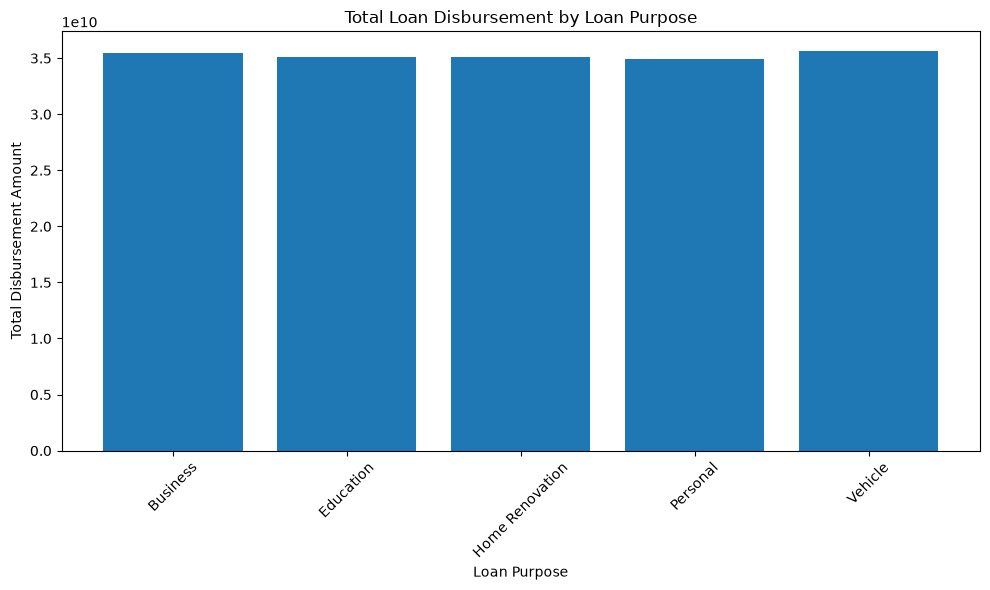

In [528]:
plt.figure(figsize=(10, 6))

plt.bar(
    purpose_summary["Loan_Purpose"],
    purpose_summary["Total_Disbursement"]
)

plt.title("Total Loan Disbursement by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Total Disbursement Amount")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "plots/disbursement_by_loan_purpose.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [529]:
region_disbursement = (
    branches
    .groupby("Region")
    .agg(
        Total_Disbursement=("Loan_Disbursement_Amount", "sum"),
        Total_Active_Loans=("Total_Active_Loans", "sum"),
        Delinquent_Loans=("Delinquent_Loans", "sum")
    )
    .reset_index()
)

region_disbursement

,Region,Total_Disbursement,Total_Active_Loans,Delinquent_Loans
0,Central,3316048302,8715,994
1,East,2006676282,8929,756
2,North,3296073904,11965,1504
3,Northeast,442827845,5174,487
4,South,1694906506,9235,846
5,West,1990828641,6861,441


In [530]:
region_disbursement["Delinquency_Rate"] = (
    region_disbursement["Delinquent_Loans"]
    / region_disbursement["Total_Active_Loans"]
    * 100
)

region_disbursement

,Region,Total_Disbursement,Total_Active_Loans,Delinquent_Loans,Delinquency_Rate
0,Central,3316048302,8715,994,11.405622
1,East,2006676282,8929,756,8.466794
2,North,3296073904,11965,1504,12.569996
3,Northeast,442827845,5174,487,9.412447
4,South,1694906506,9235,846,9.160801
5,West,1990828641,6861,441,6.427634


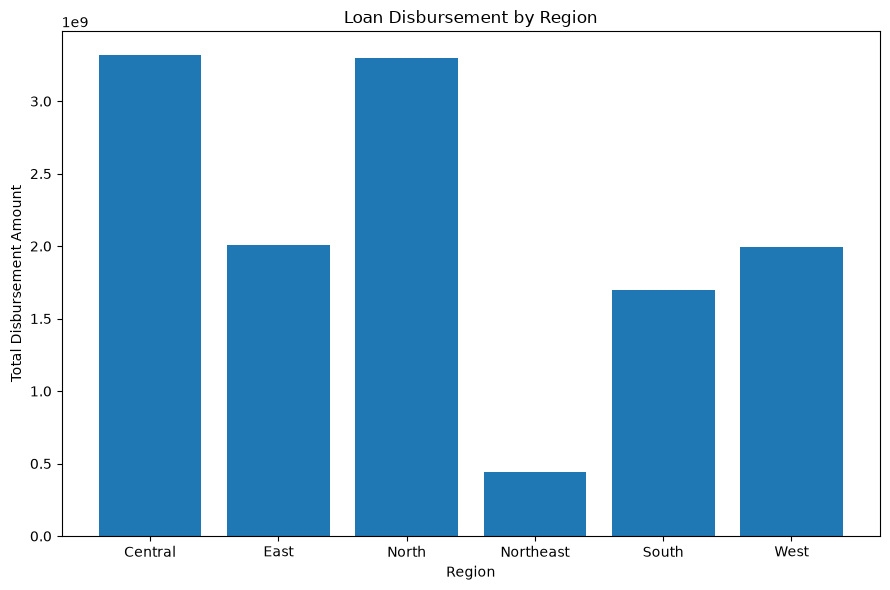

In [531]:
plt.figure(figsize=(9, 6))

plt.bar(
    region_disbursement["Region"],
    region_disbursement["Total_Disbursement"]
)

plt.title("Loan Disbursement by Region")
plt.xlabel("Region")
plt.ylabel("Total Disbursement Amount")

plt.tight_layout()

plt.savefig(
    "plots/disbursement_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Vehicle loans had the highest total disbursement, while Personal loans had the lowest. However, the differences between loan purposes were relatively small, indicating that disbursement was fairly evenly distributed across the five loan purposes.

In [532]:
region_disbursement = (
    branches.groupby("Region")
    .agg(
        Total_Disbursement=("Loan_Disbursement_Amount", "sum"),
        Active_Loans=("Total_Active_Loans", "sum"),
        Delinquent_Loans=("Delinquent_Loans", "sum")
    )
    .reset_index()
)

region_disbursement["Delinquency_Rate"] = (
    region_disbursement["Delinquent_Loans"]
    / region_disbursement["Active_Loans"] * 100
)

region_disbursement

,Region,Total_Disbursement,Active_Loans,Delinquent_Loans,Delinquency_Rate
0,Central,3316048302,8715,994,11.405622
1,East,2006676282,8929,756,8.466794
2,North,3296073904,11965,1504,12.569996
3,Northeast,442827845,5174,487,9.412447
4,South,1694906506,9235,846,9.160801
5,West,1990828641,6861,441,6.427634


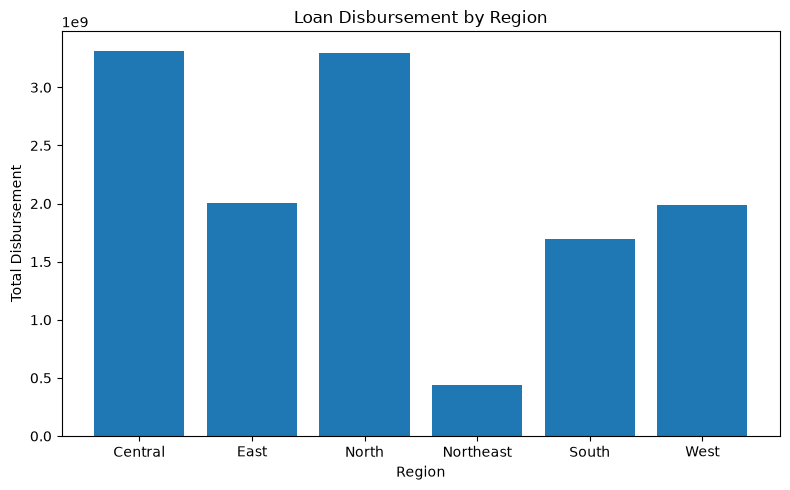

In [533]:
plt.figure(figsize=(8,5))

plt.bar(
    region_disbursement["Region"],
    region_disbursement["Total_Disbursement"]
)

plt.title("Loan Disbursement by Region")
plt.xlabel("Region")
plt.ylabel("Total Disbursement")

plt.tight_layout()

plt.savefig(
    "plots/disbursement_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The North region has the highest delinquency rate at 12.57%, while the West has the lowest at 6.43%. Central and North also have relatively high total loan disbursements, indicating that these regions should receive closer monitoring for credit and delinquency risk.

In [534]:
loans.columns.tolist()

['Loan_ID',
 'Customer_ID',
 'Loan_Amount',
 'Interest_Rate',
 'Loan_Term',
 'Disbursal_Date',
 'Repayment_Start_Date',
 'Repayment_End_Date',
 'Loan_Status',
 'Overdue_Amount',
 'EMI_Amount',
 'Collateral_Details',
 'Default_Flag']

In [535]:
transactions.columns.tolist()

['Transaction_ID',
 'Loan_ID',
 'Customer_ID',
 'Transaction_Date',
 'Payment_Type',
 'Amount',
 'Overdue_Fee',
 'Remaining_Balance',
 'Mode_of_Payment',
 'Overdue_Status']

In [536]:
profit_summary = transactions.groupby("Payment_Type")["Amount"].agg(
    Total_Amount="sum",
    Average_Amount="mean",
    Transaction_Count="count"
).reset_index()

profit_summary

,Payment_Type,Total_Amount,Average_Amount,Transaction_Count
0,EMI,6302557017,25500.319705,247156
1,Penalty,6318173036,25492.539807,247844


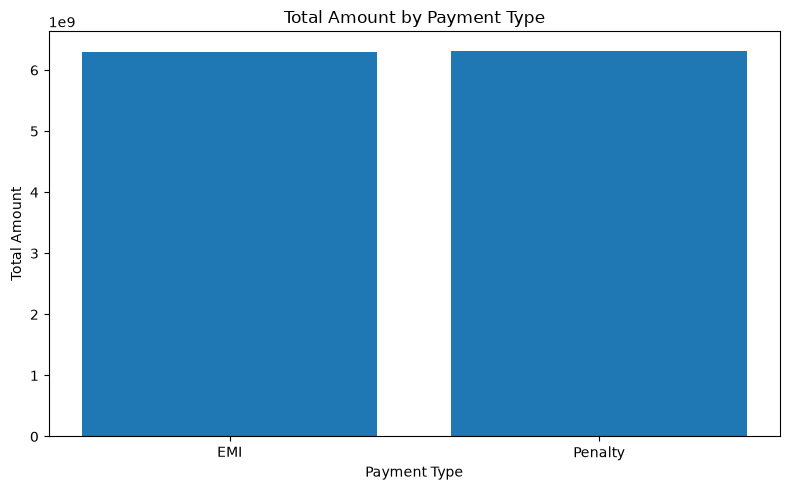

In [537]:
plt.figure(figsize=(8,5))

plt.bar(
    profit_summary["Payment_Type"],
    profit_summary["Total_Amount"]
)

plt.title("Total Amount by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Total Amount")

plt.tight_layout()

plt.savefig(
    "plots/payment_type_profitability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Penalty transactions generated a slightly higher total amount than EMI transactions, but the difference is very small. This suggests that both payment categories contribute substantially to the transaction value.

In [538]:
loans["Interest_Income"] = (
    loans["Loan_Amount"]
    * loans["Interest_Rate"] / 100
    * loans["Loan_Term"] / 12
)

total_interest = loans["Interest_Income"].sum()

total_interest

np.float64(75037526934.92252)

In [539]:
loans["Interest_Income"].describe()

count    9.000000e+04
mean     8.337503e+05
std      6.912060e+05
min      4.048436e+03
25%      2.946043e+05
50%      6.343936e+05
75%      1.211664e+06
max      3.725603e+06
Name: Interest_Income, dtype: float64

In [540]:
profit_purpose = applications[
    ["Loan_ID", "Loan_Purpose"]
].merge(
    loans[["Loan_ID", "Interest_Income"]],
    on="Loan_ID",
    how="inner"
)

In [541]:
purpose_profit = (
    profit_purpose
    .groupby("Loan_Purpose")
    .agg(
        Total_Interest=("Interest_Income", "sum"),
        Average_Interest=("Interest_Income", "mean"),
        Loan_Count=("Loan_ID", "count")
    )
    .reset_index()
    .sort_values("Total_Interest", ascending=False)
)

purpose_profit

,Loan_Purpose,Total_Interest,Average_Interest,Loan_Count
4,Vehicle,1.184490e+10,840123.431030,14099
0,Business,1.174041e+10,838900.405240,13995
1,Education,1.166138e+10,834744.527799,13970
2,Home Renovation,1.162827e+10,830946.565098,13994
3,Personal,1.146694e+10,822474.777077,13942


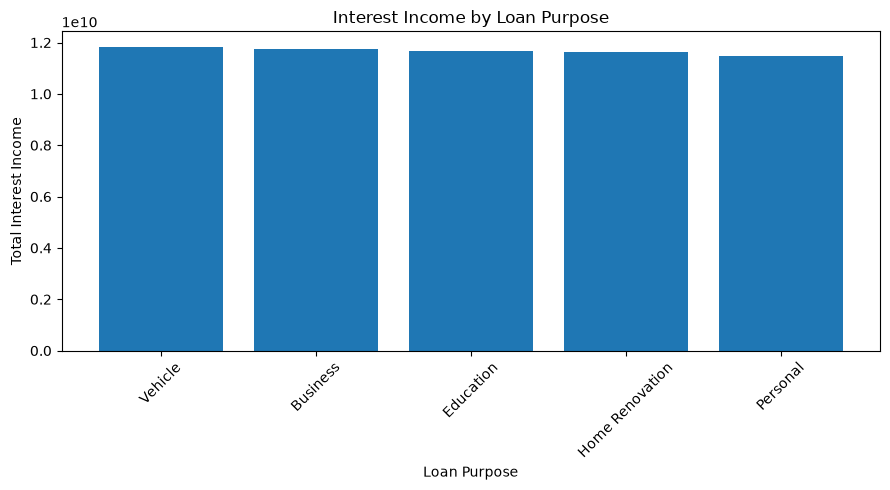

In [542]:
plt.figure(figsize=(9,5))

plt.bar(
    purpose_profit["Loan_Purpose"],
    purpose_profit["Total_Interest"]
)

plt.title("Interest Income by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Total Interest Income")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "plots/interest_by_loan_purpose.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [543]:
loans.columns.tolist()

['Loan_ID',
 'Customer_ID',
 'Loan_Amount',
 'Interest_Rate',
 'Loan_Term',
 'Disbursal_Date',
 'Repayment_Start_Date',
 'Repayment_End_Date',
 'Loan_Status',
 'Overdue_Amount',
 'EMI_Amount',
 'Collateral_Details',
 'Default_Flag',
 'Interest_Income']

In [545]:
customers.columns.tolist()

['Customer_ID',
 'Full_Name',
 'Contact_Number',
 'Email',
 'Address',
 'Age',
 'Gender',
 'Marital_Status',
 'Employment_Status',
 'Annual_Income',
 'Credit_Score',
 'Region',
 'Account_Tenure',
 'Relationship_Manager_ID']

In [546]:
branch_profitability = branch_analysis[
    [
        "Branch_ID",
        "Branch_Name",
        "Region",
        "Loan_Disbursement_Amount",
        "Delinquent_Loans",
        "Delinquency_Rate",
        "Avg_Processing_Time"
    ]
].copy()

branch_profitability.sort_values(
    "Loan_Disbursement_Amount",
    ascending=False
).head(10)

,Branch_ID,Branch_Name,Region,Loan_Disbursement_Amount,Delinquent_Loans,Delinquency_Rate,Avg_Processing_Time
35,B036,Kara-Bahl,East,499562869,106,11.169652,11
13,B014,"Bhatti, Rau and Sem",North,482327541,67,15.261959,7
11,B012,Kaul Inc,West,465469874,104,6.067678,3
47,B048,Chawla-Subramanian,Central,464419943,87,5.434104,4
34,B035,"Malhotra, Boase and Malhotra",Central,449109596,165,26.699029,13
42,B043,Grover Group,East,447832443,176,20.183486,12
2,B003,Sachdev-Banerjee,Central,445787808,168,137.704918,12
49,B050,Sani-Kale,North,442594434,91,28.173375,1
9,B010,Arya Ltd,West,435407779,49,2.707182,10
36,B037,Yogi Ltd,North,420746720,183,11.545741,13


In [547]:
region_profitability = (
    branch_profitability
    .groupby("Region")
    .agg(
        Total_Disbursement=("Loan_Disbursement_Amount", "sum"),
        Total_Delinquent_Loans=("Delinquent_Loans", "sum"),
        Average_Delinquency_Rate=("Delinquency_Rate", "mean")
    )
    .reset_index()
)

region_profitability

,Region,Total_Disbursement,Total_Delinquent_Loans,Average_Delinquency_Rate
0,Central,3316048302,994,28.509656
1,East,2006676282,756,9.876306
2,North,3296073904,1504,19.233029
3,Northeast,442827845,487,21.895367
4,South,1694906506,846,10.317048
5,West,1990828641,441,9.516034


In [548]:
purpose_profit

,Loan_Purpose,Total_Interest,Average_Interest,Loan_Count
4,Vehicle,1.184490e+10,840123.431030,14099
0,Business,1.174041e+10,838900.405240,13995
1,Education,1.166138e+10,834744.527799,13970
2,Home Renovation,1.162827e+10,830946.565098,13994
3,Personal,1.146694e+10,822474.777077,13942


Vehicle loans generated the highest total interest income of approximately ₹11.85 billion, making them the most profitable loan purpose based on interest earnings. Personal loans generated the lowest interest income at approximately ₹11.47 billion. The difference is relatively small, indicating that interest earnings are fairly evenly distributed across loan purposes.

In [549]:
region_profitability = (
    branch_analysis
    .groupby("Region")
    .agg(
        Total_Disbursement=("Loan_Disbursement_Amount", "sum"),
        Total_Delinquent_Loans=("Delinquent_Loans", "sum"),
        Average_Delinquency_Rate=("Delinquency_Rate", "mean")
    )
    .reset_index()
)

region_profitability

,Region,Total_Disbursement,Total_Delinquent_Loans,Average_Delinquency_Rate
0,Central,3316048302,994,28.509656
1,East,2006676282,756,9.876306
2,North,3296073904,1504,19.233029
3,Northeast,442827845,487,21.895367
4,South,1694906506,846,10.317048
5,West,1990828641,441,9.516034


Branch profitability varies across regions. Central had the highest total loan disbursement at approximately ₹3.32 billion, closely followed by North at ₹3.30 billion. However, Central also had the highest average delinquency rate of 28.51%, indicating higher credit risk. West had a comparatively lower disbursement of ₹1.99 billion but the lowest average delinquency rate of 9.52%. Therefore, higher lending activity does not necessarily correspond to better overall branch performance, and profitability should be considered alongside credit risk.

In [550]:
active_region = (
    branches.groupby("Region")["Total_Active_Loans"]
    .sum()
    .reset_index()
)

active_region

,Region,Total_Active_Loans
0,Central,8715
1,East,8929
2,North,11965
3,Northeast,5174
4,South,9235
5,West,6861


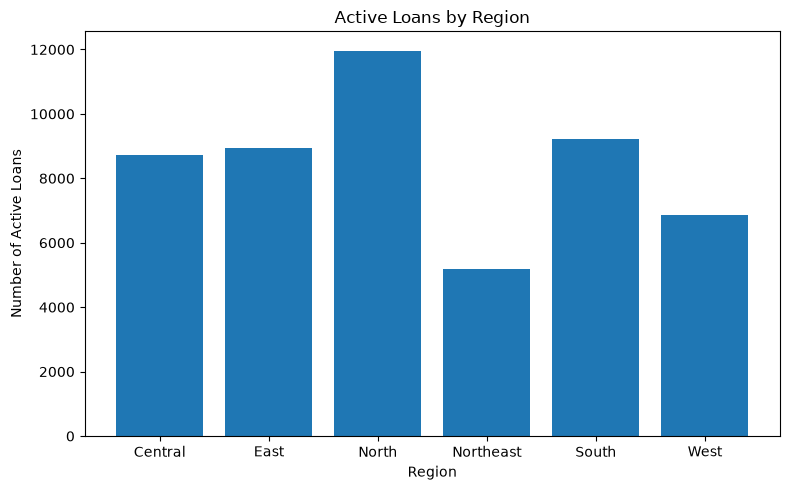

In [551]:
plt.figure(figsize=(8,5))

plt.bar(
    active_region["Region"],
    active_region["Total_Active_Loans"]
)

plt.title("Active Loans by Region")
plt.xlabel("Region")
plt.ylabel("Number of Active Loans")

plt.tight_layout()

plt.savefig(
    "plots/active_loans_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [552]:
region_analysis.columns.tolist()

['Region',
 'Branch_Count',
 'Total_Active_Loans',
 'Total_Delinquent_Loans',
 'Total_Disbursement',
 'Average_Processing_Time',
 'Average_Delinquency_Rate',
 'Calculated_Delinquency_Rate']

In [553]:
customers.columns.tolist()

['Customer_ID',
 'Full_Name',
 'Contact_Number',
 'Email',
 'Address',
 'Age',
 'Gender',
 'Marital_Status',
 'Employment_Status',
 'Annual_Income',
 'Credit_Score',
 'Region',
 'Account_Tenure',
 'Relationship_Manager_ID']

In [555]:
region_default = region_analysis[
    ["Region", "Total_Active_Loans",
     "Total_Delinquent_Loans", "Calculated_Delinquency_Rate"]
].copy()

region_default

,Region,Total_Active_Loans,Total_Delinquent_Loans,Calculated_Delinquency_Rate
0,Central,8715,994,11.405622
1,East,8929,756,8.466794
2,North,11965,1504,12.569996
3,Northeast,5174,487,9.412447
4,South,9235,846,9.160801
5,West,6861,441,6.427634


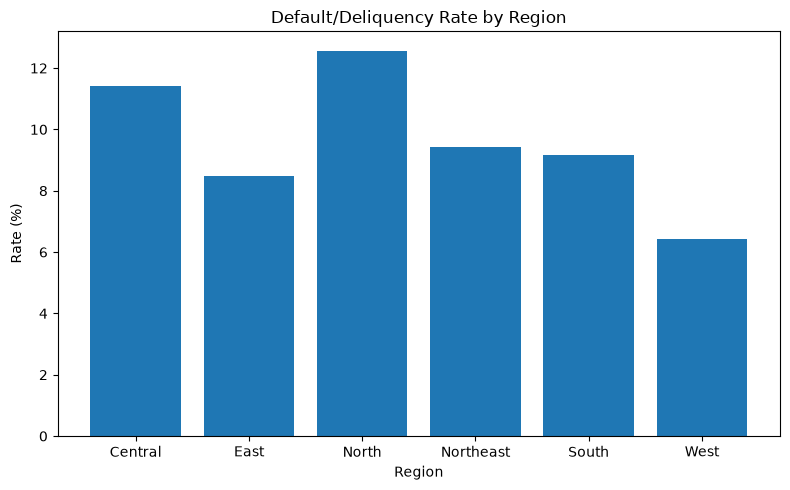

In [556]:
plt.figure(figsize=(8,5))

plt.bar(
    region_default["Region"],
    region_default["Calculated_Delinquency_Rate"]
)

plt.title("Default/Deliquency Rate by Region")
plt.xlabel("Region")
plt.ylabel("Rate (%)")

plt.tight_layout()

plt.savefig(
    "plots/default_rate_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [557]:
[c for c in master.columns if "urban" in c.lower() or "rural" in c.lower() or "location" in c.lower()]

[]

Rural vs Urban Analysis: The available dataset does not contain a Rural/Urban or Location_Type variable. Therefore, a reliable comparison of loan disbursement between rural and urban areas could not be performed without introducing assumptions or external geographic data.

In [558]:
defaults["Default_Date"] = pd.to_datetime(defaults["Default_Date"])

monthly_defaults = (
    defaults.groupby(defaults["Default_Date"].dt.to_period("M"))
    .size()
    .reset_index(name="Default_Count")
)

monthly_defaults["Default_Date"] = monthly_defaults["Default_Date"].astype(str)

monthly_defaults.head()

,Default_Date,Default_Count
0,2021-01,164
1,2021-02,171
2,2021-03,189
3,2021-04,196
4,2021-05,195


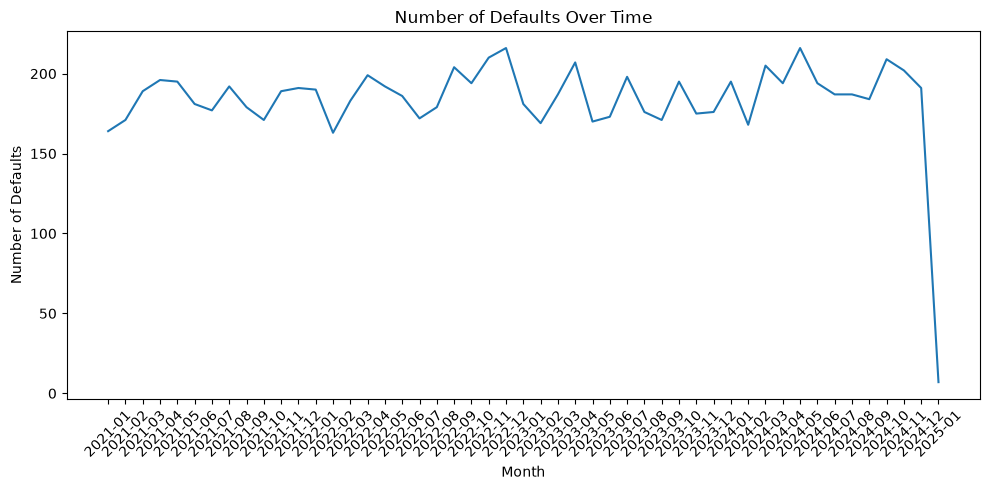

In [559]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_defaults["Default_Date"],
    monthly_defaults["Default_Count"]
)

plt.title("Number of Defaults Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Defaults")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "plots/defaults_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [560]:
default_purpose = defaults[
    ["Loan_ID", "Default_Amount"]
].merge(
    applications[["Loan_ID", "Loan_Purpose"]],
    on="Loan_ID",
    how="left"
)

purpose_default_amount = (
    default_purpose.groupby("Loan_Purpose")["Default_Amount"]
    .agg(["count", "mean"])
    .reset_index()
    .rename(columns={
        "count": "Default_Count",
        "mean": "Average_Default_Amount"
    })
)

purpose_default_amount

,Loan_Purpose,Default_Count,Average_Default_Amount
0,Business,1368,53261.031433
1,Education,1397,53797.758769
2,Home Renovation,1412,53038.080028
3,Personal,1416,52389.399011
4,Vehicle,1421,52671.599578


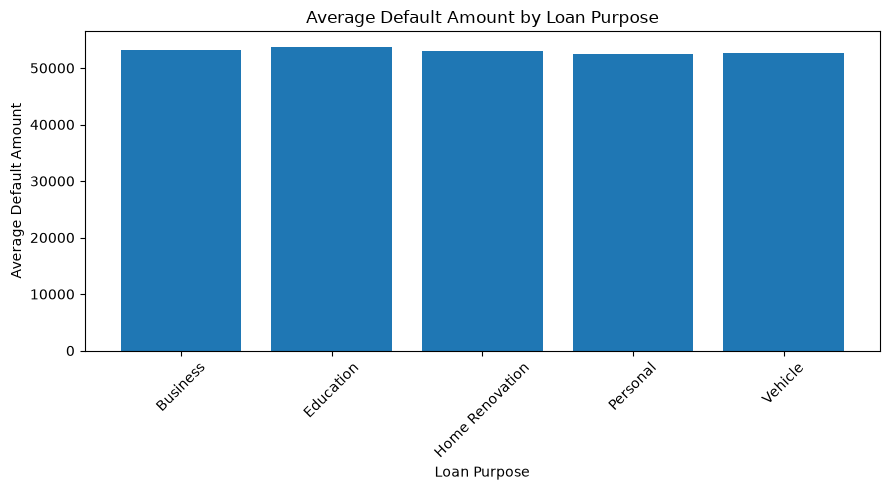

In [561]:
plt.figure(figsize=(9,5))

plt.bar(
    purpose_default_amount["Loan_Purpose"],
    purpose_default_amount["Average_Default_Amount"]
)

plt.title("Average Default Amount by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Average Default Amount")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "plots/average_default_by_purpose.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [562]:
customers["Income_Category"] = pd.qcut(
    customers["Annual_Income"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

In [563]:
income_defaults = defaults[
    ["Customer_ID", "Loan_ID"]
].merge(
    customers[["Customer_ID", "Income_Category"]],
    on="Customer_ID",
    how="left"
)

In [564]:
income_default_summary = (
    income_defaults.groupby("Income_Category")
    .size()
    .reset_index(name="Default_Count")
)

income_default_summary

,Income_Category,Default_Count
0,Low,1717
1,Medium,1760
2,High,1742
3,Very High,1795


In [565]:
income_total = (
    customers.groupby("Income_Category")
    .size()
    .reset_index(name="Total_Customers")
)

income_default_summary = income_default_summary.merge(
    income_total,
    on="Income_Category"
)

income_default_summary["Default_Rate"] = (
    income_default_summary["Default_Count"]
    / income_default_summary["Total_Customers"]
    * 100
)

income_default_summary

,Income_Category,Default_Count,Total_Customers,Default_Rate
0,Low,1717,17500,9.811429
1,Medium,1760,17500,10.057143
2,High,1742,17500,9.954286
3,Very High,1795,17500,10.257143


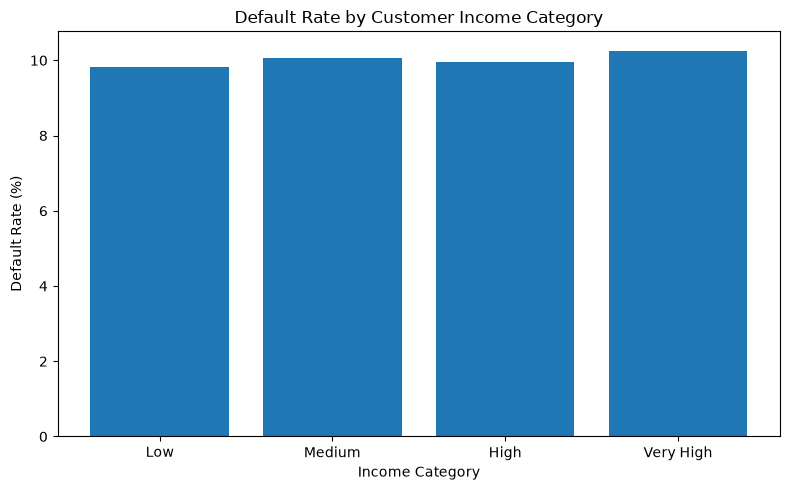

In [566]:
plt.figure(figsize=(8,5))

plt.bar(
    income_default_summary["Income_Category"],
    income_default_summary["Default_Rate"]
)

plt.title("Default Rate by Customer Income Category")
plt.xlabel("Income Category")
plt.ylabel("Default Rate (%)")

plt.tight_layout()

plt.savefig(
    "plots/default_rate_by_income.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [567]:
income_default_rate = (
    income_defaults.groupby("Income_Category")
    .size()
    .reset_index(name="Default_Count")
    .merge(
        customers.groupby("Income_Category")
        .size()
        .reset_index(name="Total_Customers"),
        on="Income_Category"
    )
)

income_default_rate["Default_Rate"] = (
    income_default_rate["Default_Count"]
    / income_default_rate["Total_Customers"] * 100
)

income_default_rate

,Income_Category,Default_Count,Total_Customers,Default_Rate
0,Low,1717,17500,9.811429
1,Medium,1760,17500,10.057143
2,High,1742,17500,9.954286
3,Very High,1795,17500,10.257143


Default rates were relatively similar across all income categories, ranging from 9.81% to 10.26%. The Very High income category had the highest default rate at 10.26%, while the Low income category had the lowest at 9.81%. This suggests that income level alone does not have a strong differentiating effect on default rates in this dataset.

In [568]:
branch_time = branches[
    ["Branch_ID", "Branch_Name", "Region", "Avg_Processing_Time"]
].sort_values(
    "Avg_Processing_Time",
    ascending=False
)

branch_time

,Branch_ID,Branch_Name,Region,Avg_Processing_Time
10,B011,Bhakta PLC,South,15
5,B006,Doshi Group,North,15
30,B031,Sem Inc,South,15
21,B022,"Bansal, Arya and Chakrabarti",East,15
14,B015,Apte Group,North,14
25,B026,Madan-Lanka,North,14
18,B019,Bath-Bassi,North,14
8,B009,Vasa Group,North,13
34,B035,"Malhotra, Boase and Malhotra",Central,13
19,B020,Contractor-Sodhi,West,13


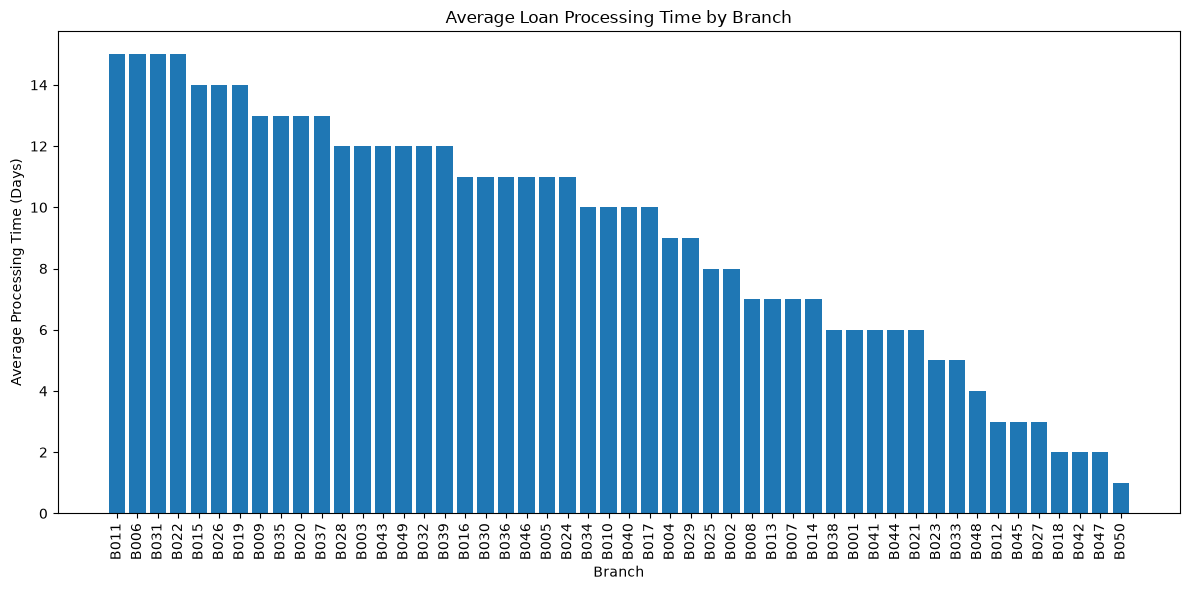

In [569]:
plt.figure(figsize=(12,6))

plt.bar(
    branch_time["Branch_ID"],
    branch_time["Avg_Processing_Time"]
)

plt.title("Average Loan Processing Time by Branch")
plt.xlabel("Branch")
plt.ylabel("Average Processing Time (Days)")

plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(
    "plots/branch_processing_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [570]:
rejected_applications.columns.tolist()

['Application_ID',
 'Loan_ID',
 'Customer_ID',
 'Application_Date',
 'Approval_Date',
 'Loan_Purpose',
 'Source_Channel',
 'Processing_Fee',
 'Approval_Status',
 'Rejection_Reason',
 'Valid_Approval_Date',
 'Approval_Date_Status',
 'Date_Valid']

In [571]:
approval_summary

,Application_Status,Application_Count,Percentage
0,Approved,70000,84.745763
1,Rejected,12600,15.254237


In [572]:
rejection_summary

,Rejection_Reason,Count,Percentage
0,Low Credit Score,4297,34.103175
1,Incomplete Documents,4204,33.365079
2,Insufficient Income,4099,32.531746


In [573]:
[c for c in master.columns
 if "satisfaction" in c.lower() or "rating" in c.lower()]

[]

Customer satisfaction metrics were not available in the provided datasets, so branch efficiency could not be compared using customer satisfaction scores.

In [574]:
[c for c in master.columns
 if "satisfaction" in c.lower() or "rating" in c.lower()]

[]

Customer satisfaction metrics were not available in the provided dataset. Therefore, branch efficiency could not be compared using customer satisfaction scores. Average processing time was used as the available branch efficiency indicator.

In [575]:
loans["Disbursal_Date"] = pd.to_datetime(loans["Disbursal_Date"])

monthly_disbursement = (
    loans.groupby(loans["Disbursal_Date"].dt.to_period("M"))
    ["Loan_Amount"]
    .sum()
    .reset_index(name="Total_Disbursement")
)

monthly_disbursement["Disbursal_Date"] = (
    monthly_disbursement["Disbursal_Date"].astype(str)
)

monthly_disbursement.tail(60)

,Disbursal_Date,Total_Disbursement
1,2020-01,3908302834
2,2020-02,3621088694
3,2020-03,4031554268
4,2020-04,3817013578
5,2020-05,3870491103
6,2020-06,3724997124
7,2020-07,3766777788
8,2020-08,3821911676
9,2020-09,3609549239
10,2020-10,3786398487


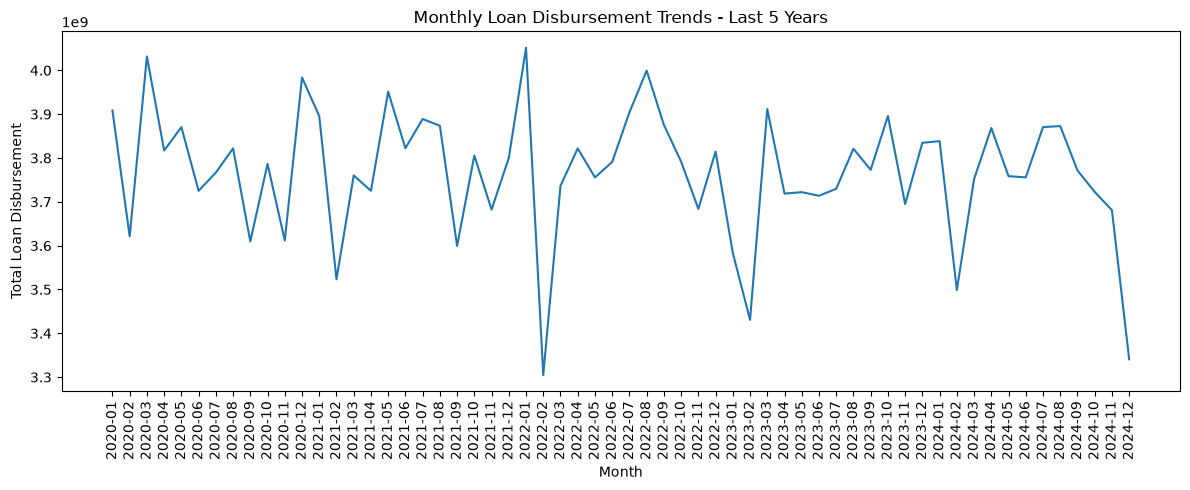

In [576]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_disbursement["Disbursal_Date"].tail(60),
    monthly_disbursement["Total_Disbursement"].tail(60)
)

plt.title("Monthly Loan Disbursement Trends - Last 5 Years")
plt.xlabel("Month")
plt.ylabel("Total Loan Disbursement")

plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(
    "plots/monthly_disbursement_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [577]:
loans["Month"] = pd.to_datetime(loans["Disbursal_Date"]).dt.month

monthly_pattern = (
    loans.groupby("Month")["Loan_Amount"]
    .mean()
    .reset_index(name="Average_Disbursement")
)

monthly_pattern

,Month,Average_Disbursement
0,1,2.511068e+06
1,2,2.500845e+06
2,3,2.521551e+06
3,4,2.533243e+06
4,5,2.510936e+06
5,6,2.556805e+06
6,7,2.520066e+06
7,8,2.510831e+06
8,9,2.509312e+06
9,10,2.488172e+06


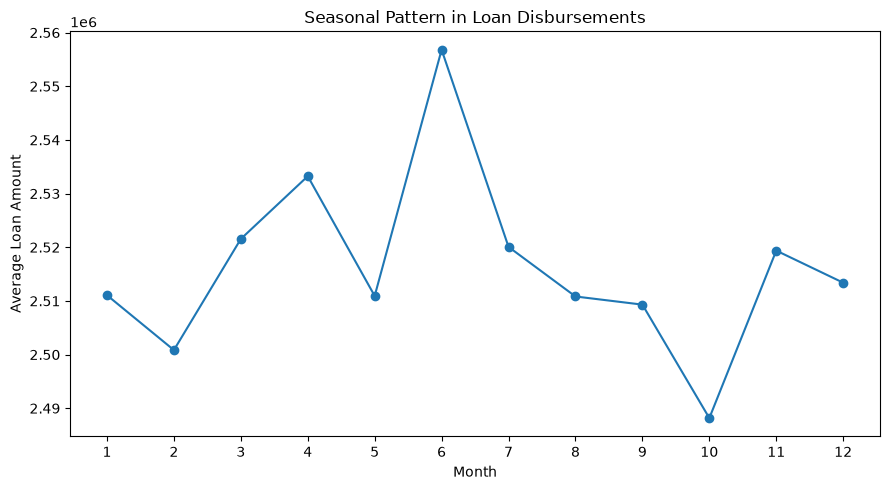

In [578]:
plt.figure(figsize=(9,5))

plt.plot(
    monthly_pattern["Month"],
    monthly_pattern["Average_Disbursement"],
    marker="o"
)

plt.title("Seasonal Pattern in Loan Disbursements")
plt.xlabel("Month")
plt.ylabel("Average Loan Amount")
plt.xticks(range(1,13))

plt.tight_layout()

plt.savefig(
    "plots/seasonal_disbursement_pattern.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [579]:
applications["Month"] = pd.to_datetime(
    applications["Application_Date"]
).dt.month

application_seasonality = (
    applications.groupby("Month")
    .size()
    .reset_index(name="Application_Count")
)

application_seasonality

,Month,Application_Count
0,1,7124
1,2,6397
2,3,6863
3,4,6781
4,5,6998
5,6,6808
6,7,7215
7,8,6952
8,9,6762
9,10,6952


In [580]:
defaults["Default_Date"] = pd.to_datetime(defaults["Default_Date"])
defaults["Month"] = defaults["Default_Date"].dt.to_period("M")

In [581]:
default_region = defaults[
    ["Customer_ID", "Default_Date", "Month"]
].merge(
    customers[["Customer_ID", "Region"]],
    on="Customer_ID",
    how="left"
)

In [582]:
monthly_region_defaults = (
    default_region
    .groupby(["Month", "Region"])
    .size()
    .reset_index(name="Default_Count")
)

monthly_region_defaults.head()

,Month,Region,Default_Count
0,2021-01,Central,28
1,2021-01,East,25
2,2021-01,North,33
3,2021-01,Northeast,18
4,2021-01,South,14


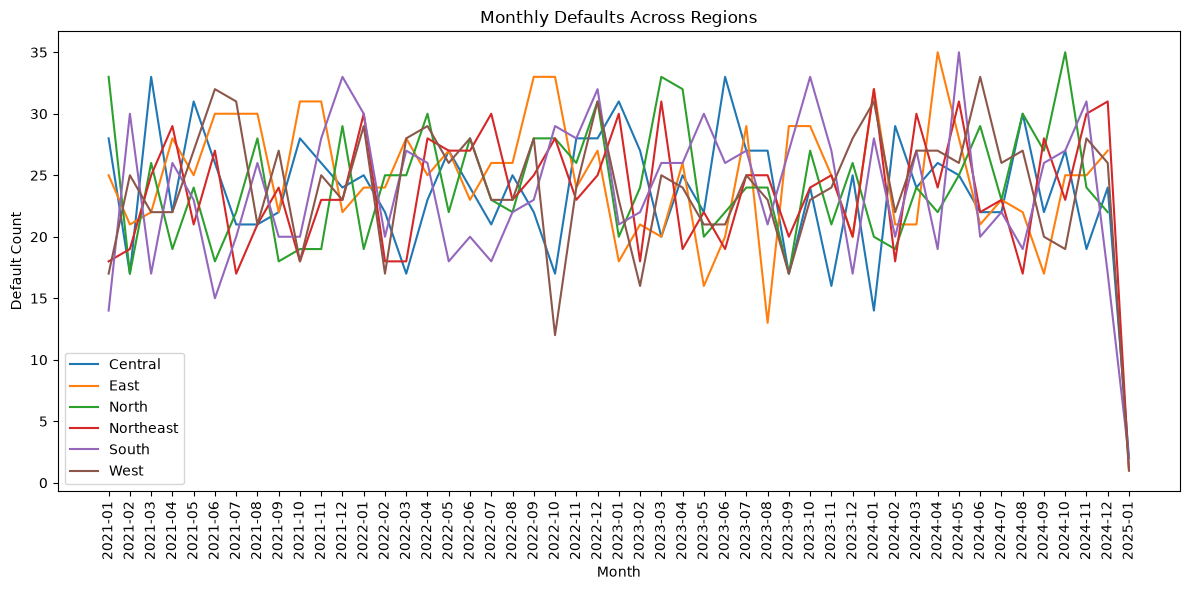

In [583]:
plt.figure(figsize=(12,6))

for region in monthly_region_defaults["Region"].unique():
    data = monthly_region_defaults[
        monthly_region_defaults["Region"] == region
    ]

    plt.plot(
        data["Month"].astype(str),
        data["Default_Count"],
        label=region
    )

plt.title("Monthly Defaults Across Regions")
plt.xlabel("Month")
plt.ylabel("Default Count")

plt.xticks(rotation=90)
plt.legend()

plt.tight_layout()

plt.savefig(
    "plots/monthly_defaults_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The monthly number of defaults varies considerably across all six regions throughout the period. Most regions record approximately 15–35 defaults per month, with occasional peaks and declines. No region shows a consistently increasing or decreasing trend. The regions generally follow similar fluctuating patterns, suggesting that defaults vary month-to-month rather than being dominated by a single geographic region.

In [584]:
customer_behavior = (
    loans_customer.groupby("Customer_ID")
    .agg(
        Total_Loans=("Loan_ID", "count"),
        Default_Count=("Default_Flag", "sum")
    )
    .reset_index()
)

In [586]:
customer_behavior["Repayment_Behavior"] = np.select(
    [
        customer_behavior["Default_Count"] == 0,
        customer_behavior["Default_Count"] == 1,
        customer_behavior["Default_Count"] >= 2
    ],
    [
        "Always On Time",
        "Occasional Defaulter",
        "Frequent Defaulter"
    ],
    default="Unknown"
)

In [587]:
customer_behavior["Repayment_Behavior"].value_counts()

Repayment_Behavior
Always On Time          42655
Occasional Defaulter     7527
Frequent Defaulter        494
Name: count, dtype: int64

In [589]:
default="Unknown"

Most customers (42,655) were classified as Always On Time, indicating generally positive repayment behavior. A smaller group of 7,527 customers were occasional defaulters, while only 494 customers were classified as frequent defaulters. Overall, the majority of customers demonstrated consistent repayment behavior.

In [590]:
application_customer = applications[
    ["Customer_ID", "Approval_Status", "Rejection_Reason"]
].merge(
    customers[["Customer_ID", "Gender"]],
    on="Customer_ID",
    how="left"
)

In [591]:
gender_approval = pd.crosstab(
    application_customer["Gender"],
    application_customer["Approval_Status"]
)

gender_approval

Approval_Status,Approved,Rejected
Gender,,
Female,23171,4180
Male,23448,4201
Other,23381,4219


In [592]:
gender_rejection = pd.crosstab(
    application_customer["Gender"],
    application_customer["Rejection_Reason"]
)

gender_rejection

Rejection_Reason,Incomplete Documents,Insufficient Income,Low Credit Score
Gender,,,
Female,1421,1336,1423
Male,1404,1371,1426
Other,1379,1392,1448


Approval and rejection patterns were broadly similar across gender categories. The number of approved applications was relatively consistent for Female, Male, and Other customers. Among rejected applications, Low Credit Score was generally the most common rejection reason, while Insufficient Income and Incomplete Documents occurred at similar levels. Overall, the results do not show a major difference in approval or rejection patterns across the demographic groups.

In [593]:
high_value = (
    loans_customer.groupby("Customer_ID")
    .agg(
        Total_Loan_Amount=("Loan_Amount", "sum"),
        Total_Loans=("Loan_ID", "count"),
        Default_Count=("Default_Flag", "sum")
    )
    .reset_index()
)

high_value = high_value[
    high_value["Default_Count"] == 0
].sort_values(
    "Total_Loan_Amount",
    ascending=False
)

high_value.head(10)

,Customer_ID,Total_Loan_Amount,Total_Loans,Default_Count
19731,C027424,23741956,7,0
45404,C062756,23217624,6,0
45187,C062450,23069944,7,0
46794,C064678,22339111,5,0
50262,C069436,22251917,7,0
36431,C050357,21342157,7,0
7132,C009876,21195825,6,0
19369,C026918,20946920,6,0
6928,C009606,20825512,5,0
46207,C063879,20803706,6,0


In [594]:
high_value_top = high_value.head(10).merge(
    customers[
        ["Customer_ID", "Full_Name", "Annual_Income", "Credit_Score"]
    ],
    on="Customer_ID",
    how="left"
)

high_value_top

,Customer_ID,Total_Loan_Amount,Total_Loans,Default_Count,Full_Name,Annual_Income,Credit_Score
0,C027424,23741956,7,0,Tushar Dani,1112036,499
1,C062756,23217624,6,0,Zeeshan Upadhyay,761815,492
2,C062450,23069944,7,0,Aayush Sen,744112,673
3,C064678,22339111,5,0,Lakshay Konda,1942013,814
4,C069436,22251917,7,0,Navya Aggarwal,1503813,377
5,C050357,21342157,7,0,Dhanush Borra,499041,318
6,C009876,21195825,6,0,Riaan Deshmukh,1273486,495
7,C026918,20946920,6,0,Anvi Bhat,1050075,688
8,C009606,20825512,5,0,Indranil Maharaj,1858064,688
9,C063879,20803706,6,0,Vidur Sha,1024701,490


High-value customers were identified based on cumulative loan amount and consistent repayment history. The top customers had multiple loans, ranging from 5 to 7 loans, while recording zero defaults. The highest-value customer had a cumulative loan amount of approximately ₹23.74 million across seven loans with no defaults. These customers represent valuable and reliable borrowers who may be suitable for targeted retention and future lending opportunities.

In [595]:
risk_data = loans_customer[
    ["Loan_ID", "Loan_Amount", "Loan_Term", "Interest_Rate"]
].merge(
    defaults[["Loan_ID", "Default_Amount"]],
    on="Loan_ID",
    how="inner"
)

risk_data.head()

,Loan_ID,Loan_Amount,Loan_Term,Interest_Rate,Default_Amount
0,L000009,3104013,12,11.59,48655
1,L000019,678843,36,9.34,47609
2,L000025,4331567,12,10.14,23052
3,L000039,4291400,12,12.28,33041
4,L000050,626523,60,11.93,28774


In [596]:
risk_data["Default_Risk"] = pd.qcut(
    risk_data["Default_Amount"],
    q=3,
    labels=["Low", "Medium", "High"]
)

risk_data["Term_Risk"] = pd.qcut(
    risk_data["Loan_Term"],
    q=3,
    labels=["Low", "Medium", "High"]
)

risk_data["Interest_Risk"] = pd.qcut(
    risk_data["Interest_Rate"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [597]:
risk_data["Risk_Score"] = (
    risk_data["Default_Risk"].map(
        {"Low": 1, "Medium": 2, "High": 3}
    ).astype(int)
    +
    risk_data["Term_Risk"].map(
        {"Low": 1, "Medium": 2, "High": 3}
    ).astype(int)
    +
    risk_data["Interest_Risk"].map(
        {"Low": 1, "Medium": 2, "High": 3}
    ).astype(int)
)

In [598]:
risk_data["Overall_Risk"] = pd.cut(
    risk_data["Risk_Score"],
    bins=[0, 4, 7, 9],
    labels=["Low", "Medium", "High"]
)

risk_data["Overall_Risk"].value_counts()

Overall_Risk
Medium    6351
Low       1625
High      1024
Name: count, dtype: int64

Most defaulted loans (6,351, or approximately 70.6%) were classified as Medium Risk. A further 1,024 loans (11.4%) were classified as High Risk, while 1,625 loans (18.1%) were classified as Low Risk. Therefore, the majority of the loans fall into the Medium Risk category, indicating that moderate risk is the dominant risk profile in the dataset.

In [599]:
risk_purpose = risk_data.merge(
    applications[["Loan_ID", "Loan_Purpose"]],
    on="Loan_ID",
    how="left"
)

In [600]:
loan_type_risk = (
    risk_purpose.groupby("Loan_Purpose", observed=True)
    .agg(
        Average_Default_Amount=("Default_Amount", "mean"),
        Average_Loan_Term=("Loan_Term", "mean"),
        Average_Interest_Rate=("Interest_Rate", "mean"),
        High_Risk_Loans=("Overall_Risk", lambda x: (x == "High").sum())
    )
    .reset_index()
    .sort_values("High_Risk_Loans", ascending=False)
)

loan_type_risk

,Loan_Purpose,Average_Default_Amount,Average_Loan_Term,Average_Interest_Rate,High_Risk_Loans
4,Vehicle,52671.599578,36.895144,10.993462,165
1,Education,53797.758769,36.910523,10.971152,160
0,Business,53261.031433,36.631579,11.042113,159
2,Home Renovation,53038.080028,35.558074,10.929525,150
3,Personal,52389.399011,35.923729,10.879117,140


Vehicle loans had the highest number of high-risk loans (165), followed by Education (160) and Business (159). Personal loans had the lowest number of high-risk loans (140). Although Education had the highest average default amount, Vehicle loans had the largest number of loans classified as high risk.

Simple mitigation strategies
| Risk                   | Suggested mitigation                   |
| ---------------------- | -------------------------------------- |
| High default amount    | Stronger credit assessment             |
| Long loan term         | Shorter repayment periods              |
| High interest rate     | Risk-based pricing                     |
| High-risk loan purpose | Lower exposure / stricter approval     |
| High-risk customer     | Additional documentation or collateral |


In [601]:
customers["Credit_Category"] = pd.cut(
    customers["Credit_Score"],
    bins=[0, 500, 650, 750, 900],
    labels=["Very Low", "Low", "Good", "High"]
)

In [602]:
customers["Income_Category"] = pd.qcut(
    customers["Annual_Income"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

In [603]:
customer_risk = defaults[
    ["Customer_ID", "Default_Amount"]
].merge(
    customers[
        ["Customer_ID", "Credit_Category", "Income_Category"]
    ],
    on="Customer_ID",
    how="left"
)

In [605]:
risk_segments = (
    customer_risk
    .groupby(
        ["Credit_Category", "Income_Category"],
        observed=True
    )
    .agg(
        Default_Count=("Customer_ID", "count"),
        Average_Default_Amount=("Default_Amount", "mean")
    )
    .reset_index()
    .sort_values("Default_Count", ascending=False)
)

risk_segments

,Credit_Category,Income_Category,Default_Count,Average_Default_Amount
1,Very Low,Medium,654,52553.550459
3,Very Low,Very High,648,53528.145062
2,Very Low,High,641,53879.726989
0,Very Low,Low,606,53802.491749
7,Low,Very High,505,53036.976238
4,Low,Low,487,53120.464066
6,Low,High,471,51996.418259
5,Low,Medium,468,53086.196581
9,Good,Medium,345,51848.040580
14,High,High,329,52369.629179


Customers with Very Low credit scores represented the highest-risk segment across all income categories. The largest number of defaults occurred among Very Low credit-score customers with Medium income, with 654 defaults. This was followed by Very Low credit-score customers with Very High income, with 648 defaults. The results indicate that credit score appears to be a stronger indicator of default risk than income level in this analysis. Therefore, customers with very low credit scores should be subject to enhanced credit assessment and closer repayment monitoring.

In [606]:
time_default = defaults[
    ["Loan_ID", "Default_Date"]
].merge(
    loans_customer[
        ["Loan_ID", "Disbursal_Date"]
    ],
    on="Loan_ID",
    how="inner"
)

In [607]:
time_default["Default_Date"] = pd.to_datetime(time_default["Default_Date"])
time_default["Disbursal_Date"] = pd.to_datetime(time_default["Disbursal_Date"])

In [608]:
time_default["Time_to_Default"] = (
    time_default["Default_Date"]
    - time_default["Disbursal_Date"]
).dt.days

In [609]:
time_default["Time_to_Default"].describe()

count    9000.000000
mean      206.674111
std       670.803927
min     -1426.000000
25%      -277.000000
50%       218.000000
75%       698.000000
max      1809.000000
Name: Time_to_Default, dtype: float64

In [610]:
average_time_to_default = time_default["Time_to_Default"].mean()

average_time_to_default

np.float64(206.6741111111111)

In [611]:
time_default = time_default.merge(
    applications[
        ["Loan_ID", "Loan_Purpose"]
    ],
    on="Loan_ID",
    how="left"
)

In [612]:
purpose_time_default = (
    time_default
    .groupby("Loan_Purpose")["Time_to_Default"]
    .mean()
    .reset_index(name="Average_Time_to_Default")
    .sort_values("Average_Time_to_Default")
)

purpose_time_default

,Loan_Purpose,Average_Time_to_Default
1,Education,185.538296
0,Business,196.201754
2,Home Renovation,197.039660
4,Vehicle,227.274455
3,Personal,230.888418


In [613]:
time_default_demo = time_default.merge(
    customers[
        ["Customer_ID", "Gender"]
    ],
    left_on="Loan_ID",
    right_on="Customer_ID",
    how="left"
)

In [614]:
time_default_demo = time_default.merge(
    loans_customer[
        ["Loan_ID", "Customer_ID"]
    ],
    on="Loan_ID",
    how="left"
).merge(
    customers[
        ["Customer_ID", "Gender"]
    ],
    on="Customer_ID",
    how="left"
)

In [615]:
gender_time_default = (
    time_default_demo
    .groupby("Gender")["Time_to_Default"]
    .mean()
    .reset_index(name="Average_Time_to_Default")
)

gender_time_default

,Gender,Average_Time_to_Default
0,Female,195.178419
1,Male,197.471414
2,Other,227.113531


In [616]:
time_default["Time_to_Default"].describe()

count    9000.000000
mean      206.674111
std       670.803927
min     -1426.000000
25%      -277.000000
50%       218.000000
75%       698.000000
max      1809.000000
Name: Time_to_Default, dtype: float64

In [617]:
time_default_valid = time_default[
    time_default["Time_to_Default"] >= 0
].copy()

In [618]:
time_default_valid["Time_to_Default"].describe()

count    5581.000000
mean      630.697008
std       425.077829
min         0.000000
25%       277.000000
50%       561.000000
75%       931.000000
max      1809.000000
Name: Time_to_Default, dtype: float64

In [619]:
average_time_to_default = time_default_valid["Time_to_Default"].mean()

average_time_to_default

np.float64(630.6970077047124)

In [622]:
applications.columns.tolist()

['Application_ID',
 'Loan_ID',
 'Customer_ID',
 'Application_Date',
 'Approval_Date',
 'Loan_Purpose',
 'Source_Channel',
 'Processing_Fee',
 'Approval_Status',
 'Rejection_Reason',
 'Valid_Approval_Date',
 'Approval_Date_Status',
 'Date_Valid',
 'Month']

In [626]:
purpose_data = time_default_valid.merge(
    applications[["Loan_ID", "Loan_Purpose"]],
    on="Loan_ID",
    how="left"
)

In [628]:
print("applications:", applications.columns.tolist())
print("loans:", loans.columns.tolist())
print("loans_customer:", loans_customer.columns.tolist())
print("emi_loan_purpose:", emi_loan_purpose.columns.tolist())

applications: ['Application_ID', 'Loan_ID', 'Customer_ID', 'Application_Date', 'Approval_Date', 'Loan_Purpose', 'Source_Channel', 'Processing_Fee', 'Approval_Status', 'Rejection_Reason', 'Valid_Approval_Date', 'Approval_Date_Status', 'Date_Valid', 'Month']
loans: ['Loan_ID', 'Customer_ID', 'Loan_Amount', 'Interest_Rate', 'Loan_Term', 'Disbursal_Date', 'Repayment_Start_Date', 'Repayment_End_Date', 'Loan_Status', 'Overdue_Amount', 'EMI_Amount', 'Collateral_Details', 'Default_Flag', 'Interest_Income', 'Month']
loans_customer: ['Loan_ID', 'Customer_ID', 'Loan_Amount', 'Interest_Rate', 'Loan_Term', 'Disbursal_Date', 'Repayment_Start_Date', 'Repayment_End_Date', 'Loan_Status', 'Overdue_Amount', 'EMI_Amount', 'Collateral_Details', 'Default_Flag', 'Credit_Score', 'EMI_Band']
emi_loan_purpose: ['Loan_ID', 'EMI_Amount', 'Default_Flag', 'Loan_Purpose']


In [629]:
purpose_data = time_default_valid[
    ["Loan_ID", "Time_to_Default"]
].merge(
    applications[
        ["Loan_ID", "Loan_Purpose"]
    ],
    on="Loan_ID",
    how="left"
)

In [630]:
purpose_time_default = (
    purpose_data
    .groupby("Loan_Purpose")["Time_to_Default"]
    .mean()
    .reset_index(name="Average_Time_to_Default")
    .sort_values("Average_Time_to_Default")
)

purpose_time_default

,Loan_Purpose,Average_Time_to_Default
3,Personal,612.226190
1,Education,617.936768
0,Business,626.122786
2,Home Renovation,631.974299
4,Vehicle,659.708145


In [631]:
time_default_demo = (
    time_default_valid[
        ["Loan_ID", "Time_to_Default"]
    ]
    .merge(
        loans_customer[["Loan_ID", "Customer_ID"]],
        on="Loan_ID",
        how="left"
    )
    .merge(
        customers[["Customer_ID", "Gender"]],
        on="Customer_ID",
        how="left"
    )
)

In [632]:
gender_time_default = (
    time_default_demo
    .groupby("Gender")["Time_to_Default"]
    .mean()
    .reset_index(name="Average_Time_to_Default")
    .sort_values("Average_Time_to_Default")
)

gender_time_default

,Gender,Average_Time_to_Default
0,Female,620.468733
1,Male,627.564400
2,Other,643.744871


Female customers had the shortest average time to default at approximately 620 days, followed by male customers at approximately 628 days. Customers in the Other category had the longest average time to default at approximately 644 days. The differences are relatively small, suggesting that gender does not show a large difference in the timing of defaults in this dataset.

In [633]:
irregular_customers = (
    transactions[transactions["Payment_Type"] == "Penalty"]
    .groupby("Customer_ID")
    .agg(
        Penalty_Count=("Transaction_ID", "count"),
        Total_Penalty_Amount=("Amount", "sum")
    )
    .reset_index()
    .sort_values("Penalty_Count", ascending=False)
)

irregular_customers.head(10)


,Customer_ID,Penalty_Count,Total_Penalty_Amount
20637,C029631,31,656885
3843,C005453,30,793743
32376,C046271,30,802952
15135,C021671,29,743554
48670,C069436,29,662733
1811,C002589,29,762301
35979,C051355,27,569431
8330,C011969,25,687660
21151,C030368,25,620040
46881,C066890,25,714951


In [634]:
transaction_summary = (
    transactions
    .groupby("Payment_Type")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Amount=("Amount", "sum")
    )
    .reset_index()
)

transaction_summary

,Payment_Type,Transaction_Count,Total_Amount
0,EMI,247156,6302557017
1,Penalty,247844,6318173036


In [635]:
penalty_proportion = (
    (transactions["Payment_Type"] == "Penalty").sum()
    / len(transactions)
) * 100

penalty_proportion

np.float64(50.06949494949495)

In [636]:
transactions["Overdue_Status"] = np.where(
    transactions["Overdue_Fee"] > 0,
    "Overdue",
    "Non-Overdue"
)

In [637]:
overdue_transaction_summary = (
    transactions
    .groupby("Overdue_Status")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Average_Transaction_Amount=("Amount", "mean"),
        Total_Transaction_Amount=("Amount", "sum")
    )
    .reset_index()
)

overdue_transaction_summary

,Overdue_Status,Transaction_Count,Average_Transaction_Amount,Total_Transaction_Amount
0,Non-Overdue,247549,25508.590853,6314626157
1,Overdue,247451,25484.253028,6306103896


In [638]:
penalty_proportion = (
    (transactions["Payment_Type"] == "Penalty").sum()
    / len(transactions)
) * 100

penalty_proportion

np.float64(50.06949494949495)

In [639]:
transaction_summary = (
    transactions.groupby("Payment_Type")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Amount=("Amount", "sum"),
        Average_Amount=("Amount", "mean")
    )
    .reset_index()
)

transaction_summary

,Payment_Type,Transaction_Count,Total_Amount,Average_Amount
0,EMI,247156,6302557017,25500.319705
1,Penalty,247844,6318173036,25492.539807


Penalty payments accounted for approximately 50.07% of all transactions, while EMI payments accounted for approximately 49.93%. The average transaction amounts were also very similar, at approximately ₹25,500 for EMI transactions and ₹25,493 for penalty transactions. This indicates that penalty transactions represent a substantial portion of the transaction activity.

In [640]:
transactions["Overdue_Status"] = np.where(
    transactions["Overdue_Fee"] > 0,
    "Overdue",
    "Non-Overdue"
)

In [641]:
overdue_transaction_summary = (
    transactions
    .groupby("Overdue_Status")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Average_Transaction_Amount=("Amount", "mean"),
        Total_Transaction_Amount=("Amount", "sum")
    )
    .reset_index()
)

overdue_transaction_summary

,Overdue_Status,Transaction_Count,Average_Transaction_Amount,Total_Transaction_Amount
0,Non-Overdue,247549,25508.590853,6314626157
1,Overdue,247451,25484.253028,6306103896


Transaction activity was almost evenly split between overdue and non-overdue loans. Non-overdue transactions had a slightly higher average transaction amount of ₹25,508.59 compared with ₹25,484.25 for overdue transactions. The difference is very small, suggesting that transaction amount alone does not strongly distinguish overdue from non-overdue transactions.

The transaction analysis shows that penalty payments constitute approximately half of all recorded transactions, indicating a substantial level of repayment-related activity. Several customers recorded unusually high numbers of penalty transactions, suggesting irregular repayment behavior. However, transaction amounts were very similar between overdue and non-overdue loans, indicating that transaction value alone is not a strong indicator of overdue status.